In [39]:
! pip install textblob
! pip install textblob-fr
! pip install vaderSentiment-fr

# Predict TOA

In [3]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from networkx.algorithms import bipartite as nx_bip
from collections import Counter
import math

## Load Raw Data Set

In [4]:
#df = pd.read_excel("/Users/evangeliazve/Downloads/data_x_hydrogen/X_hydrogen_compiled.xlsx")
#df = pd.read_excel("/Users/evangeliazve/Downloads/data_x_jo_2030/X_jo_2030_compiled.xlsx")
#df = pd.read_excel("/Users/evangeliazve/Downloads/data_x_climat/X_climat_combined_stacked_all.xlsx")
df = pd.read_excel("/Users/evangeliazve/Downloads/data_x_hydrogen/X_hydrogen_combined_stacked_all.xlsx")


#df = df.drop_duplicates()
#df = pd.concat([df_hyd], ignore_index=True)


# Optional: Check how many invalid dates were found
invalid_dates_count = df['publication_date_cleaned'].isna().sum()
print(f"❌ Found {invalid_dates_count} rows with invalid dates.")

# If you want to remove rows with invalid dates:
df = df.dropna(subset=['publication_date_cleaned'])


df = df[~(
        df["concat_text"].str.contains("Toutes nos excuses", na=False) |
        (df["concat_text"].str.len() < 80)
    )]

start_date = '2025-03-20'
end_date = '2025-06-08'
    
df = df[(df['publication_date_cleaned'] >= start_date) & (df['publication_date_cleaned'] <= end_date)]


df = df[
    df['concat_text'].str.contains("hydrogène", case=False, na=False)
]

df = df.drop(["Unnamed: 0.1", "Unnamed: 0"], axis=1)

# Now filter them out
df = df[df['media_url'].str.contains(r'^https?://[^/]+/.+', na=False)]


df = df.drop_duplicates()

❌ Found 26 rows with invalid dates.


## Assign Cases to News Articles

In [5]:
def assign_cases_cumulative(df, *, recent_cutoff_days=26):
    """
    Taxonomy-based classifier (trajectory-only), preserving outlierness:

      Orec      : no integration, recent outlier              (¬∃Ti, Tf-Ta < td)
      Oold      : no integration, old outlier                 (¬∃Ti, Tf-Ta ≥ td)
      Tfirst    : immediate integration, non-outlier          (Ta = Ti = Tt)
      Tlate     : late integration, non-outlier               (Tt < Ta = Ti)
      TOAfirst  : anticipatory outlier: Ta < Tt and outlier before, Ti = Tt (Ta < Ti = Tt)
      TOAlate   : anticipatory outlier: Ta < Tt and outlier before, Ti > Tt (Ta < Tt < Ti)
      TODlate   : drift outlier : Tt < Ta < Ti and outlier before (Tt < Ta < Ti)

    Returns
    -------
    summary_df : one row per media_url + config with outlierness aggregates
    timeline_df: one row per (media_url, time_window) with outlier_score preserved
    """
    import numpy as np
    import pandas as pd

    df = df.copy()

    # Defensive: ensure expected columns exist
    required_cols = {
        'media_url','time_window','predicted_topic','topic_creation_date','outlier_score'
    }
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # Sort for stable first/last ops
    df = df.sort_values(['media_url', 'time_window'])

    # Global latest window
    Tf = pd.to_datetime(df['time_window']).max()

    # Map topic -> creation time (first seen creation date among assigned rows)
    topic_creation_times = (
        df[df['predicted_topic'] != -1]
          .dropna(subset=['topic_creation_date'])
          .groupby('predicted_topic')['topic_creation_date']
          .first()
          .to_dict()
    )

    summary, timeline = [], []

    # Iterate per trajectory (media_url)
    for media_url, g in df.groupby('media_url', sort=False):
        g = g.sort_values('time_window')

        # Convenience
        time_window = pd.to_datetime(g['time_window'])

        Ta = time_window.min()
        was_topic_mask = g['predicted_topic'] != -1
        ever_topic = bool(was_topic_mask.any())

        Ti = time_window[was_topic_mask].min() if ever_topic else None
        first_topic_id = g.loc[was_topic_mask, 'predicted_topic'].iloc[0] if ever_topic else None
        Tt = topic_creation_times.get(first_topic_id, None)

        # Was it outlier before first integration?
        if ever_topic and Ti is not None:
            outlier_before_ti = (g['predicted_topic'].eq(-1) & (time_window < Ti)).any()
        else:
            outlier_before_ti = False

        # ===== Classification =====
        if not ever_topic:
            recent = (Tf - Ta).days < int(recent_cutoff_days)
            label = 'Orec' if recent else 'Oold'
        else:
            if not outlier_before_ti:
                if (Tt is not None) and pd.notnull(Tt):
                    if Ti == Tt:
                        label = 'Tfirst'
                    elif Ti > Tt:
                        label = 'Tlate'
                    else:
                        # Ti < Tt theoretically shouldn’t happen if Tt is the creation date of first_topic_id,
                        # fall back to Tfirst semantics.
                        label = 'Tfirst'
                else:
                    # No creation date recorded for that topic id → treat as late
                    label = 'Tlate'
            else:
                if (Tt is not None) and pd.notnull(Tt):
                    if Ta < Tt:
                        label = 'TOAfirst' if Ti == Tt else 'TOAlate'
                    else:
                        label = 'TODlate'
                else:
                    label = 'TODlate'

        # ===== Outlierness aggregates (preserved for analysis) =====
        # Numeric, NaN-tolerant aggregates
        o = pd.to_numeric(g['outlier_score'], errors='coerce')
        is_noise = g['predicted_topic'].eq(-1)

        overall_mean_out = float(np.nanmean(o)) if np.isfinite(o).any() else np.nan
        overall_max_out  = float(np.nanmax(o))  if np.isfinite(o).any() else np.nan
        noise_ratio      = float(is_noise.mean()) if len(is_noise) else np.nan

        # Last-observed outlierness (chronological)
        last_outlier_score = float(o.iloc[-1]) if len(o) else np.nan

        # Before/after Ti (only if integrated at least once)
        pre_mean = pre_max = post_mean = post_max = np.nan
        if ever_topic and Ti is not None:
            pre_mask  = time_window < Ti
            post_mask = time_window >= Ti
            if pre_mask.any():
                opre = o[pre_mask]
                if np.isfinite(opre).any():
                    pre_mean = float(np.nanmean(opre))
                    pre_max  = float(np.nanmax(opre))
            if post_mask.any():
                opost = o[post_mask]
                if np.isfinite(opost).any():
                    post_mean = float(np.nanmean(opost))
                    post_max  = float(np.nanmax(opost))

        # Meta carried from your loader
        shared_meta = {
            'model': g['model'].iloc[0] if 'model' in g else g.get('embedding_model', pd.Series([''])).iloc[0],
            'threshold': g['threshold'].iloc[0] if 'threshold' in g else np.nan,
            'dimensions': g['dimensions'].iloc[0] if 'dimensions' in g else np.nan,
            'clusterer': g['clusterer'].iloc[0] if 'clusterer' in g else g.get('clustering_model', pd.Series([''])).iloc[0],
            'config_id': g['config_id'].iloc[0] if 'config_id' in g else '',
        }

        publication_date_cleaned = (
            g['publication_date_cleaned'].iloc[0] if 'publication_date_cleaned' in g else None
        )
        integration_delay = (Ti - Ta).days if (ever_topic and Ti is not None) else None

        # ---- summary row ----
        summary.append({
            'media_url': media_url,
            'publication_date_cleaned': publication_date_cleaned,
            'first_appearance': Ta,
            'first_topic_time': Ti,
            'topic_creation_time': Tt,
            'integration_delay_days': integration_delay,
            'assigned_topic': first_topic_id,
            'assigned_case': label,

            # Outlierness aggregates
            'outlier_mean_overall': overall_mean_out,
            'outlier_max_overall': overall_max_out,
            'outlier_mean_pre_integration': pre_mean,
            'outlier_max_pre_integration': pre_max,
            'outlier_mean_post_integration': post_mean,
            'outlier_max_post_integration': post_max,
            'outlier_last_observed': last_outlier_score,
            'noise_ratio': noise_ratio,

            **shared_meta
        })

        # ---- timeline rows (keep raw outlier_score) ----
        for _, row in g.iterrows():
            timeline.append({
                'media_url': media_url,
                'publication_date_cleaned': publication_date_cleaned,
                'time_window': row['time_window'],
                'predicted_topic': row['predicted_topic'],
                'assigned_case': label,   # taxonomy label
                'outlier_score': row.get('outlier_score', np.nan),
                'is_noise': bool(row['predicted_topic'] == -1),
                **shared_meta
            })

    return pd.DataFrame(summary), pd.DataFrame(timeline)

def _to_set_or_none(x, cast=None):
    """
    Normalize filter inputs:
      - None → None (no filtering)
      - scalar → {scalar}
      - iterable → set(iterable)
    Optionally cast items (e.g., float for thresholds, int for dims).
    """
    if x is None:
        return None
    if isinstance(x, (str, bytes)) or not hasattr(x, "__iter__"):
        vals = [x]
    else:
        vals = list(x)
    if cast is not None:
        vals = [cast(v) for v in vals]
    return set(vals)


def load_and_process_all_results(
    base_dir='/Volumes/T7/topic_modeling_short',
    *,
    only_thresholds=None,   # e.g. 0.30 or [0.2, 0.3]
    only_algos=None,        # e.g. "hdbscan" or ["hdbscan", "dbscan"]
    only_models=None,       # e.g. "all-MiniLM-L6-v2" or list
    only_dims=None          # e.g. 128 or [64, 128]
):
    """
    Optionally restrict processing to specific thresholds, algos, models, or dimensions.
    Folder naming format: {model}_th{int%}_d{dims}_{algo}

    Examples:
      # Only threshold 0.30
      load_and_process_all_results(only_thresholds=0.30)

      # Only HDBSCAN at thresholds 0.20 and 0.30
      load_and_process_all_results(only_algos="hdbscan", only_thresholds=[0.2, 0.3])

      # Only a given model and 128 dims
      load_and_process_all_results(only_models="all-MiniLM-L6-v2", only_dims=128)
    """
    import pandas as pd
    import os
    import re
    th_filter   = _to_set_or_none(only_thresholds, cast=float)
    algo_filter = _to_set_or_none(only_algos,      cast=str)
    model_filter= _to_set_or_none(only_models,     cast=str)
    dim_filter  = _to_set_or_none(only_dims,       cast=int)

    for root, _, files in os.walk(base_dir):
        for file in files:
            if file != 'results_history.csv':
                continue

            full_path = os.path.join(root, file)
            folder = os.path.basename(root)

            match = re.match(r"(.+)_th(\d+)_d(\d+)_(\w+)$", folder)
            if not match:
                print(f"⚠️ Skipped folder: {folder} — naming format not matched.")
                continue

            model, th, dim, algo = match.groups()

            try:
                threshold = float(th) / 100.0
                dimensions = int(dim)
            except Exception as e:
                print(f"⚠️ Skipped folder: {folder} — parse error: {e}")
                continue

            # ---- Optional filters ----
            if th_filter    is not None and threshold   not in th_filter:   continue
            if algo_filter  is not None and algo.lower() not in {a.lower() for a in algo_filter}: continue
            if model_filter is not None and model       not in model_filter: continue
            if dim_filter   is not None and dimensions  not in dim_filter:   continue

            try:
                df = pd.read_csv(
                    full_path,
                    parse_dates=['time_window', 'topic_creation_date', 'publication_date_cleaned']
                )

                df['model'] = model
                df['threshold'] = threshold
                df['dimensions'] = dimensions
                df['clusterer'] = algo
                df['config_id'] = folder

                print(f"🔍 Processing {folder}...")

                case_df, timeline_df = assign_cases_cumulative(df)

                case_path = os.path.join(root, "outlier_topic_cases_cumulative.csv")
                timeline_path = os.path.join(root, "outlier_topic_tracking_timeline.csv")

                case_df.to_csv(case_path, index=False)
                timeline_df.to_csv(timeline_path, index=False)

                print(f"✅ Saved case file to: {case_path}")
                print(f"✅ Saved timeline file to: {timeline_path}")

            except Exception as e:
                print(f"❌ Failed to process {full_path}: {e}")

# === MAIN ===
#print("🚀 Starting selective case assignment (threshold = 0.20 only)...")
# Process HDBSCAN runs with 256 dims and thresholds 0.2/0.3
#load_and_process_all_results(
#    '/Volumes/T7/topic_modeling_short',
#    only_algos=["hdbscan"],
#    only_dims=[2],
#    only_thresholds=[0.30]
#)
load_and_process_all_results(
    '/Users/evangeliazve/Downloads/export_runs_with_outlierness/',
    only_algos=["hdbscan"],
   only_dims=[20],
   only_thresholds=[0.30]
)


🔍 Processing intfloat_multilingual-e5-large_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/intfloat_multilingual-e5-large_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/intfloat_multilingual-e5-large_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/1172448886.py:255: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


🔍 Processing gemini_models_embedding-001_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/gemini_models_embedding-001_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/gemini_models_embedding-001_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/1172448886.py:255: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


🔍 Processing sentence-transformers_LaBSE_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/sentence-transformers_LaBSE_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/sentence-transformers_LaBSE_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv


...

🔍 Processing openai_text-embedding-3-small_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/openai_text-embedding-3-small_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/openai_text-embedding-3-small_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/1172448886.py:255: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


🔍 Processing dangvantuan_sentence-camembert-base_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/dangvantuan_sentence-camembert-base_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/dangvantuan_sentence-camembert-base_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv
🔍 Processing OrdalieTech_Solon-embeddings-large-0.1_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/OrdalieTech_Solon-embeddings-large-0.1_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/OrdalieTech_Solon-embeddings-large-0.1_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/1172448886.py:255: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


🔍 Processing mistral_mistral-embed_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/mistral_mistral-embed_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/mistral_mistral-embed_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv
🔍 Processing Snowflake_snowflake-arctic-embed-l-v2.0_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/Snowflake_snowflake-arctic-embed-l-v2.0_th30_d20_hdbscan/outlier_topic_cases_cumulative.csv
✅ Saved timeline file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/Snowflake_snowflake-arctic-embed-l-v2.0_th30_d20_hdbscan/outlier_topic_tracking_timeline.csv
🔍 Processing sentence-transformers_paraphrase-multilingual-mpnet-base-v2_th30_d20_hdbscan...
✅ Saved case file to: /Users/evangeliazve/Downloads/export_runs_with_outlierness/sentence-transformers_paraphrase

## Calculate Agreement Metrics

In [6]:
import os
import re
import pandas as pd
from itertools import combinations
from collections import defaultdict
import numpy as np

# User parameters
USER_DIMENSIONS  = [2, 3, 5, 10, 20, 30, 40]
USER_THRESHOLDS  = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
USER_CLUSTERERS  = ['hdbscan']

BASE_DIR   = '/Users/evangeliazve/Downloads/export_runs_with_outlierness/'            # change to your runs root folder
EXPORT_DIR = './export_runs_with_outlierness/agreement'       # output Excel files path
os.makedirs(EXPORT_DIR, exist_ok=True)

# Helpers
def parse_config_id(config_id: str):
    """
    Example: 'BAAI_bge-m3_th30_d20_hdbscan' => (model='BAAI_bge-m3', threshold=0.30, dim=20, algo='hdbscan')
    """
    m = re.match(r"(.+)_th(\d+)_d(\d+)_([A-Za-z0-9_]+)$", config_id)
    if not m:
        return None, None, None, None
    model, th, dim, algo = m.groups()
    return model, float(th)/100.0, int(dim), algo

def compute_rowwise_agreement(df_wide):
    """
    For each row: majority-agreement across available columns (ignoring NaNs).
    Returns a scalar in [0,1] or None if insufficient data.
    """
    def agree(row):
        vals = row.dropna().values
        if len(vals) <= 1:
            return None
        best = max((vals == v).sum() for v in set(vals))
        return round(best / len(vals), 4)
    return df_wide.apply(agree, axis=1)

def fleiss_kappa_from_wide(df_wide):
    """
    Fleiss' kappa for a wide frame (items x raters), categorical or binary, NaNs ignored.
    Numeric values are treated as categories by value.
    """
    X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
    cats = pd.unique(X.values.ravel())
    cats = [c for c in cats if pd.notna(c)]
    if len(cats) <= 1:
        return np.nan

    C = np.zeros((len(X), len(cats)), dtype=float)
    for i, (_, row) in enumerate(X.iterrows()):
        vals = row.dropna().values
        if len(vals) == 0:
            C[i, :] = 0
            continue
        for j, c in enumerate(cats):
            C[i, j] = (vals == c).sum()

    n_i = C.sum(axis=1)
    valid = n_i >= 2
    if not np.any(valid):
        return np.nan

    C = C[valid]
    n_i = n_i[valid]

    with np.errstate(invalid='ignore', divide='ignore'):
        P_i = ((C*(C-1)).sum(axis=1) / (n_i*(n_i-1)))
    P_bar = np.nanmean(P_i)

    p_j = C.sum(axis=0) / np.nansum(n_i)
    P_e = np.nansum(p_j**2)
    if (1 - P_e) == 0:
        return np.nan
    return float((P_bar - P_e) / (1 - P_e))

def sanitize_for_filename(s: str) -> str:
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', s)

def compute_agreement_triplet(row):
    """
    Returns: [majority_agreement (float or None), majority_count, n_raters]
    Exact equality on values is used for 'agreement'.
    """
    vals = row.dropna().values
    n = len(vals)
    if n <= 1:
        return pd.Series([None, n, n])
    top = max((vals == v).sum() for v in set(vals))
    return pd.Series([round(top / n, 4), top, n])

def compute_toa_bool(df_cases):
    """
    Convert case labels to TOA-binary (True if TOAfirst or TOAlate).
    NaN preserved as None. Returns boolean-like DataFrame.
    """
    TOA_LABELS = {'TOAfirst', 'TOAlate'}
    return df_cases.applymap(lambda x: (x in TOA_LABELS) if pd.notna(x) else None)

def _pairwise_mean_equal(df_a, df_b, mask=None):
    """
    Mean pairwise equality across columns of df_a and df_b (same shape/index/columns).
    If mask is provided (bool DataFrame), equality is computed only where mask is True for both columns.
    Returns a symmetric DataFrame of pairwise agreements.
    """
    cols = list(df_a.columns)
    M = pd.DataFrame(index=cols, columns=cols, dtype='float')
    for i, c1 in enumerate(cols):
        M.loc[c1, c1] = 1.0
        for c2 in cols[i+1:]:
            if mask is not None:
                valid_idx = mask[c1].fillna(False) & mask[c2].fillna(False)
                x = df_a.loc[valid_idx, c1]
                y = df_b.loc[valid_idx, c2]
            else:
                valid = df_a[[c1, c2]].dropna().index
                x = df_a.loc[valid, c1]
                y = df_b.loc[valid, c2]
            if len(x) == 0:
                score = np.nan
            else:
                score = float((x.values == y.values).mean())
            M.loc[c1, c2] = M.loc[c2, c1] = score
    return M

def _order_detail_sheet(df_reset: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure detail tabs start with columns in this exact order:
    media_url, publication_date_cleaned, first_topic_id, first_topic_time, ...
    """
    first = ['media_url', 'publication_date_cleaned', 'first_topic_id', 'first_topic_time']
    cols = [c for c in first if c in df_reset.columns]
    rest = [c for c in df_reset.columns if c not in cols]
    return df_reset[cols + rest]

# Data loading
def load_case_assignments(base_dir, dims, thresholds, algos):
    """
    Walks the BASE_DIR to assemble:
      - case_df:  media_url × config_id  (taxonomy labels)
      - delay_df: media_url × config_id  (integration delays; inf for Orec/Oold)
      - pub_date_df: media_url -> publication date
      - topic metadata dicts (first topic id/time, topic creation date) per config
      - config_details: config_id -> (model, threshold, dim, algo)
    """
    case_data = defaultdict(dict)
    integration_delays = defaultdict(dict)
    publication_dates = {}

    first_topic_ids_by_config = defaultdict(dict)
    first_topic_times_by_config = defaultdict(dict)
    topic_creation_dates_by_config = defaultdict(dict)

    config_details = {}
    all_media = set()

    for root, _, files in os.walk(base_dir):
        if {'outlier_topic_cases_cumulative.csv', 'outlier_topic_tracking_timeline.csv'} - set(files):
            continue

        folder = os.path.basename(root)
        model, threshold, dim, algo = parse_config_id(folder)
        if model is None:
            continue
        if threshold not in thresholds or dim not in dims or algo not in algos:
            continue

        config_id = f"{model}_th{int(threshold*100)}_d{dim}_{algo}"
        config_details[config_id] = (model, threshold, dim, algo)

        cumulative_path = os.path.join(root, 'outlier_topic_cases_cumulative.csv')
        timeline_path   = os.path.join(root, 'outlier_topic_tracking_timeline.csv')

        try:
            df = pd.read_csv(cumulative_path)
            tl = pd.read_csv(timeline_path, parse_dates=['time_window'])

            required = ['media_url', 'assigned_case', 'integration_delay_days', 'publication_date_cleaned']
            if not set(required).issubset(df.columns):
                raise ValueError(f"Missing required columns in {cumulative_path}")

            # case + delays
            for _, row in df.iterrows():
                media = row['media_url']
                all_media.add(media)
                case_data[media][config_id] = str(row['assigned_case']).strip()

                if case_data[media][config_id] in {'Orec', 'Oold'}:
                    integration_delays[media][config_id] = float('inf')
                else:
                    val = row['integration_delay_days']
                    if pd.notna(val):
                        try:
                            integration_delays[media][config_id] = float(val)
                        except ValueError:
                            pass

                if media not in publication_dates and pd.notna(row['publication_date_cleaned']):
                    publication_dates[media] = pd.to_datetime(row['publication_date_cleaned']).date()

            # topic metadata per config
            topic_creation_map = (
                tl[tl['predicted_topic'] != -1]
                .sort_values('time_window')
                .drop_duplicates(['predicted_topic'])
                .set_index('predicted_topic')['time_window']
                .to_dict()
            )

            media_first_topic = (
                tl[tl['predicted_topic'] != -1]
                .sort_values('time_window')
                .drop_duplicates(['media_url'])
                .set_index('media_url')[['predicted_topic', 'time_window']]
            )

            for media in df['media_url'].unique():
                if media in media_first_topic.index:
                    topic_id = int(media_first_topic.loc[media]['predicted_topic'])
                    join_time = media_first_topic.loc[media]['time_window']
                    creation  = topic_creation_map.get(topic_id, pd.NaT)

                    first_topic_ids_by_config[config_id][media]   = topic_id
                    first_topic_times_by_config[config_id][media] = join_time.date() if pd.notna(join_time) else pd.NA
                    topic_creation_dates_by_config[config_id][media] = creation.date() if pd.notna(creation) else pd.NA
                else:
                    first_topic_ids_by_config[config_id][media]   = pd.NA
                    first_topic_times_by_config[config_id][media] = pd.NA
                    topic_creation_dates_by_config[config_id][media] = pd.NA

        except Exception as e:
            print(f"failed to load from {root}: {e}")

    index = sorted(all_media)
    case_df  = pd.DataFrame.from_dict(case_data, orient='index').reindex(index).sort_index()
    delay_df = pd.DataFrame.from_dict(integration_delays, orient='index').reindex(index).sort_index()
    pub_date_df = pd.Series(publication_dates, name='publication_date_cleaned').reindex(index)

    return (
        case_df,
        delay_df,
        pub_date_df,
        first_topic_ids_by_config,
        first_topic_times_by_config,
        topic_creation_dates_by_config,
        config_details
    )

print("Loading case files...")
case_df, delay_df, pub_date_df, first_topic_df, first_topic_time_df, topic_creation_df, config_details = \
    load_case_assignments(BASE_DIR, USER_DIMENSIONS, USER_THRESHOLDS, USER_CLUSTERERS)

# Inter-model workbook (per algo × threshold × dim; across models)
def generate_excel_for_config_group(
    df_cases, df_delays, s_pubdate,
    first_topic_dict, first_time_dict, creation_time_dict,
    algo, threshold, dim
):
    """
    Build one Excel file per (algo, threshold, dim) aggregating across models:
      - 'Case Assignments' with agreement stats.
      - 'Case Agreement Matrix'
      - 'Delay Agreement Matrix'
      - 'TOA both' (binary) + 'TOA both (Agreement Matrix)'.
    Returns a summary dict for consolidated reporting (or None if skipped).
    """
    subset_cols = [
        c for c in df_cases.columns
        if parse_config_id(c)[1:] == (threshold, dim, algo)
    ]
    n_models = len(subset_cols)
    if n_models == 0:
        print(f"Skipping {algo}, th={threshold}, dim={dim}: no models matched.")
        return None

    subset_cases  = df_cases[subset_cols].copy()
    subset_delays = df_delays.reindex(subset_cases.index)[subset_cols].copy()

    # Topic metadata per item (comma-joined across matching models)
    def fmt_ids(media):
        return ", ".join(str(first_topic_dict.get(col, {}).get(media, pd.NA)) for col in subset_cols)
    def fmt_dates(media, dct):
        vals = [dct.get(col, {}).get(media, pd.NA) for col in subset_cols]
        return ", ".join("NA" if pd.isna(v) else str(v) for v in vals)

    subset_cases.insert(0, 'publication_date_cleaned', s_pubdate.reindex(subset_cases.index))
    subset_cases.insert(1, 'first_topic_id',    pd.Series({m: fmt_ids(m) for m in subset_cases.index}))
    subset_cases.insert(2, 'first_topic_time',  pd.Series({m: fmt_dates(m, first_time_dict) for m in subset_cases.index}))
    subset_cases.insert(3, 'topic_creation_time', pd.Series({m: fmt_dates(m, creation_time_dict) for m in subset_cases.index}))

    # Case agreement per item
    subset_cases[['case_agreement', 'case_agreement_nom', 'case_agreement_denom']] = \
        subset_cases[subset_cols].apply(compute_agreement_triplet, axis=1)

    # Pairwise case agreement matrix across models
    case_matrix = pd.DataFrame(index=subset_cols, columns=subset_cols, dtype="float")
    for m1, m2 in combinations(subset_cols, 2):
        valid = subset_cases[[m1, m2]].dropna()
        score = (valid[m1] == valid[m2]).mean() if not valid.empty else np.nan
        case_matrix.loc[m1, m2] = case_matrix.loc[m2, m1] = float(score)
    for m in subset_cols:
        case_matrix.loc[m, m] = 1.0

    # Delay agreement per item (all items)
    delay_ag_df = subset_delays.apply(compute_agreement_triplet, axis=1)
    delay_ag_df.columns = ['delay_agreement', 'delay_agreement_nom', 'delay_agreement_denom']

    # Pairwise delay agreement matrix (all items)
    if subset_delays.dropna(how='all').empty:
        delay_matrix = pd.DataFrame(index=subset_cols, columns=subset_cols, dtype="float")
        for m in subset_cols: delay_matrix.loc[m, m] = np.nan
    else:
        delay_matrix = _pairwise_mean_equal(subset_delays, subset_delays)

    # TOA : binary frame + agreement (who flagged TOA)
    toa_bool = compute_toa_bool(subset_cases[subset_cols])    # True if TOAfirst/TOAlate
    toa_bin  = toa_bool.astype(float).fillna(0.0)             # 1/0 for equality comparisons
    toa_pair = pd.DataFrame(index=subset_cols, columns=subset_cols, dtype="float")
    for m1, m2 in combinations(subset_cols, 2):
        toa_pair.loc[m1, m2] = toa_pair.loc[m2, m1] = float((toa_bin[m1] == toa_bin[m2]).mean())
    for m in subset_cols:
        toa_pair.loc[m, m] = 1.0
    toa_bool['toa_agreement'] = compute_rowwise_agreement(toa_bool)
    toa_bool['num_toa']       = toa_bool[subset_cols].sum(axis=1)
    toa_bool['publication_date_cleaned'] = s_pubdate.reindex(toa_bool.index)

    # TOA Delay Agreement
    toa_mask = toa_bool.eq(True)
    toa_delay_df = subset_delays.where(toa_mask)  # NaN where not TOA
    toa_delay_triplet = toa_delay_df.apply(compute_agreement_triplet, axis=1)
    toa_delay_triplet.columns = ['toa_delay_agreement', 'toa_delay_agreement_nom', 'toa_delay_agreement_denom']
    toa_delay_pair = _pairwise_mean_equal(toa_delay_df, toa_delay_df, mask=toa_mask)

    # Add first_topic_* to TOA sheet and enforce column order
    toa_out = pd.concat([toa_bool, toa_delay_triplet], axis=1)
    toa_out.insert(1, 'first_topic_id',  pd.Series({m: fmt_ids(m) for m in toa_out.index}))
    toa_out.insert(2, 'first_topic_time', pd.Series({m: fmt_dates(m, first_time_dict) for m in toa_out.index}))

    # TOA summary scalars
    mean_toa_ag = pd.to_numeric(toa_out['toa_agreement'], errors='coerce').mean()
    kappa_toa   = fleiss_kappa_from_wide(toa_bin)
    mean_pairwise_toa = pd.to_numeric(
        toa_pair.where(np.triu(np.ones(toa_pair.shape), 1).astype(bool)).stack(),
        errors='coerce'
    ).mean()

    toa_delay_mean_ag = pd.to_numeric(toa_out['toa_delay_agreement'], errors='coerce').mean()
    toa_delay_kappa   = fleiss_kappa_from_wide(toa_delay_df)
    toa_delay_mean_pair = pd.to_numeric(
        toa_delay_pair.where(np.triu(np.ones(toa_delay_pair.shape), 1).astype(bool)).stack(),
        errors='coerce'
    ).mean()

    # Case/Delay summary scalars (no CIs)
    kappa_case    = fleiss_kappa_from_wide(subset_cases[subset_cols])
    mean_case_ag  = pd.to_numeric(subset_cases['case_agreement'], errors='coerce').mean()
    mean_pairwise = pd.to_numeric(
        case_matrix.where(np.triu(np.ones(case_matrix.shape), 1).astype(bool)).stack(),
        errors='coerce'
    ).mean()

    if subset_delays.dropna(how='all').empty:
        kappa_delay = np.nan
        mean_delay_ag = np.nan
        mean_pairwise_delay = np.nan
    else:
        kappa_delay = fleiss_kappa_from_wide(subset_delays)
        mean_delay_ag = pd.to_numeric(delay_ag_df['delay_agreement'], errors='coerce').mean()
        mean_pairwise_delay = pd.to_numeric(
            delay_matrix.where(np.triu(np.ones(delay_matrix.shape), 1).astype(bool)).stack(),
            errors='coerce'
        ).mean()

    # Write Excel
    out_path = os.path.join(EXPORT_DIR, f"agreement_{algo}_th{int(threshold*100)}_d{dim}.xlsx")
    writer = pd.ExcelWriter(out_path)

    subset_out = pd.concat([subset_cases, delay_ag_df], axis=1)
    subset_out = subset_out.reset_index().rename(columns={'index': 'media_url'})
    subset_out = _order_detail_sheet(subset_out)
    subset_out.to_excel(writer, sheet_name='Case Assignments', index=False)

    case_matrix.to_excel(writer, sheet_name='Case Agreement Matrix')
    delay_matrix.to_excel(writer, sheet_name='Delay Agreement Matrix')

    toa_out = toa_out.reset_index().rename(columns={'index': 'media_url'})
    toa_out = _order_detail_sheet(toa_out)
    toa_out.to_excel(writer, sheet_name='TOA both', index=False)
    toa_pair.to_excel(writer, sheet_name='TOA both (Agreement Matrix)')

    summary_row = {
        'algorithm': algo,
        'threshold': threshold,
        'dimension': dim,
        'n_models': len(subset_cols),
        'n_items': subset_cases.shape[0],
        'mean_majority_agreement': mean_case_ag,
        'fleiss_kappa': kappa_case,
        'mean_pairwise_agreement': mean_pairwise,
        'mean_delay_majority_agreement': mean_delay_ag,
        'fleiss_kappa_delay': kappa_delay,
        'mean_pairwise_delay_agreement': mean_pairwise_delay,
        # TOA metrics
        'toa_mean_majority_agreement': mean_toa_ag,
        'toa_fleiss_kappa': kappa_toa,
        'toa_mean_pairwise_agreement': mean_pairwise_toa,
        # TOA delay metrics
        'toa_delay_mean_majority_agreement': toa_delay_mean_ag,
        'toa_delay_fleiss_kappa': toa_delay_kappa,
        'toa_delay_mean_pairwise_agreement': toa_delay_mean_pair,
    }
    pd.DataFrame([summary_row]).to_excel(writer, sheet_name='Summary', index=False)

    writer.close()
    print(f"Saved: {out_path}")
    return summary_row

# Inter-dimensional workbook (per algo × threshold × base_model; across dims)
def generate_interdimensional_excel(
    case_df, delay_df, pub_date_df,
    first_topic_df, first_topic_time_df, topic_creation_df,
    config_details, algo, threshold, base_model
):
    """
    For a fixed (algo, threshold, base_model), it compares across available dims:
      - Case Assignments
      - Case Agreement Matrix (Dims)
      - Delay Agreement Matrix (Dims)
      - TOA both
      - TOA both (Dims)
    Returns a summary dict for consolidated reporting (or None if skipped).
    """
    cols, dims = [], []
    for col, (m, th, d, a) in config_details.items():
        if a == algo and abs(th - threshold) < 1e-9 and m == base_model and (col in case_df.columns):
            cols.append(col)
            dims.append(d)
    if len(cols) < 2:
        print(f"Skipping interdimensionality: model={base_model}, algo={algo}, th={threshold}.")
        return None

    # Sort by dimension
    ordered = [c for _, c in sorted(zip(dims, cols), key=lambda x: x[0])]
    dims_order = [parse_config_id(c)[2] for c in ordered]
    dim_by_col = {c: parse_config_id(c)[2] for c in ordered}

    subset_case  = case_df[ordered].copy()
    subset_delay = delay_df.reindex(subset_case.index)[ordered].copy()

    # Per-row case agreement
    subset_case[['case_agreement', 'case_agreement_nom', 'case_agreement_denom']] = \
        subset_case.apply(compute_agreement_triplet, axis=1)

    # Case agreement matrix (dims x dims)
    case_mat = pd.DataFrame(index=dims_order, columns=dims_order, dtype="float")
    for c in ordered:
        d = dim_by_col[c]; case_mat.loc[d, d] = 1.0
    for c1, c2 in combinations(ordered, 2):
        d1, d2 = dim_by_col[c1], dim_by_col[c2]
        valid = subset_case[[c1, c2]].dropna()
        score = (valid[c1] == valid[c2]).mean() if not valid.empty else np.nan
        case_mat.loc[d1, d2] = case_mat.loc[d2, d1] = float(score)

    # Delays across dims (all items)
    delay_ag_df = subset_delay.apply(compute_agreement_triplet, axis=1)
    delay_ag_df.columns = ['delay_agreement', 'delay_agreement_nom', 'delay_agreement_denom']

    delay_mat = pd.DataFrame(index=dims_order, columns=dims_order, dtype="float")
    if subset_delay.dropna(how='all').empty:
        for d in dims_order: delay_mat.loc[d, d] = np.nan
    else:
        for c in ordered:
            d = dim_by_col[c]; delay_mat.loc[d, d] = 1.0
        for c1, c2 in combinations(ordered, 2):
            d1, d2 = dim_by_col[c1], dim_by_col[c2]
            valid = subset_delay[[c1, c2]].dropna()
            score = (valid[c1] == valid[c2]).mean() if not valid.empty else np.nan
            delay_mat.loc[d1, d2] = delay_mat.loc[d2, d1] = float(score)

    # TOA both across dims (binary)
    toa_bool = compute_toa_bool(subset_case[ordered])
    toa_bin  = toa_bool.astype(float).fillna(0.0)
    toa_mat  = pd.DataFrame(index=dims_order, columns=dims_order, dtype="float")
    for c in ordered:
        d = dim_by_col[c]; toa_mat.loc[d, d] = 1.0
    for c1, c2 in combinations(ordered, 2):
        d1, d2 = dim_by_col[c1], dim_by_col[c2]
        agree = (toa_bin[c1] == toa_bin[c2]).mean()
        toa_mat.loc[d1, d2] = toa_mat.loc[d2, d1] = float(agree)

    # TOA Delay Agreement across dims
    toa_mask = toa_bool.eq(True)
    toa_delay_df = subset_delay.where(toa_mask)
    toa_delay_triplet = toa_delay_df.apply(compute_agreement_triplet, axis=1)
    toa_delay_triplet.columns = ['toa_delay_agreement', 'toa_delay_agreement_nom', 'toa_delay_agreement_denom']
    toa_delay_mat = _pairwise_mean_equal(toa_delay_df, toa_delay_df, mask=toa_mask)

    # Topic metadata as lists (aligned to dim order)
    def fmt_list(vals):
        return ", ".join("NA" if pd.isna(v) else str(v) for v in vals)
    def clean_date(v):
        return v if pd.isna(v) else pd.to_datetime(v).date()

    first_topic_id_series = pd.Series({
        media: fmt_list([first_topic_df.get(col, {}).get(media, pd.NA) for col in ordered])
        for media in subset_case.index
    })
    first_topic_time_series = pd.Series({
        media: fmt_list([clean_date(first_topic_time_df.get(col, {}).get(media, pd.NA)) for col in ordered])
        for media in subset_case.index
    })
    topic_creation_series = pd.Series({
        media: fmt_list([clean_date(topic_creation_df.get(col, {}).get(media, pd.NA)) for col in ordered])
        for media in subset_case.index
    })

    # Assemble main sheet
    out = subset_case.copy()
    out['publication_date_cleaned'] = pub_date_df.reindex(out.index)
    out['first_topic_id']    = first_topic_id_series
    out['first_topic_time']  = first_topic_time_series
    out['topic_creation_time'] = topic_creation_series
    out[['delay_agreement', 'delay_agreement_nom', 'delay_agreement_denom']] = delay_ag_df

    # Summary numbers
    kappa_case   = fleiss_kappa_from_wide(subset_case[ordered])
    mean_case_ag = pd.to_numeric(out['case_agreement'], errors='coerce').mean()
    mean_pair_case = pd.to_numeric(
        case_mat.where(np.triu(np.ones(case_mat.shape), 1).astype(bool)).stack(),
        errors='coerce'
    ).mean()

    if subset_delay.dropna(how='all').empty:
        kappa_delay = np.nan
        mean_delay_ag = np.nan
        mean_pair_delay = np.nan
    else:
        kappa_delay = fleiss_kappa_from_wide(subset_delay)
        mean_delay_ag = pd.to_numeric(delay_ag_df['delay_agreement'], errors='coerce').mean()
        mean_pair_delay = pd.to_numeric(
            delay_mat.where(np.triu(np.ones(delay_mat.shape), 1).astype(bool)).stack(),
            errors='coerce'
        ).mean()

    # TOA summary across dims
    n_dims = float(len(ordered))
    pos = toa_bin.sum(axis=1)
    maj = np.maximum(pos, n_dims - pos)
    toa_agree = (maj / n_dims).round(4)
    kappa_toa = fleiss_kappa_from_wide(toa_bin)
    mean_pair_toa = pd.to_numeric(
        toa_mat.where(np.triu(np.ones(toa_mat.shape), 1).astype(bool)).stack(),
        errors='coerce'
    ).mean()

    # TOA delay summary across dims
    toa_delay_ag = pd.to_numeric(toa_delay_triplet['toa_delay_agreement'], errors='coerce').mean()
    toa_delay_kappa = fleiss_kappa_from_wide(toa_delay_df)
    toa_delay_pair_mean = pd.to_numeric(
        toa_delay_mat.where(np.triu(np.ones(toa_delay_mat.shape), 1).astype(bool)).stack(),
        errors='coerce'
    ).mean()

    # Write Excel
    model_safe = sanitize_for_filename(base_model)
    out_path = os.path.join(EXPORT_DIR, f"interdimensional_agreement_{algo}_th{int(threshold*100)}_{model_safe}.xlsx")
    writer = pd.ExcelWriter(out_path)

    out = out.reset_index().rename(columns={'index': 'media_url'})
    out = _order_detail_sheet(out)
    out.to_excel(writer, sheet_name='Case Assignments', index=False)

    case_mat.loc[dims_order, dims_order].to_excel(writer, sheet_name='Case Agreement Matrix (Dims)')
    delay_mat.loc[dims_order, dims_order].to_excel(writer, sheet_name='Delay Agreement Matrix (Dims)')

    toa_sheet = toa_bin.copy()
    toa_sheet.columns = [dim_by_col[c] for c in ordered]
    toa_sheet['publication_date_cleaned'] = pub_date_df.reindex(toa_sheet.index)
    # Append first_topic_* and TOA delay agreement columns; enforce order
    toa_sheet['first_topic_id'] = first_topic_id_series.reindex(toa_sheet.index)
    toa_sheet['first_topic_time'] = first_topic_time_series.reindex(toa_sheet.index)
    toa_sheet['toa_agreement_all_dims'] = toa_agree
    toa_sheet = pd.concat([toa_sheet, toa_delay_triplet], axis=1)

    toa_sheet = toa_sheet.reset_index().rename(columns={'index': 'media_url'})
    toa_sheet = _order_detail_sheet(toa_sheet)
    toa_sheet.to_excel(writer, sheet_name='TOA both', index=False)

    toa_mat.loc[dims_order, dims_order].to_excel(writer, sheet_name='TOA both (Dims)')

    summary_row = {
        'algorithm': algo,
        'threshold': threshold,
        'base_model': base_model,
        'dims': ",".join(map(str, dims_order)),
        'n_dims': len(dims_order),
        'n_items': out.shape[0],
        'mean_majority_agreement': mean_case_ag,
        'fleiss_kappa': kappa_case,
        'mean_pairwise_agreement': mean_pair_case,
        'mean_delay_majority_agreement': mean_delay_ag,
        'fleiss_kappa_delay': kappa_delay,
        'mean_pairwise_delay_agreement': mean_pair_delay,
        # TOA metrics
        'toa_mean_majority_agreement': float(pd.to_numeric(toa_agree, errors='coerce').mean()),
        'toa_fleiss_kappa': kappa_toa,
        'toa_mean_pairwise_agreement': mean_pair_toa,
        # TOA delay metrics
        'toa_delay_mean_majority_agreement': toa_delay_ag,
        'toa_delay_fleiss_kappa': toa_delay_kappa,
        'toa_delay_mean_pairwise_agreement': toa_delay_pair_mean,
    }
    pd.DataFrame([summary_row]).to_excel(writer, sheet_name='Summary', index=False)

    writer.close()
    print(f"Saved: {out_path}")
    return summary_row

# Run exports + consolidated summaries
# Inter-model (per-config) exports
inter_model_summary = []
for algo in USER_CLUSTERERS:
    for th in USER_THRESHOLDS:
        for dim in USER_DIMENSIONS:
            row = generate_excel_for_config_group(
                case_df, delay_df, pub_date_df,
                first_topic_df, first_topic_time_df, topic_creation_df,
                algo, th, dim
            )
            if row is not None:
                inter_model_summary.append(row)

if inter_model_summary:
    pd.DataFrame(inter_model_summary).to_excel(
        os.path.join(EXPORT_DIR, "summary_inter_model.xlsx"), index=False
    )
    print(f"Saved consolidated inter-model summary to: {os.path.join(EXPORT_DIR, 'summary_inter_model.xlsx')}")

# Inter-dimensionality exports
inter_dim_summary = []
all_models = sorted({m for (m, _, _, _) in config_details.values()})
for algo in USER_CLUSTERERS:
    for th in USER_THRESHOLDS:
        for base_model in all_models:
            row = generate_interdimensional_excel(
                case_df, delay_df, pub_date_df,
                first_topic_df, first_topic_time_df, topic_creation_df,
                config_details, algo, th, base_model
            )
            if row is not None:
                inter_dim_summary.append(row)

if inter_dim_summary:
    pd.DataFrame(inter_dim_summary).to_excel(
        os.path.join(EXPORT_DIR, "summary_interdimensionality.xlsx"), index=False
    )
    print(f"Saved consolidated inter-dimensional summary to: {os.path.join(EXPORT_DIR, 'summary_interdimensionality.xlsx')}")


Loading case files...
Skipping hdbscan, th=0.2, dim=2: no models matched.
Skipping hdbscan, th=0.2, dim=3: no models matched.
Skipping hdbscan, th=0.2, dim=5: no models matched.


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:100: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df_cases.applymap(lambda x: (x in TOA_LABELS) if pd.notna(x) else None)
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='i

Saved: ./export_runs_with_outlierness/agreement/agreement_hdbscan_th20_d10.xlsx
Skipping hdbscan, th=0.2, dim=20: no models matched.
Skipping hdbscan, th=0.2, dim=30: no models matched.
Skipping hdbscan, th=0.2, dim=40: no models matched.


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:100: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df_cases.applymap(lambda x: (x in TOA_LABELS) if pd.notna(x) else None)
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='i

Saved: ./export_runs_with_outlierness/agreement/agreement_hdbscan_th30_d2.xlsx
Skipping hdbscan, th=0.3, dim=3: no models matched.
Skipping hdbscan, th=0.3, dim=5: no models matched.


...

Saved: ./export_runs_with_outlierness/agreement/interdimensional_agreement_hdbscan_th50_dangvantuan_sentence-camembert-base.xlsx
Skipping interdimensionality: model=gemini_models_embedding-001, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=intfloat_multilingual-e5-large, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=mistral_mistral-embed, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=openai_text-embedding-3-small, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=sentence-transformers_LaBSE, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=sentence-transformers_paraphrase-multilingual-MiniLM-L12-v2, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=sentence-transformers_paraphrase-multilingual-mpnet-base-v2, algo=hdbscan, th=0.5.
Skipping interdimensionality: model=BAAI_bge-m3, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=OrdalieTech_Solon-embeddings-large-0.1, algo=hdbscan, th=0.6.
Skipping interdimensionality: 

/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:100: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df_cases.applymap(lambda x: (x in TOA_LABELS) if pd.notna(x) else None)
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='i

Saved: ./export_runs_with_outlierness/agreement/interdimensional_agreement_hdbscan_th60_dangvantuan_sentence-camembert-base.xlsx
Skipping interdimensionality: model=gemini_models_embedding-001, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=intfloat_multilingual-e5-large, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=mistral_mistral-embed, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=openai_text-embedding-3-small, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=sentence-transformers_LaBSE, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=sentence-transformers_paraphrase-multilingual-MiniLM-L12-v2, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=sentence-transformers_paraphrase-multilingual-mpnet-base-v2, algo=hdbscan, th=0.6.
Skipping interdimensionality: model=BAAI_bge-m3, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=OrdalieTech_Solon-embeddings-large-0.1, algo=hdbscan, th=0.7.
Skipping interdimensionality: 

/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:100: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df_cases.applymap(lambda x: (x in TOA_LABELS) if pd.notna(x) else None)
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X = df_wide.apply(pd.to_numeric, errors='ignore')  # keep strings where needed
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:46: FutureWarning: errors='i

Saved: ./export_runs_with_outlierness/agreement/interdimensional_agreement_hdbscan_th70_dangvantuan_sentence-camembert-base.xlsx
Skipping interdimensionality: model=gemini_models_embedding-001, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=intfloat_multilingual-e5-large, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=mistral_mistral-embed, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=openai_text-embedding-3-small, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=sentence-transformers_LaBSE, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=sentence-transformers_paraphrase-multilingual-MiniLM-L12-v2, algo=hdbscan, th=0.7.
Skipping interdimensionality: model=sentence-transformers_paraphrase-multilingual-mpnet-base-v2, algo=hdbscan, th=0.7.
Saved consolidated inter-dimensional summary to: ./export_runs_with_outlierness/agreement/summary_interdimensionality.xlsx


## Create Features

In [ ]:
! pip install spacy
! python -m spacy download fr_core_news_md


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 58.4 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


In [7]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
import networkx as nx
from networkx.algorithms import bipartite as nx_bip
from collections import Counter
import math

# ---------- Optional NLP deps (safe fallbacks) ----------
# Prefer dedicated French analyzer when available
try:
    from textblob import Blobber, TextBlob
    from textblob_fr import PatternTagger, PatternAnalyzer
    _TB_FR = Blobber(pos_tagger=PatternTagger(), analyzer=PatternAnalyzer())
    _HAS_TEXTBLOB_FR = True
    _HAS_TEXTBLOB = True
except Exception:
    _TB_FR = None
    _HAS_TEXTBLOB_FR = False
    try:
        from textblob import TextBlob
        _HAS_TEXTBLOB = True
    except Exception:
        _HAS_TEXTBLOB = False

try:
    from vaderSentiment_fr.vaderSentiment import SentimentIntensityAnalyzer
    _VADER = SentimentIntensityAnalyzer()
    _HAS_VADER = True
except Exception:
    _HAS_VADER = False

# ---------- Optional NER deps (French) ----------
try:
    import spacy
    try:
        _NLP_FR = spacy.load("fr_core_news_md")
    except OSError:
        # Model not installed (user can: python -m spacy download fr_core_news_md)
        _NLP_FR = None
    _HAS_NER_FR = _NLP_FR is not None
except Exception:
    _NLP_FR = None
    _HAS_NER_FR = False

try:
    import community as community_louvain  # python-louvain
    _HAS_LOUVAIN = True
except Exception:
    _HAS_LOUVAIN = False


# ---------------------------------------------
# Config
# ---------------------------------------------
WARMUP_DAYS = 5          # you can override in build_training_table_...
KNN_K = 20               # local density in reduced space
OUTLIER_LOOKBACK_DAYS = 1000  # recent window for "proto-outlier" neighborhood
DEBUG_SNAPSHOT = False   # set True to print per-TA snapshot stats

# ---------------------------------------------
# Social base defaults (for missing social data)
# ---------------------------------------------
SOC_BASE_DEFAULTS = {
    "soc_unique_users": 0.0,
    "soc_posts": 0.0,

    "soc_sum_public_metrics_like_count": 0.0,
    "soc_sum_public_metrics_retweet_count": 0.0,
    "soc_sum_public_metrics_reply_count": 0.0,
    "soc_sum_public_metrics_quote_count": 0.0,
    "soc_sum_public_metrics_impression_count": 0.0,
    "soc_sum_public_metrics_bookmark_count": 0.0,

    "soc_mean_user_public_metrics_followers_count": 0.0,
    "soc_median_user_public_metrics_followers_count": 0.0,
    "soc_max_user_public_metrics_followers_count": 0.0,

    "soc_mean_user_public_metrics_following_count": 0.0,
    "soc_median_user_public_metrics_following_count": 0.0,
    "soc_max_user_public_metrics_following_count": 0.0,

    "soc_mean_user_public_metrics_like_count": 0.0,
    "soc_median_user_public_metrics_like_count": 0.0,
    "soc_max_user_public_metrics_like_count": 0.0,

    "soc_mean_user_public_metrics_listed_count": 0.0,
    "soc_median_user_public_metrics_listed_count": 0.0,
    "soc_max_user_public_metrics_listed_count": 0.0,

    "soc_mean_user_public_metrics_tweet_count": 0.0,
    "soc_median_user_public_metrics_tweet_count": 0.0,
    "soc_max_user_public_metrics_tweet_count": 0.0,

    "soc_entropy_user_location": 0.0,
    "soc_entropy_lang": 0.0,
    "soc_entropy_community_id": 0.0,
    "soc_distinct_hashtags": 0.0,
}

# ---------------------------------------------
# Utilities
# ---------------------------------------------
def _to_dt_naive(s):
    """Parse to UTC then drop tz, keep full time-of-day (datetime64[ns], tz-naive)."""
    s = pd.to_datetime(s, errors="coerce", utc=True)
    return s.dt.tz_convert(None)

def _first_existing(df, cols):
    for c in cols:
        if c in df.columns:
            return c
    return None

def _as_str_id(x):
    """Robust ID sanitizer: 53005756.0 -> '53005756' ; None/NaN -> None."""
    if pd.isna(x):
        return None
    try:
        if isinstance(x, float) and float(x).is_integer():
            return str(int(x))
        return str(x)
    except Exception:
        return None

def _entropy(list_like):
    if not list_like:
        return 0.0
    counts = Counter(list_like)
    n = sum(counts.values())
    p = np.array(list(counts.values()), dtype=float) / n
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())

def _safe_num(x):
    try:
        return float(x)
    except Exception:
        return np.nan

def _get_red(df):
    cols = [c for c in df.columns if c.startswith("umap_dim_")]
    if not cols:
        raise ValueError("No reduced-dimension columns (umap_dim_*) in results_history.")
    return df[cols].to_numpy(dtype=float), cols

def _gini(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return 0.0
    if np.allclose(x.sum(), 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    return (2.0 * np.sum((np.arange(1, n+1) * x))) / (n * np.sum(x)) - (n + 1) / n

def _tau_edges_effective(tau):
    """
    If tau is a 'date only' (midnight) timestamp, interpret '≤ TA'
    as 'strictly before next day', so we include all edges on TA's day.
    """
    if (tau.hour == 0 and tau.minute == 0 and tau.second == 0 and tau.microsecond == 0):
        return tau + pd.Timedelta(days=1)
    return tau

# ---------------------------------------------
# Geometry (computed from results_history ≤ TA)
# ---------------------------------------------
def _centroids(df_hist):
    non_noise = df_hist[df_hist["predicted_topic"] != -1]
    if non_noise.empty:
        return {}
    X, _ = _get_red(non_noise)
    tids = non_noise["predicted_topic"].astype(int).to_numpy()
    out = {}
    for tid in np.unique(tids):
        m = tids == tid
        out[int(tid)] = X[m].mean(axis=0)
    return out

def _mahal_setup(df_hist):
    non_noise = df_hist[df_hist["predicted_topic"] != -1]
    if non_noise.empty:
        return {}
    X, _ = _get_red(non_noise)
    tids = non_noise["predicted_topic"].astype(int).to_numpy()
    stats = {}
    for tid in np.unique(tids):
        m = tids == tid
        if m.sum() >= 5:
            mu = X[m].mean(axis=0)
            var = X[m].var(axis=0) + 1e-8
            stats[int(tid)] = (mu, var)
    return stats

def _dist_to_centroids(x, centroids):
    if not centroids:
        return np.array([]), []
    ids = list(centroids.keys())
    M = np.vstack([centroids[i] for i in ids])
    d = np.linalg.norm(M - x[None, :], axis=1)
    order = np.argsort(d)
    return d[order], [ids[i] for i in order]

def _mahal_d1(x, stats):
    if not stats:
        return np.nan
    best = np.inf
    for (mu, var) in stats.values():
        z = (x - mu) / np.sqrt(var)
        m = float((z ** 2).sum())
        if m < best:
            best = m
    return best

def _knn_density(X_hist, x, k=20):
    if len(X_hist) == 0:
        return np.nan, np.nan
    k_eff = min(k, len(X_hist))
    nbrs = NearestNeighbors(n_neighbors=k_eff, metric="euclidean").fit(X_hist)
    dists, _ = nbrs.kneighbors(x.reshape(1, -1), n_neighbors=k_eff, return_distance=True)
    d = dists.flatten()
    return float(np.mean(d)), float(np.std(d))

# ---------------------------------------------
# Labels (from full results_history; features won’t use future)
# ---------------------------------------------
def compute_article_times(df_hist):
    dfh = df_hist.sort_values(["media_url", "time_window"])
    rows = {}
    for media, g in dfh.groupby("media_url", sort=False):
        TA = g["time_window"].min()
        first_row = g.loc[g["time_window"].idxmin()]
        is_outlier_TA = (first_row["predicted_topic"] == -1)

        mask_topic = g["predicted_topic"] != -1
        Ti = g.loc[mask_topic, "time_window"].min() if mask_topic.any() else pd.NaT
        first_topic_id = int(g.loc[mask_topic, "predicted_topic"].iloc[0]) if mask_topic.any() else None

        if first_topic_id is not None:
            Tt_ser = g.loc[g["predicted_topic"] == first_topic_id, "topic_creation_date"].dropna()
            Tt = Tt_ser.iloc[0] if not Tt_ser.empty else pd.NaT
        else:
            Tt = pd.NaT

        rows[media] = dict(TA=TA, Ti=Ti, Tt=Tt, is_outlier_at_TA=bool(is_outlier_TA))
    return pd.DataFrame(rows).T

def label_will_be_TOA(row_times):
    """
    y=1 if:
      - outlier at TA
      - anticipatory: TA < Tt
    """
    TA, Tt = row_times["TA"], row_times["Tt"]
    is_outlier = bool(row_times.get("is_outlier_at_TA", False))
    if not is_outlier:
        return 0
    if pd.isna(Tt):
        return 0
    return int(Tt > TA)

# ---------------------------------------------
# Graphs + Social aggregates (from ORIGINAL df_edges ≤ TA)
# ---------------------------------------------
def _prepare_edges_frame(df_edges_all):
    """Sanitize IDs and timestamps once."""
    dfE = df_edges_all.copy()

    # choose time col: prefer created_at else publication_date_cleaned
    time_col = _first_existing(dfE, ["created_at", "publication_date_cleaned"])
    if time_col is None:
        raise ValueError("No time column found (created_at/publication_date_cleaned) in social frame.")

    dfE[time_col] = _to_dt_naive(dfE[time_col])

    # sanitize IDs
    if "author_id" in dfE.columns:
        dfE["author_id"] = dfE["author_id"].apply(_as_str_id)
    if "user_id" in dfE.columns and "author_id" not in dfE.columns:
        dfE["author_id"] = dfE["user_id"].apply(_as_str_id)

    if "media_url" not in dfE.columns:
        raise ValueError("media_url not found in social frame.")

    return dfE, time_col

def build_graphs_up_to_tau(df_edges_all, tau, time_col):
    """
    Build bipartite user-media graph and media projection for edges with time_col ≤ τ
    (interpreted at day-level if τ is date-only).
    """
    if df_edges_all is None or df_edges_all.empty:
        G_bip = nx.Graph()
        G_media = nx.Graph()
        return G_bip, G_media

    tau_eff = _tau_edges_effective(tau)
    hist = df_edges_all[df_edges_all[time_col] < tau_eff].copy()

    pairs = (
        hist.dropna(subset=["author_id", "media_url"])
            .loc[:, ["author_id", "media_url"]]
            .drop_duplicates()
    )

    B = nx.Graph()
    for _, r in pairs.iterrows():
        u, m = r["author_id"], r["media_url"]
        if (u is None) or (m is None):
            continue
        B.add_node(u, bipartite="user")
        B.add_node(m, bipartite="media")
        B.add_edge(u, m)

    media_nodes = [n for n, d in B.nodes(data=True) if d.get("bipartite") == "media"]
    if media_nodes:
        Gm = nx_bip.weighted_projected_graph(B, media_nodes)
        for m in media_nodes:
            if not Gm.has_node(m):
                Gm.add_node(m)
    else:
        Gm = nx.Graph()

    return B, Gm

def media_projection_features(Gm, media_url):
    """Degree/strength/clustering/edge-weight stats in the media–media projection."""
    if Gm is None:
        return dict(
            media_degree_unweighted=0.0,
            media_strength_weight_sum=0.0,
            media_weighted_clustering=0.0,
            media_avg_edge_weight=0.0,
            media_max_edge_weight=0.0
        )
    if not Gm.has_node(media_url):
        Gm.add_node(media_url)

    deg_unw = float(Gm.degree(media_url))
    strength = 0.0
    weights = []
    for _, _, data in Gm.edges(media_url, data=True):
        w = float(data.get("weight", 1.0))
        strength += w
        weights.append(w)

    clustering_w = float(nx.clustering(Gm, media_url, weight="weight")) if deg_unw > 0 else 0.0
    avg_w = float(np.mean(weights)) if len(weights) else 0.0
    max_w = float(np.max(weights)) if len(weights) else 0.0

    return dict(
        media_degree_unweighted=deg_unw,
        media_strength_weight_sum=strength,
        media_weighted_clustering=clustering_w,
        media_avg_edge_weight=avg_w,
        media_max_edge_weight=max_w
    )

def media_graph_features_with_communities(Gm):
    """
    Compute per-media graph features, including Louvain community stats.
    Returns: dict[media_url] -> feature dict.
    """
    feats = {}

    if Gm is None or Gm.number_of_nodes() == 0:
        return feats

    nodes = list(Gm.nodes())

    # basic degree / strength / clustering
    deg_unw = dict(Gm.degree(nodes))
    strength = dict(Gm.degree(nodes, weight="weight"))
    clustering_w = nx.clustering(Gm, nodes=nodes, weight="weight")

    # Louvain partition (optional)
    partition = {}
    comm_sizes = {}
    if '_HAS_LOUVAIN' in globals() and _HAS_LOUVAIN and Gm.number_of_edges() > 0:
        try:
            partition = community_louvain.best_partition(Gm, weight="weight")
            comm_counts = Counter(partition.values())
            comm_sizes = dict(comm_counts)
        except Exception:
            partition = {}
            comm_sizes = {}

    for m in nodes:
        # edge weights
        weights = [float(data.get("weight", 1.0)) for _, _, data in Gm.edges(m, data=True)]
        avg_w = float(np.mean(weights)) if weights else 0.0
        max_w = float(np.max(weights)) if weights else 0.0

        # community-level info
        c_id = partition.get(m, -1)
        c_size = float(comm_sizes.get(c_id, 0.0))
        within = 0.0
        between = 0.0
        if partition:
            for nbr, data in Gm[m].items():
                w = float(data.get("weight", 1.0))
                if partition.get(nbr, -1) == c_id:
                    within += w
                else:
                    between += w
        eps = 1e-6
        bridge_ratio = between / (within + between + eps)

        feats[m] = dict(
            media_degree_unweighted=float(deg_unw.get(m, 0.0)),
            media_strength_weight_sum=float(strength.get(m, 0.0)),
            media_weighted_clustering=float(clustering_w.get(m, 0.0)),
            media_avg_edge_weight=avg_w,
            media_max_edge_weight=max_w,
            media_community_id=float(c_id),
            media_community_size=c_size,
            media_within_comm_strength=within,
            media_between_comm_strength=between,
            media_bridge_ratio=bridge_ratio,
        )

    return feats


def social_aggregates_up_to_tau(df_edges_all, tau, time_col):
    """
    TA-safe per-URL social metrics aggregated ≤ τ (day-level if τ is date-only).
    Returns dict media_url -> features.
    """
    if df_edges_all is None or df_edges_all.empty:
        return {}

    tau_eff = _tau_edges_effective(tau)
    hist = df_edges_all[df_edges_all[time_col] < tau_eff].copy()

    sum_cols = [
        "public_metrics_like_count",
        "public_metrics_retweet_count",
        "public_metrics_reply_count",
        "public_metrics_quote_count",
        "public_metrics_impression_count",
        "public_metrics_bookmark_count",
    ]
    sum_cols = [c for c in sum_cols if c in hist.columns]

    user_num_cols = [
        "user_public_metrics_followers_count",
        "user_public_metrics_following_count",
        "user_public_metrics_like_count",
        "user_public_metrics_listed_count",
        "user_public_metrics_tweet_count",
    ]
    user_num_cols = [c for c in user_num_cols if c in hist.columns]

    cat_cols = []
    if "user_location" in hist.columns:
        cat_cols.append("user_location")
    if "lang" in hist.columns:
        cat_cols.append("lang")
    if "community_id" in hist.columns:
        cat_cols.append("community_id")

    has_hashtags = "entities_hashtags" in hist.columns

    agg = {}

    for media, g in hist.groupby("media_url", sort=False):
        users = g["author_id"].dropna().astype(str).unique().tolist()
        n_unique_users = len(users)

        out = {
            "soc_unique_users": float(n_unique_users),
            "soc_posts": float(len(g)),
        }

        # sums
        for c in sum_cols:
            out[f"soc_sum_{c}"] = float(pd.to_numeric(g[c], errors="coerce").fillna(0).sum())

        # user authority stats
        for c in user_num_cols:
            vals = pd.to_numeric(g[c], errors="coerce")
            out[f"soc_mean_{c}"] = float(vals.mean(skipna=True)) if len(vals) else np.nan
            out[f"soc_median_{c}"] = float(vals.median(skipna=True)) if len(vals) else np.nan
            out[f"soc_max_{c}"] = float(vals.max(skipna=True)) if len(vals) else np.nan

        # diversity
        for c in cat_cols:
            cats = g[c].dropna().astype(str).tolist()
            out[f"soc_entropy_{c}"] = _entropy(cats)

        # hashtags richness
        if has_hashtags:
            uniq_tags = set()
            col = g["entities_hashtags"]
            for v in col.dropna():
                if isinstance(v, (list, tuple)):
                    for x in v:
                        uniq_tags.add(str(x))
                else:
                    s = str(v)
                    for token in s.replace("[", "").replace("]", "").replace("'", "").split(","):
                        token = token.strip()
                        if token:
                            uniq_tags.add(token)
            out["soc_distinct_hashtags"] = float(len(uniq_tags))

        agg[media] = out

    return agg


# ---------------------------------------------
# Style features (French; safe fallbacks)
# ---------------------------------------------
# ---------------------------------------------
# NER features (French; optional)
# ---------------------------------------------
def ner_features_fr(text):
    """
    Simple French NER features: counts by type + total + distinct entity strings.
    Safe no-op (zeros) if spaCy FR is not available.
    """
    text = str(text) if text is not None else ""
    if not text or not ('_HAS_NER_FR' in globals() and _HAS_NER_FR and _NLP_FR is not None):
        return dict(
            ner_total_ents=0.0,
            ner_distinct_ents=0.0,
            ner_person=0.0,
            ner_org=0.0,
            ner_loc=0.0,
            ner_misc=0.0,
        )

    try:
        doc = _NLP_FR(text)
    except Exception:
        return dict(
            ner_total_ents=0.0,
            ner_distinct_ents=0.0,
            ner_person=0.0,
            ner_org=0.0,
            ner_loc=0.0,
            ner_misc=0.0,
        )

    total = len(doc.ents)
    distinct = len({ent.text for ent in doc.ents})

    c_person = sum(1 for ent in doc.ents if ent.label_ in ("PER", "PERSON"))
    c_org    = sum(1 for ent in doc.ents if ent.label_ in ("ORG",))
    c_loc    = sum(1 for ent in doc.ents if ent.label_ in ("LOC", "GPE"))

    c_misc = total - (c_person + c_org + c_loc)

    return dict(
        ner_total_ents=float(total),
        ner_distinct_ents=float(distinct),
        ner_person=float(c_person),
        ner_org=float(c_org),
        ner_loc=float(c_loc),
        ner_misc=float(c_misc),
    )

# ---------------------------------------------
# Basic text metrics: sentence/word length & syllables
# ---------------------------------------------
def _approx_syllables_fr(word):
    """
    Very rough French syllable approximation:
    count groups of vowel-like chars. Good enough as a numeric feature.
    """
    w = word.lower()
    if not w:
        return 0
    vowels = "aeiouyàâäéèêëïîôöùûüÿ"
    in_vowel = False
    count = 0
    for ch in w:
        if ch in vowels:
            if not in_vowel:
                count += 1
                in_vowel = True
        else:
            in_vowel = False
    # at least 1 syllable if there is any letter
    return max(count, 1) if any(c.isalpha() for c in w) else 0

def text_metrics_fr(text):
    """
    Compute:
      - avg_sentence_len_words
      - avg_word_len_chars
      - total_syllables
      - avg_syllables_per_word
    """
    text = str(text) if text is not None else ""
    if not text.strip():
        return dict(
            avg_sentence_len_words=0.0,
            avg_word_len_chars=0.0,
            total_syllables=0.0,
            avg_syllables_per_word=0.0,
        )

    # crude sentence split
    import re
    sentence_splits = re.split(r"[\.!\?]+", text)
    sentences = [s.strip() for s in sentence_splits if s.strip()]

    # crude word split
    words = re.findall(r"\w+", text, flags=re.UNICODE)
    word_lengths = [len(w) for w in words] if words else []
    syllables = [_approx_syllables_fr(w) for w in words] if words else []

    if sentences:
        sent_lengths = []
        for s in sentences:
            sent_words = re.findall(r"\w+", s, flags=re.UNICODE)
            sent_lengths.append(len(sent_words))
        avg_sent_len = float(np.mean(sent_lengths)) if sent_lengths else 0.0
    else:
        avg_sent_len = 0.0

    avg_word_len = float(np.mean(word_lengths)) if word_lengths else 0.0
    total_syll = float(sum(syllables)) if syllables else 0.0
    avg_syll_per_word = float(np.mean(syllables)) if syllables else 0.0

    return dict(
        avg_sentence_len_words=avg_sent_len,
        avg_word_len_chars=avg_word_len,
        total_syllables=total_syll,
        avg_syllables_per_word=avg_syll_per_word,
    )

# ---------------------------------------------
# Style features (French; safe fallbacks)
# ---------------------------------------------
def style_features_fr(text):
    text = str(text) if text is not None else ""

    # --- subjectivity: prefer French PatternAnalyzer, fallback to default TextBlob ---
    subj = np.nan
    if '_HAS_TEXTBLOB_FR' in globals() and _HAS_TEXTBLOB_FR and _TB_FR is not None:
        try:
            blob = _TB_FR(text)
            # PatternAnalyzer returns (polarity, subjectivity)
            subj = float(blob.sentiment[1])
        except Exception:
            subj = np.nan
    elif '_HAS_TEXTBLOB' in globals() and _HAS_TEXTBLOB:
        try:
            subj = float(TextBlob(text).sentiment.subjectivity)
        except Exception:
            subj = np.nan

    # --- neutrality: derived from VADER-FR compound score when available ---
    neutrality = np.nan
    if '_HAS_VADER' in globals() and _HAS_VADER:
        try:
            comp = float(_VADER.polarity_scores(text)["compound"])
            # simple heuristic: high |compound| => low neutrality
            neutrality = float(1.0 - abs(comp))
        except Exception:
            neutrality = np.nan

    # --- NER features (optional) ---
    ner = ner_features_fr(text)

    # --- text metrics (sentence/word length + syllables) ---
    metrics = text_metrics_fr(text)

    return {
        "text_subjectivity": subj,
        "text_neutrality": neutrality,
        **ner,
        **metrics,
    }


# ---------------------------------------------
# Snapshot (results_history ≤ TA + graphs/social from df_edges ≤ TA)
# ---------------------------------------------
def build_snapshot(results_hist, df_edges_prepared, tau, time_col):
    hist = results_hist[results_hist["time_window"] <= tau].copy()
    hist.sort_values("time_window", inplace=True)

    X_hist, red_cols = _get_red(hist)
    cent = _centroids(hist)
    maha = _mahal_setup(hist)

    recent_cut = tau - pd.Timedelta(days=OUTLIER_LOOKBACK_DAYS)
    out_recent = hist[(hist["predicted_topic"] == -1) & (hist["time_window"] >= recent_cut)]
    X_out = out_recent[red_cols].to_numpy(dtype=float) if not out_recent.empty else np.zeros((0, len(red_cols)))

    G_bip, G_media = build_graphs_up_to_tau(df_edges_prepared, tau, time_col)
    soc_agg = social_aggregates_up_to_tau(df_edges_prepared, tau, time_col)
    media_graph_feats = media_graph_features_with_communities(G_media)

    if DEBUG_SNAPSHOT:
        print(
            f"[DEBUG] τ={tau} | bip_nodes={G_bip.number_of_nodes()} | bip_edges={G_bip.number_of_edges()} | "
            f"media_nodes={G_media.number_of_nodes()} | media_edges={G_media.number_of_edges()} | "
            f"social_urls={len(soc_agg)}"
        )

    return dict(
        hist=hist,
        red_cols=red_cols,
        X_hist=X_hist,
        centroids=cent,
        maha_stats=maha,
        out_recent=out_recent,
        X_out_recent=X_out,
        media_proj=G_media,
        media_graph_feats=media_graph_feats,  # <--- new
        social_agg=soc_agg
    )


# ---------------------------------------------
# Features at TA (geometry + media projection + style + social)
# ---------------------------------------------
def features_at_TA(row_ta, snap):
    x_vec = row_ta[snap["red_cols"]].to_numpy(dtype=float)

    # geometry
    d_sorted, _ = _dist_to_centroids(x_vec, snap["centroids"])
    d1 = d_sorted[0] if d_sorted.size >= 1 else np.nan
    d2 = d_sorted[1] if d_sorted.size >= 2 else np.nan
    margin = (d2 - d1) if (np.isfinite(d1) and np.isfinite(d2)) else np.nan
    mahal = _mahal_d1(x_vec, snap["maha_stats"])
    knn_mean, knn_std = _knn_density(snap["X_hist"], x_vec, k=KNN_K)

    # TA-local outlierness + silhouette from clustering
    outlier_score = float(row_ta.get("outlier_score", np.nan)) \
        if "outlier_score" in row_ta.index else np.nan
    silhouette_score = float(row_ta.get("silhouette_score", np.nan)) \
        if "silhouette_score" in row_ta.index else np.nan

    # proto-outlier neighborhood among recent outliers
    proto_k = np.nan
    proto_mean_dist = np.nan
    if len(snap["X_out_recent"]) > 0:
        k_eff = min(10, len(snap["X_out_recent"]))
        nbrs = NearestNeighbors(n_neighbors=k_eff, metric="euclidean").fit(snap["X_out_recent"])
        dists, _ = nbrs.kneighbors(x_vec.reshape(1, -1), n_neighbors=k_eff)
        d = dists.flatten()
        proto_k = float(k_eff)
        proto_mean_dist = float(np.mean(d))

    # graph (media projection + communities)
    murl = row_ta["media_url"]
    # prefer snapshot-level precomputed features
    media_graph_feats = snap.get("media_graph_feats", {})
    graph_feats = media_graph_feats.get(murl)

    # fallback if media not present (or if communities not computed)
    if graph_feats is None:
        graph_feats = media_projection_features(snap["media_proj"], murl)


    # social aggregates with **full zero-based defaults** if no tweets ≤ TA
    soc_raw = snap["social_agg"].get(murl, {})
    soc = {**SOC_BASE_DEFAULTS, **soc_raw}

    # style
    style = style_features_fr(row_ta.get("concat_text", ""))

    # simple meta
    txt = str(row_ta.get("concat_text", "")) if row_ta.get("concat_text", "") is not None else ""
    len_chars = len(txt)
    len_words = len(txt.split()) if txt else 0
    dow = row_ta["time_window"].weekday()
    hour = row_ta["time_window"].hour

    return {
        # geometry
        "d1_nearest_centroid": d1,
        "d2_second_centroid": d2,
        "margin_d2_minus_d1": margin,
        "mahal_nearest": mahal,
        "knn_mean_k20": knn_mean,
        "knn_std_k20": knn_std,
        "outlier_proto_k": proto_k,
        "outlier_proto_mean_dist": proto_mean_dist,

        # TA-local outlierness scores from clustering
        "outlier_score": outlier_score,
        "silhouette_score": silhouette_score,

        # graph
        **graph_feats,

        # social
        **soc,

        # style
        **style,

        # meta
        "len_chars": len_chars,
        "len_words": len_words,
        "dow": dow,
        "hour": hour,
    }

# ---------------------------------------------
# Main builder (TA-only, TOA-binary, outliers-at-TA only)
# ---------------------------------------------
def build_training_table_ta_only_TOA_binary(results_history_df,
                                            df_edges_original,
                                            warmup_days=WARMUP_DAYS):
    """
    Returns one row per article that is an OUTLIER at TA, with:
      - media_url, TA
      - y_TOA_future: 1 if anticipatory (TA < Tt), else 0
      - geometry features (≤ TA)
      - media co-citation graph features (≤ TA)
      - social aggregates from ORIGINAL df (≤ TA)
      - style features
    """
    dfh = results_history_df.copy()

    # Parse times in results_history
    for c in ["time_window", "topic_creation_date", "publication_date_cleaned"]:
        if c in dfh.columns:
            dfh[c] = _to_dt_naive(dfh[c])

    # Compute article times/labels from full history
    times = compute_article_times(dfh)

    # Warmup cutoff
    start = dfh["time_window"].min()
    cutoff = start + pd.Timedelta(days=warmup_days)

    # TA row per media (earliest time_window)
    ta_idx = dfh.groupby("media_url")["time_window"].idxmin()
    ta_rows = dfh.loc[ta_idx].copy()

    # Keep only OUTLIERS at TA and after warmup
    ta_rows = ta_rows[ta_rows["predicted_topic"] == -1]
    ta_rows = ta_rows[ta_rows["time_window"] >= cutoff]

    # Prepare social frame once
    df_edges_prepared, time_col = _prepare_edges_frame(df_edges_original)

    # Cache snapshots per day
    snapshots = {}
    out_rows = []

    for _, row_ta in ta_rows.iterrows():
        media = row_ta["media_url"]
        TA = row_ta["time_window"]

        key = pd.Timestamp(TA.date())
        if key not in snapshots:
            snapshots[key] = build_snapshot(dfh, df_edges_prepared, TA, time_col)
        snap = snapshots[key]

        x = features_at_TA(row_ta, snap)
        y = label_will_be_TOA(times.loc[media])

        out_rows.append({
            "media_url": media,
            "TA": TA,
            "y_TOA_future": int(y),
            **x
        })

    train_df = pd.DataFrame(out_rows).sort_values(["TA", "media_url"]).reset_index(drop=True)
    return train_df

# ---------------------------------------------
# Example usage (adjust paths / df as needed)
# ---------------------------------------------
if __name__ == "__main__":
    # 1) results_history: one row per (media_url, time_window) snapshot
    df_history = pd.read_csv(
        "/Users/evangeliazve/Downloads/export_runs_with_outlierness/BAAI_bge-m3_th30_d20_hdbscan/results_history.csv"
    )

    # 2) df: your tweets / X dataframe with columns:
    #    media_url, created_at, publication_date_cleaned, author_id, ...
    # TODO: LOAD YOUR DATAFRAME HERE
    # df = pd.read_csv("X_hydrogen_combined_stacked_all_test.csv")
    df_edges = df.copy()

    # Normalize created_at and publication_date_cleaned to tz-naive datetime64[ns]
    if "created_at" in df_edges.columns:
        df_edges["created_at"] = (
            pd.to_datetime(df_edges["created_at"], errors="coerce", utc=True)
              .dt.tz_convert(None)
        )
    if "publication_date_cleaned" in df_edges.columns:
        df_edges["publication_date_cleaned"] = (
            pd.to_datetime(df_edges["publication_date_cleaned"], errors="coerce", utc=True)
              .dt.tz_convert(None)
        )

    # Build training table (you can choose warmup_days, e.g. 0 or 21)
    train_table = build_training_table_ta_only_TOA_binary(
        df_history,
        df_edges,
        warmup_days=10
    )

    train_table.to_parquet("train_table_TOA_TA_only.parquet", index=False)
    print("Training table shape:", train_table.shape)
   

/opt/anaconda3/lib/python3.12/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


Training table shape: (448, 66)


In [8]:
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors

def pick_row_at_or_before_tau(dfh_media, tau):
    """
    Pick embedding row to represent the article at tau.
      - Prefer exact time_window == tau
      - Else use last row with time_window <= tau
    """
    g = dfh_media.sort_values("time_window")
    exact = g[g["time_window"] == tau]
    if not exact.empty:
        return exact.iloc[0]
    past = g[g["time_window"] <= tau]
    if not past.empty:
        return past.iloc[-1]
    return None


def features_at_tau(row_any, snap, KNN_K=20):
    """
    Features for the embedding vector in row_any (typically row_tau),
    with reference context in snap (built up to tau).
    """
    x_vec = row_any[snap["red_cols"]].to_numpy(dtype=float)

    # geometry
    d_sorted, _ = _dist_to_centroids(x_vec, snap["centroids"])
    d1 = d_sorted[0] if d_sorted.size >= 1 else np.nan
    d2 = d_sorted[1] if d_sorted.size >= 2 else np.nan
    margin = (d2 - d1) if (np.isfinite(d1) and np.isfinite(d2)) else np.nan
    mahal = _mahal_d1(x_vec, snap["maha_stats"])
    knn_mean, knn_std = _knn_density(snap["X_hist"], x_vec, k=KNN_K)

    # local outlierness values from row_any (the τ row)
    outlier_score = float(row_any.get("outlier_score", np.nan)) if "outlier_score" in row_any.index else np.nan
    silhouette_score = float(row_any.get("silhouette_score", np.nan)) if "silhouette_score" in row_any.index else np.nan

    # proto-outlier neighborhood among recent outliers (up to tau)
    proto_k = np.nan
    proto_mean_dist = np.nan
    X_out_recent = snap.get("X_out_recent", np.zeros((0, len(snap["red_cols"]))))

    has_recent_outliers = 1.0 if len(X_out_recent) > 0 else 0.0
    n_recent_outliers = float(len(X_out_recent))

    if len(X_out_recent) > 0:
        k_eff = min(10, len(X_out_recent))
        nbrs = NearestNeighbors(n_neighbors=k_eff, metric="euclidean").fit(X_out_recent)
        dists, _ = nbrs.kneighbors(x_vec.reshape(1, -1), n_neighbors=k_eff)
        d = dists.flatten()
        proto_k = float(k_eff)
        proto_mean_dist = float(np.mean(d))

    # graph (media projection + communities)
    murl = row_any["media_url"]
    media_graph_feats = snap.get("media_graph_feats", {})
    graph_feats = media_graph_feats.get(murl)
    if graph_feats is None:
        graph_feats = media_projection_features(snap["media_proj"], murl)

    # social aggregates with defaults
    soc_raw = snap["social_agg"].get(murl, {})
    soc = {**SOC_BASE_DEFAULTS, **soc_raw}

    # style
    style = style_features_fr(row_any.get("concat_text", ""))

    # meta
    txt = str(row_any.get("concat_text", "")) if row_any.get("concat_text", "") is not None else ""
    len_chars = len(txt)
    len_words = len(txt.split()) if txt else 0
    dow = row_any["time_window"].weekday()
    hour = row_any["time_window"].hour

    return {
        # geometry
        "d1_nearest_centroid": d1,
        "d2_second_centroid": d2,
        "margin_d2_minus_d1": margin,
        "mahal_nearest": mahal,
        "knn_mean_k20": knn_mean,
        "knn_std_k20": knn_std,
        "outlier_proto_k": proto_k,
        "outlier_proto_mean_dist": proto_mean_dist,
        "has_recent_outliers": has_recent_outliers,
        "n_recent_outliers": n_recent_outliers,

        # τ-local outlierness / silhouette
        "outlier_score": outlier_score,
        "silhouette_score": silhouette_score,

        # graph
        **graph_feats,

        # social
        **soc,

        # style
        **style,

        # meta
        "len_chars": float(len_chars),
        "len_words": float(len_words),
        "dow": float(dow),
        "hour": float(hour),
    }


In [9]:
def build_training_table_ta_plus_delta_all_articles(
    results_history_df,
    df_edges_original,
    warmup_days=WARMUP_DAYS,
    delta_days=1,
    KNN_K=20
):
    """
    OPTION 1 (complete coverage for this model/config & horizon):
      - One row per article (after warmup)
      - Features computed using embedding at tau=TA+delta_days (or last <= tau)
      - Snapshot context built up to tau
      - Stores flags for auditing
      - Label y_TOA_future based on anticipatory (TA < Tt) AND outlier-at-TA condition inside label_will_be_TOA()
    """
    dfh = results_history_df.copy()

    for c in ["time_window", "topic_creation_date", "publication_date_cleaned"]:
        if c in dfh.columns:
            dfh[c] = _to_dt_naive(dfh[c])

    times = compute_article_times(dfh)

    start = dfh["time_window"].min()
    cutoff = start + pd.Timedelta(days=warmup_days)

    ta_idx = dfh.groupby("media_url")["time_window"].idxmin()
    ta_rows = dfh.loc[ta_idx].copy()
    ta_rows = ta_rows[ta_rows["time_window"] >= cutoff].copy()

    df_edges_prepared, time_col = _prepare_edges_frame(df_edges_original)

    snapshots = {}
    out_rows = []

    dfh_by_media = {m: g for m, g in dfh.groupby("media_url", sort=False)}

    for _, row_ta in ta_rows.iterrows():
        media = row_ta["media_url"]
        TA = row_ta["time_window"]
        tau = TA + pd.Timedelta(days=delta_days)

        g = dfh_by_media.get(media)
        if g is None or g.empty:
            continue

        row_tau = pick_row_at_or_before_tau(g, tau)
        if row_tau is None:
            continue

        key = tau.normalize()
        if key not in snapshots:
            snapshots[key] = build_snapshot(dfh, df_edges_prepared, tau, time_col)
        snap = snapshots[key]

        x = features_at_tau(row_tau, snap, KNN_K=KNN_K)

        row_times = times.loc[media]
        y = label_will_be_TOA(row_times)  # uses is_outlier_at_TA inside, as you defined

        # flags for auditing (not necessarily used in this objective)
        is_outlier_at_TA_model = bool(row_ta.get("predicted_topic", np.nan) == -1)
        is_outlier_at_tau_model = bool(row_tau.get("predicted_topic", np.nan) == -1)

        out_rows.append({
            "media_url": media,
            "TA": TA,
            "tau_features_until": tau,

            "y_TOA_future": int(y),

            "is_outlier_at_TA_model": int(is_outlier_at_TA_model),
            "is_outlier_at_tau_model": int(is_outlier_at_tau_model),

            **x
        })

    train_df = pd.DataFrame(out_rows).sort_values(["TA", "media_url"]).reset_index(drop=True)
    return train_df


## Building Long Tables

In [ ]:
import os
import ast
import numpy as np
import pandas as pd

# ===================== RATIOS (load once) =====================
RATIOS_XLSX_PATH = "./vago_results_hydrogenewsfr-2.xlsx"

ratio_cols_text = [
    "ratios_vague_text",
    "ratios_subjectivite_text",
    "ratios_precision_text",
    "ratios_detail_text",
    "ratios_OS_text",
]

ratio_cols_sentences = [
    "ratios_vague_sentences",
    "ratios_subjectivite_sentences",
    "ratios_precision_sentences",
    "ratios_detail_sentences",
    "ratios_OS_sentences",
]

# --- helper: parse list-like cell -> list[float] ---
def _parse_list_cell(x):
    """
    Accepts:
      - actual list/tuple/np.ndarray
      - string representation of list: "[0.1, 0.2]" or "['0.1','0.2']"
      - JSON-like list strings
    Returns list of floats (NaNs removed). If cannot parse -> empty list.
    """
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, np.ndarray)):
        raw = list(x)
    elif isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            raw = ast.literal_eval(s)
            if not isinstance(raw, (list, tuple, np.ndarray)):
                return []
            raw = list(raw)
        except Exception:
            # fallback: try split by comma if it looks like "0.1,0.2"
            if "," in s and "[" not in s and "]" not in s:
                raw = [t.strip() for t in s.split(",")]
            else:
                return []
    else:
        # single scalar
        try:
            return [float(x)]
        except Exception:
            return []

    out = []
    for v in raw:
        try:
            fv = float(v)
            if not np.isnan(fv):
                out.append(fv)
        except Exception:
            continue
    return out

def _mean_of_list_cell(x):
    vals = _parse_list_cell(x)
    return float(np.mean(vals)) if len(vals) else np.nan


# Read both text-level and sentence-level columns
usecols = ["media_url"] + ratio_cols_text + ratio_cols_sentences

df_ratios = pd.read_excel(RATIOS_XLSX_PATH, usecols=usecols).drop_duplicates(subset=["media_url"])

# text-level ratios -> numeric
df_ratios[ratio_cols_text] = df_ratios[ratio_cols_text].apply(pd.to_numeric, errors="coerce")

# sentence-level ratios -> compute means
for c in ratio_cols_sentences:
    df_ratios[c + "_mean"] = df_ratios[c].apply(_mean_of_list_cell)

ratio_cols_sent_means = [c + "_mean" for c in ratio_cols_sentences]

# Keep only what we need to merge (smaller & cleaner)
df_ratios_merge = df_ratios[["media_url"] + ratio_cols_text + ratio_cols_sent_means].copy()

# Optional: fill missing in ratio table now (you can also do it after merge)
df_ratios_merge[ratio_cols_text + ratio_cols_sent_means] = df_ratios_merge[
    ratio_cols_text + ratio_cols_sent_means
].fillna(0.0)

# =============================================================


subset_cols = [
 'gemini_models_embedding-001_th30_d20_hdbscan',
 'intfloat_multilingual-e5-large_th30_d20_hdbscan',
 'sentence-transformers_LaBSE_th30_d20_hdbscan',
 'sentence-transformers_paraphrase-multilingual-MiniLM-L12-v2_th30_d20_hdbscan',
 'BAAI_bge-m3_th30_d20_hdbscan',
 'openai_text-embedding-3-small_th30_d20_hdbscan',
 'dangvantuan_sentence-camembert-base_th30_d20_hdbscan',
 'OrdalieTech_Solon-embeddings-large-0.1_th30_d20_hdbscan',
 'mistral_mistral-embed_th30_d20_hdbscan',
 'Snowflake_snowflake-arctic-embed-l-v2.0_th30_d20_hdbscan',
 'sentence-transformers_paraphrase-multilingual-mpnet-base-v2_th30_d20_hdbscan'
]

WARMUP_DAYS = 5



FEATURES_DIR = "features_stage1_new"
os.makedirs(FEATURES_DIR, exist_ok=True)

horizons = {
    "TA": 0,
    "TAp1": 1,
    "TAp2": 2,
    "TAp3": 3,
    "TAp4": 4,
    "TAp5": 5,
}

for h_label, delta_days in horizons.items():
    print(f"\n================ [STAGE 1] HORIZON {h_label} (TA+{delta_days}) ================")

    for config_id in subset_cols:
        model, th, dim, algo = parse_config_id(config_id)
        print(f"\n=== Building features for {config_id} at {h_label} ===")

        results_history_path = os.path.join(BASE_DIR, config_id, "results_history.csv")
        if not os.path.exists(results_history_path):
            print(f"  -> results_history.csv not found for {config_id}, skipping.")
            continue

        df_history = pd.read_csv(results_history_path)

        features_df = build_training_table_ta_plus_delta_all_articles(
            results_history_df=df_history,
            df_edges_original=df_edges,
            warmup_days=WARMUP_DAYS,
            delta_days=delta_days,
            KNN_K=20
        )

        if features_df.empty:
            print("  -> no rows for this config/horizon (skipping)")
            continue

        # keep per-model label name consistent with your later stages
        if "y_TOA_future" in features_df.columns:
            features_df = features_df.rename(columns={"y_TOA_future": "y_TOA_model"})

        features_df["model_name"] = config_id

        # merge ratios
        join_key = "media_url" if "media_url" in features_df.columns else "url"
        features_df = features_df.merge(
            df_ratios_merge.rename(columns={"media_url": join_key}),
            on=join_key,
            how="left"
        )

        fill_cols = ratio_cols_text + ratio_cols_sent_means
        for c in fill_cols:
            if c in features_df.columns:
                features_df[c] = pd.to_numeric(features_df[c], errors="coerce").fillna(0.0)

        out_path = os.path.join(FEATURES_DIR, f"features_{h_label}_{config_id}.parquet")
        features_df.to_parquet(out_path, index=False)
        print(f"  -> saved {out_path} | shape={features_df.shape}")

print("\n✅ STAGE 1 DONE.")



================ [STAGE 1] HORIZON TA (TA+0) ================

=== Building features for gemini_models_embedding-001_th30_d20_hdbscan at TA ===


KeyboardInterrupt: 

## ML Data Prep and Training

In [10]:
ALGO      = "hdbscan"
THRESHOLD = 0.30
DIM       = 20
# ---------- CONSENSUS PARAMETERS (2 thresholds) ----------
TAU_POS = 1 / 11  #
TAU_NEG = 0.0   # ≤ TAU_NEG  -> negative
# between TAU_NEG and TAU_POS = "uncertain" (turbulent)

subset_cols = [
    c for c in case_df.columns
    if parse_config_id(c)[1:] == (THRESHOLD, DIM, ALGO)
]

toa_bool_all = compute_toa_bool(case_df[subset_cols])

n_raters = toa_bool_all.notna().sum(axis=1)         
num_toa  = toa_bool_all.eq(True).sum(axis=1)        
agree_frac = num_toa / n_raters.replace(0, np.nan)  

# 3-zone consensus
y_consensus = pd.Series(np.nan, index=agree_frac.index, dtype="float")

# strong positives
y_consensus[agree_frac >= TAU_POS] = 1.0

# strong negatives
y_consensus[agree_frac <= TAU_NEG] = 0.0

y_consensus.name = "y_consensus"

consensus_df = pd.DataFrame({
    "y_consensus": y_consensus,   # can be 0,1 or NaN (uncertain)
    "agree_frac": agree_frac,
    "n_raters": n_raters,
})


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_45637/790857123.py:100: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df_cases.applymap(lambda x: (x in TOA_LABELS) if pd.notna(x) else None)


In [51]:
consensus_df.groupby("y_consensus").count()

,agree_frac,n_raters
y_consensus,,
0.0,1006,1006
1.0,610,610


In [11]:
import numpy as np
import pandas as pd

from sklearn.feature_selection import f_classif
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

# Horizons à évaluer
HORIZONS_TO_RUN = ['TA', 'TAp1', 'TAp2', 'TAp3', 'TAp4', 'TAp5', 'TAp10']

# Paramètre global pour le nombre minimum de "raters"

def make_high_conf_mask(df):
    return df["y_TOA_consensus"].notna()

MIN_RATERS = 1
FEATURES_DIR = "features_stage1_new"  # where we store all feature tables


def make_sample_weights(df,
                        floor_weight=0.05,
                        min_raters=MIN_RATERS,
                        tau_pos=TAU_POS,
                        tau_neg=TAU_NEG):
    """
    Weights based on confidence:
      - strong positives/negatives (outside [tau_neg, tau_pos]) → higher weight
      - uncertain band (tau_neg < agree_frac < tau_pos or y_TOA_consensus is NaN) → floor_weight
      - low-rater examples → floor_weight
    """
    # base distance to the closest threshold
    # for positives: distance above tau_pos
    # for negatives: distance below tau_neg
    af = df["agree_frac"].values

    dist_pos = np.maximum(af - tau_pos, 0.0)
    dist_neg = np.maximum(tau_neg - af, 0.0)
    base = np.maximum(dist_pos, dist_neg)  # 0 inside uncertain band

    # normalize roughly to [0,1]
    if base.max() > 0:
        base = base / base.max()
    else:
        base = np.zeros_like(base)

    w = base

    # uncertain labels (NaN) → floor_weight
    uncertain = df["y_TOA_consensus"].isna().values
    w[uncertain] = floor_weight

    # low raters → floor_weight
    low_raters = df["n_raters"].values < min_raters
    w[low_raters] = floor_weight

    # ensure min weight
    w = np.maximum(w, floor_weight)
    return w


def compute_corr_anova_long(df, horizon_label, option, scenario, has_model_name):
    """
    Calcule corrélation point-biseriale + ANOVA F/p + eta² pour chaque feature numérique.

    Retourne un DataFrame long :
      feature | horizon | option | scenario | r_point_biserial | F_anova | p_anova
              | eta2 | n_obs | n_pos | n_neg | missing_rate

    - Utilise y_TOA_consensus comme target.
    - y_TOA_model est explicitement exclu des features.
    """
    # colonnes à exclure des features
    drop_cols = [
        "media_url",
        "TA",
        "y_TOA_consensus",
        "y_TOA_model",   # ne pas utiliser le label par-modèle comme feature
        "agree_frac",
        "n_raters",
    ]
    if has_model_name:
        drop_cols.append("model_name")

    # sélection des features numériques
    num_cols = [
        c for c in df.columns
        if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])
    ]
    if not num_cols:
        return pd.DataFrame()

    X = df[num_cols]
    #y = df["y_TOA_consensus"].astype(int).values
    # weight will be very small anyway.
    y = df["y_TOA_consensus"].fillna(0).astype(int).values


    n_obs = len(df)
    n_pos = int(y.sum())
    n_neg = n_obs - n_pos

    missing_rate = X.isna().mean()

    # corrélation point-biseriale (Pearson entre feature et y binaire)
    r_pb = {}
    for c in num_cols:
        xc = X[c].fillna(X[c].median())
        if xc.nunique() <= 1:
            r_pb[c] = np.nan
        else:
            r_pb[c] = np.corrcoef(xc, y)[0, 1]
    r_pb = pd.Series(r_pb)

    # ANOVA F / p
    X_mi = X.fillna(X.median())
    F_vals, p_vals = f_classif(X_mi.values, y)
    F_series = pd.Series(F_vals, index=num_cols)
    p_series = pd.Series(p_vals, index=num_cols)

    # eta² (df_effect = 1, df_error = n_obs - 2 pour un y binaire)
    df_error = max(n_obs - 2, 1)
    eta2 = F_series / (F_series + df_error)

    df_metrics = pd.DataFrame({
        "feature": num_cols,
        "horizon": horizon_label,
        "option": option,
        "scenario": scenario,
        "r_point_biserial": r_pb.reindex(num_cols).values,
        "F_anova": F_series.reindex(num_cols).values,
        "p_anova": p_series.reindex(num_cols).values,
        "eta2": eta2.reindex(num_cols).values,
        "missing_rate": missing_rate.reindex(num_cols).values,
        "n_obs": n_obs,
        "n_pos": n_pos,
        "n_neg": n_neg,
    })

    return df_metrics


In [12]:
GEOM_COLS = [
    "d1_nearest_centroid",
    "d2_second_centroid",
    "margin_d2_minus_d1",
    "mahal_nearest",
    "knn_mean_k20",
    "knn_std_k20",
    "outlier_proto_mean_dist",
]

def add_geom_percentiles(df, geom_cols):
    n = len(df)
    if n == 0:
        return df
    for col in geom_cols:
        if col in df.columns:
            df[col + "_pct"] = df[col].rank(method="average") / (n + 1.0)
    return df

train_tables_per_model_per_horizon = {}
long_tables_per_horizon = {}

for h_label in HORIZONS_TO_RUN:
    print(f"\n================ [STAGE 2] HORIZON {h_label} ================")

    per_model_tables = []

    for config_id in subset_cols:
        feat_path = os.path.join(FEATURES_DIR, f"features_{h_label}_{config_id}.parquet")
        if not os.path.exists(feat_path):
            print(f"  -> features not found for {config_id} at {h_label}, skipping.")
            continue

        features_df = pd.read_parquet(feat_path)

        # consensus LEFT merge (don’t drop unlabeled; ML will decide later)
        train_df = features_df.merge(
            consensus_df[["y_consensus", "agree_frac", "n_raters"]],
            left_on="media_url",
            right_index=True,
            how="left",
        ).rename(columns={"y_consensus": "y_TOA_consensus"})

        train_df = add_geom_percentiles(train_df, GEOM_COLS)

        per_model_tables.append((config_id, train_df))
        print(f"  [{config_id}] rows={len(train_df)} labeled={train_df['y_TOA_consensus'].notna().sum()}")

    train_tables_per_model_per_horizon[h_label] = {cfg: df for cfg, df in per_model_tables}

    if per_model_tables:
        long_df = pd.concat([df for _, df in per_model_tables], ignore_index=True)
        long_df = add_geom_percentiles(long_df, GEOM_COLS)   # global per horizon
        long_tables_per_horizon[h_label] = long_df
        long_df.to_csv(f"optionB_long_full_{h_label}.csv", index=False)

print("\n✅ STAGE 2 DONE.")



================ [STAGE 2] HORIZON TA ================
  [intfloat_multilingual-e5-large_th30_d20_hdbscan] rows=1549 labeled=1549
  [gemini_models_embedding-001_th30_d20_hdbscan] rows=1549 labeled=1549
  [sentence-transformers_LaBSE_th30_d20_hdbscan] rows=1549 labeled=1549
  [sentence-transformers_paraphrase-multilingual-MiniLM-L12-v2_th30_d20_hdbscan] rows=1549 labeled=1549
  [BAAI_bge-m3_th30_d20_hdbscan] rows=1549 labeled=1549
  [openai_text-embedding-3-small_th30_d20_hdbscan] rows=1549 labeled=1549
  [dangvantuan_sentence-camembert-base_th30_d20_hdbscan] rows=1549 labeled=1549
  [OrdalieTech_Solon-embeddings-large-0.1_th30_d20_hdbscan] rows=1549 labeled=1549
  [mistral_mistral-embed_th30_d20_hdbscan] rows=1549 labeled=1549
  [Snowflake_snowflake-arctic-embed-l-v2.0_th30_d20_hdbscan] rows=1549 labeled=1549
  [sentence-transformers_paraphrase-multilingual-mpnet-base-v2_th30_d20_hdbscan] rows=1549 labeled=1549

================ [STAGE 2] HORIZON TAp1 ================
  [intfloat_mult

In [13]:
def build_article_table_mean_median_std(df_micro, base_features):
    """
    df_micro indexed by media_url (level=0) containing micro rows (article×model).
    Produces one row per article with feature mean/median/std across models.
    """
    feats = [c for c in base_features if c in df_micro.columns]
    if not feats:
        return pd.DataFrame()

    agg = df_micro[feats].groupby(level=0).agg(["mean", "median", "std"])
    agg.columns = [f"{c}_{stat}" for (c, stat) in agg.columns]

    # std NaN when only one model present -> 0
    for c in feats:
        sc = f"{c}_std"
        if sc in agg.columns:
            agg[sc] = agg[sc].fillna(0.0)

    # number of model rows used
    agg["n_models_present"] = df_micro.groupby(level=0).size().astype(float)

    y_art = df_micro["y"].groupby(level=0).first().astype(int)
    agg["y"] = y_art
    return agg


def expanded_feature_cols(base_cols):
    out = []
    for c in base_cols:
        out += [f"{c}_mean", f"{c}_median", f"{c}_std"]
    out += ["n_models_present"]
    return out


In [ ]:
# ==========================================================
# FULL OPERATIONAL CODE — Correlations (2 methods + grid)
# + Article-level aggregation for ML:
#       * geometry  -> mean + median + std across model rows
#       * text/social/NER/graph -> single article-level value
# + Baselines pos/neg
# + Feature importances (RF/XGB) + SHAP (optional)
# + UNCERTAIN handling: train on confident, score uncertain separately
# + OPTIONAL horizon-specific exclusion of already converted articles
#
# EMNLP-CLEAN VERSION
#   - NO time features
#   - NO VAGO/style-ratio features in training
#   - NO ratio merge into long tables
#   - Reduced but well-rounded social feature set
#   - Full geometry kept
#   - Basic text + NER kept
#
# CORRECTED:
#   - single definition of horizon filter helpers
#   - TA keeps all points
#   - TAp1 / TAp2 / ... filter unresolved only
#   - no accidental overwrite of helper functions later in the script
# ==========================================================

import os
import ast
import numpy as np
import pandas as pd

from scipy.stats import spearmanr, f_oneway, kruskal, mannwhitneyu
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GroupKFold
from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

# XGBoost optional
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# SHAP optional
try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False


# ==========================================================
# USER SETTINGS
# ==========================================================
# Ratios file kept only for compatibility/debug; not used in this EMNLP version
RATIOS_XLSX_PATH = "./vago_results_hydronewsfr-2.xlsx"

# IMPORTANT: disabled in this reduced EMNLP setup
MERGE_RATIOS_INTO_LONG = False
RATIOS_JOIN_KEY = "media_url"

OUTLIER_MAJ_LIST = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
TOA_MIN_POS_LIST = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
TOA_MAX_NEG_LIST = [0]

ASSERT_ALL_VOTES = True
FDR_GROUPING = "horizon"                  # "horizon" or "global"

OUT_XLSX = "ALL_results_corr_plus_ML_COMPLETE_EMNLP_REDUCED_hydro.xlsx"
WRITE_CSV_BACKUPS = True

# ==========================================================
# OPTIONAL: HORIZON-SPECIFIC EXCLUSION OF ALREADY CONVERTED ARTICLES
# ==========================================================
# Intended behavior:
#   - TA: keep all points
#   - TAp1 / TAp2 / ...: keep only rows still unresolved at tau
#
# Set to:
#   None       -> no extra exclusion
#   "column"   -> use a column already present in each long_df
#   "ti_series"-> use external Ti series + parse_horizon_label
# ==========================================================
HORIZON_STATUS_MODE = "column"

# Use existing column already present in your long tables
IS_UNRESOLVED_COL = "is_outlier_at_tau_model"
IS_CONVERTED_COL = None

# Only used if HORIZON_STATUS_MODE == "ti_series"
ti_by_url = None


def parse_horizon_label(h_label):
    """
    Convert horizon label to integer.

    Supported:
      TA     -> 0
      TA+1   -> 1
      TAp1   -> 1
      TAp2   -> 2
      0      -> 0
      1      -> 1
    """
    if isinstance(h_label, (int, np.integer)):
        return int(h_label)

    s = str(h_label).strip().upper()

    if s in {"TA", "TA+0", "TAP0"}:
        return 0

    if s.startswith("TA+"):
        return int(s.replace("TA+", "").strip())

    if s.startswith("TAP"):
        return int(s.replace("TAP", "").strip())

    try:
        return int(s)
    except Exception as e:
        raise ValueError(f"Could not parse horizon label: {h_label}") from e


def _is_ta_horizon(h_label):
    try:
        return parse_horizon_label(h_label) == 0
    except Exception:
        s = str(h_label).strip().upper()
        return s in {"TA", "TA+0", "TAP0", "0"}


# ==========================================================
# TAXONOMY SETS (votes from case_df)
# ==========================================================
TOA_LABELS = {"TOAfirst", "TOAlate"}
OUTLIER_CASES_TA = {"Orec", "Oold", "TOAfirst", "TOAlate", "TODlate"}


# ==========================================================
# HORIZON FILTER HELPERS
# IMPORTANT: single definition only
# ==========================================================
def _validate_horizon_status_config():
    if HORIZON_STATUS_MODE not in (None, "column", "ti_series"):
        raise ValueError("HORIZON_STATUS_MODE must be None, 'column', or 'ti_series'.")

    if HORIZON_STATUS_MODE == "column":
        if bool(IS_UNRESOLVED_COL) == bool(IS_CONVERTED_COL):
            raise ValueError(
                "HORIZON_STATUS_MODE='column' requires exactly one of "
                "IS_UNRESOLVED_COL or IS_CONVERTED_COL."
            )

    if HORIZON_STATUS_MODE == "ti_series":
        if ti_by_url is None:
            raise ValueError("HORIZON_STATUS_MODE='ti_series' requires ti_by_url.")
        if not isinstance(ti_by_url, pd.Series):
            raise TypeError("ti_by_url must be a pandas Series indexed by media_url.")


def filter_long_df_to_unresolved(long_df: pd.DataFrame, h_label):
    """
    Keep only articles still unresolved at the current horizon.

    Intended behavior:
      - TA: keep everything
      - TA+1 / TA+2 / ...: exclude already converted articles
    """
    if HORIZON_STATUS_MODE is None:
        return long_df.copy()

    # At TA keep everything
    if _is_ta_horizon(h_label):
        return long_df.copy()

    if HORIZON_STATUS_MODE == "column":
        df = long_df.copy()

        if IS_UNRESOLVED_COL:
            if IS_UNRESOLVED_COL not in df.columns:
                raise ValueError(
                    f"Missing unresolved column: {IS_UNRESOLVED_COL}. "
                    f"Available example columns: {list(df.columns[:25])}"
                )
            mask = df[IS_UNRESOLVED_COL].fillna(False).astype(bool)
            return df.loc[mask].copy()

        if IS_CONVERTED_COL:
            if IS_CONVERTED_COL not in df.columns:
                raise ValueError(f"Missing converted column: {IS_CONVERTED_COL}")
            mask = ~df[IS_CONVERTED_COL].fillna(False).astype(bool)
            return df.loc[mask].copy()

    if HORIZON_STATUS_MODE == "ti_series":
        df = long_df.copy()
        h_val = parse_horizon_label(h_label)
        ti_local = ti_by_url.reindex(df["media_url"])
        unresolved = ti_local.isna() | (ti_local > h_val)
        return df.loc[unresolved.values].copy()

    raise RuntimeError("Unexpected HORIZON_STATUS_MODE.")


def filter_url_index_to_unresolved(url_index, long_df_h: pd.DataFrame, h_label):
    """
    Filter URL index to those unresolved at horizon h.

    Intended behavior:
      - TA: keep everything
      - TA+1 / TA+2 / ...: exclude already converted articles
    """
    url_index = pd.Index(url_index)

    if HORIZON_STATUS_MODE is None:
        return url_index

    # At TA keep everything
    if _is_ta_horizon(h_label):
        return url_index

    if HORIZON_STATUS_MODE == "column":
        df = long_df_h.copy()

        if IS_UNRESOLVED_COL:
            if IS_UNRESOLVED_COL not in df.columns:
                raise ValueError(
                    f"Missing unresolved column: {IS_UNRESOLVED_COL}. "
                    f"Available example columns: {list(df.columns[:25])}"
                )
            ok_urls = pd.Index(
                df.loc[df[IS_UNRESOLVED_COL].fillna(False).astype(bool), "media_url"].unique()
            )
            return url_index.intersection(ok_urls)

        if IS_CONVERTED_COL:
            if IS_CONVERTED_COL not in df.columns:
                raise ValueError(f"Missing converted column: {IS_CONVERTED_COL}")
            ok_urls = pd.Index(
                df.loc[~df[IS_CONVERTED_COL].fillna(False).astype(bool), "media_url"].unique()
            )
            return url_index.intersection(ok_urls)

    if HORIZON_STATUS_MODE == "ti_series":
        h_val = parse_horizon_label(h_label)
        ti_local = ti_by_url.reindex(url_index)
        unresolved = ti_local.isna() | (ti_local > h_val)
        return url_index[unresolved.values]

    raise RuntimeError("Unexpected HORIZON_STATUS_MODE.")



# ==========================================================
# FEATURE LISTS — EMNLP REDUCED VERSION
# ==========================================================
GEOM_PCT = [
    "d1_nearest_centroid_pct",
    "d2_second_centroid_pct",
    "margin_d2_minus_d1_pct",
    "mahal_nearest_pct",
    "knn_mean_k20_pct",
    "knn_std_k20_pct",
    "outlier_proto_mean_dist_pct",
    "outlier_score",
    "has_recent_outliers",
    "n_recent_outliers",
]

SOC_USER_CENTRIC = [
    "soc_unique_users",
    "soc_median_user_public_metrics_followers_count",
    "soc_median_user_public_metrics_tweet_count",
    "soc_median_user_public_metrics_listed_count",
]

SOC_DIVERSITY_STRUCT = []

SOC_MEDIA_GRAPH = [
    "media_weighted_clustering",
    "media_bridge_ratio",
    "media_community_size",
]

SOC_ALL = SOC_USER_CENTRIC + SOC_DIVERSITY_STRUCT + SOC_MEDIA_GRAPH

TEXT_STATS = [
    "text_subjectivity",
    "text_neutrality",
    "avg_sentence_len_words",
    "avg_word_len_chars",
    "total_syllables",
    "avg_syllables_per_word",
    "len_chars",
    "len_words",
]

NER_STATS = [
    "ner_total_ents",
    "ner_distinct_ents",
    "ner_person",
    "ner_org",
    "ner_loc",
    "ner_misc",
]

TEXT_ALL = TEXT_STATS + NER_STATS
TIME_FEATURES = []

ALL_BASE_FEATURES = GEOM_PCT + SOC_ALL + TEXT_ALL
ALL_FEATURES_FOR_CORR = ALL_BASE_FEATURES

# ==========================================================
# CORRECTED AGGREGATION SPLIT FOR ML
# ==========================================================
MODEL_AGG_FEATURES = GEOM_PCT
ARTICLE_LEVEL_SINGLE_FEATURES = SOC_ALL + TEXT_ALL


# ==========================================================
# SAFE DEFAULT for make_high_conf_mask
# ==========================================================
def make_high_conf_mask(df: pd.DataFrame) -> np.ndarray:
    if "y_TOA_consensus" in df.columns:
        return df["y_TOA_consensus"].notna().values
    return np.ones(len(df), dtype=bool)


# ==========================================================
# CONSENSUS LABEL HELPERS
# ==========================================================
def make_consensus_y(num_toa_series: pd.Series, min_pos: int, max_neg: int) -> pd.Series:
    y = pd.Series(np.nan, index=num_toa_series.index, dtype="float")
    y[num_toa_series >= min_pos] = 1.0
    y[num_toa_series <= max_neg] = 0.0
    return y


def _safe_list_upto_max(lst, mx):
    return [v for v in lst if v <= mx]


# ==========================================================
# RATIOS LOADING + *_sentences_mean (unused in EMNLP version)
# ==========================================================
def _mean_of_list_cell(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan

    if isinstance(v, (list, tuple, np.ndarray)):
        arr = pd.to_numeric(pd.Series(list(v)), errors="coerce").dropna().values
        return float(arr.mean()) if len(arr) else np.nan

    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, np.ndarray)):
                    arr = pd.to_numeric(pd.Series(list(parsed)), errors="coerce").dropna().values
                    return float(arr.mean()) if len(arr) else np.nan
            except Exception:
                return np.nan
        try:
            return float(s)
        except Exception:
            return np.nan

    try:
        return float(v)
    except Exception:
        return np.nan


def load_ratios_with_sentence_means(xlsx_path):
    if not os.path.exists(xlsx_path):
        return pd.DataFrame(columns=["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS)

    usecols = ["media_url"] + VAGUE_TEXT_COLS + SENT_LIST_COLS
    df_rat = pd.read_excel(xlsx_path, usecols=usecols).drop_duplicates(subset=["media_url"])

    for c in VAGUE_TEXT_COLS:
        if c in df_rat.columns:
            df_rat[c] = pd.to_numeric(df_rat[c], errors="coerce")

    for c in SENT_LIST_COLS:
        if c in df_rat.columns:
            df_rat[c + "_mean"] = df_rat[c].apply(_mean_of_list_cell)
        else:
            df_rat[c + "_mean"] = np.nan

    keep = ["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS
    return df_rat[keep]


df_ratios = load_ratios_with_sentence_means(RATIOS_XLSX_PATH)
RATIO_COLS_ALL = ["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS


def _drop_ratio_collision_cols(df):
    base = set(VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS + SENT_LIST_COLS)
    drop = []
    for c in df.columns:
        if c in base:
            drop.append(c)
        elif c.endswith("_x") or c.endswith("_y"):
            stem = c[:-2]
            if stem in base:
                drop.append(c)
    if drop:
        df = df.drop(columns=list(set(drop)), errors="ignore")
    return df


def merge_ratios_into_long_tables(long_tables_per_horizon, df_ratios, join_key="media_url", fillna_value=0.0):
    out = {}
    df_r = df_ratios[RATIO_COLS_ALL].copy()

    for h, long_df in long_tables_per_horizon.items():
        if join_key not in long_df.columns:
            raise ValueError(f"[{h}] long_df missing join_key='{join_key}'")

        tmp = _drop_ratio_collision_cols(long_df)
        merged = tmp.merge(df_r.rename(columns={"media_url": join_key}), on=join_key, how="left")

        for c in VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS:
            if c in merged.columns:
                merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(fillna_value)

        out[h] = merged

    return out


# ==========================================================
# FDR (Benjamini–Hochberg)
# ==========================================================
def add_bh_fdr(df, p_col, group_cols=None, q_col=None):
    if q_col is None:
        q_col = p_col + "_q"

    out = df.copy()

    def _bh(p_series):
        p = pd.to_numeric(p_series, errors="coerce").values.astype(float)
        q = np.full(len(p), np.nan, dtype=float)

        valid = ~np.isnan(p)
        if valid.sum() == 0:
            return q

        idx = np.where(valid)[0]
        p_valid = p[valid]

        order = np.argsort(p_valid, kind="mergesort")
        p_sorted = p_valid[order]
        ranks = np.arange(1, len(p_sorted) + 1, dtype=float)

        q_sorted = p_sorted * (len(p_sorted) / ranks)
        q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
        q_sorted[q_sorted > 1.0] = 1.0

        q_valid = np.empty_like(p_valid)
        q_valid[order] = q_sorted
        q[idx] = q_valid
        return q

    if group_cols:
        out[q_col] = np.nan
        for _, idx in out.groupby(group_cols).groups.items():
            out.loc[idx, q_col] = _bh(out.loc[idx, p_col])
    else:
        out[q_col] = _bh(out[p_col])

    return out


# ==========================================================
# CORRELATION METRICS HELPERS
# ==========================================================
def _nanmask_xy(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    m = ~pd.isna(x) & ~pd.isna(y)
    return x[m], y[m]


def _safe_univariate_auc(x, y):
    x, y = _nanmask_xy(x, y)
    if len(x) == 0 or np.unique(y).size < 2 or np.unique(x).size < 2:
        return np.nan, np.nan, 0
    try:
        auc = float(roc_auc_score(y, x))
        direction = 1 if auc >= 0.5 else -1
        auc_abs = max(auc, 1.0 - auc)
        return auc, float(auc_abs), int(direction)
    except Exception:
        return np.nan, np.nan, 0


def _safe_mannwhitney(x0, x1):
    x0 = np.asarray(x0)
    x1 = np.asarray(x1)
    x0 = x0[~pd.isna(x0)]
    x1 = x1[~pd.isna(x1)]
    if len(x0) == 0 or len(x1) == 0:
        return np.nan, np.nan, np.nan
    if np.unique(np.concatenate([x0, x1])).size < 2:
        return np.nan, np.nan, np.nan
    try:
        res = mannwhitneyu(x0, x1, alternative="two-sided")
        U = float(res.statistic)
        p = float(res.pvalue)
        n0, n1 = len(x0), len(x1)
        r_rb = -(1.0 - 2.0 * U / (n0 * n1))
        return U, p, float(r_rb)
    except Exception:
        return np.nan, np.nan, np.nan


def compute_corr_table(df, feature_cols, y, horizon, method_tag, **meta):
    rows = []
    y = np.asarray(y).astype(int)

    for c in feature_cols:
        if c not in df.columns:
            continue

        x = df[c].values
        x_nonan = x[~pd.isna(x)]
        if np.unique(x_nonan).size < 2:
            continue

        try:
            rho, rho_p = spearmanr(x, y, nan_policy="omit")
            rho = float(rho) if rho is not None else np.nan
            rho_p = float(rho_p) if rho_p is not None else np.nan
        except Exception:
            rho, rho_p = np.nan, np.nan

        x0 = x[y == 0]
        x1 = x[y == 1]

        try:
            x0n = x0[~pd.isna(x0)]
            x1n = x1[~pd.isna(x1)]
            if len(x0n) > 1 and len(x1n) > 1:
                fval, pval = f_oneway(x0n, x1n)
                fval, pval = float(fval), float(pval)
            else:
                fval, pval = np.nan, np.nan

            x_all = x[~pd.isna(x)]
            mu_all = np.nanmean(x_all) if len(x_all) else np.nan
            ssb = len(x0n) * (np.nanmean(x0n) - mu_all) ** 2 + len(x1n) * (np.nanmean(x1n) - mu_all) ** 2
            sst = np.nansum((x_all - mu_all) ** 2)
            eta = float(ssb / sst) if sst > 0 else np.nan
        except Exception:
            fval, pval, eta = np.nan, np.nan, np.nan

        try:
            x0n = x0[~pd.isna(x0)]
            x1n = x1[~pd.isna(x1)]
            if len(x0n) > 0 and len(x1n) > 0:
                hval, hp = kruskal(x0n, x1n)
                hval, hp = float(hval), float(hp)
            else:
                hval, hp = np.nan, np.nan
        except Exception:
            hval, hp = np.nan, np.nan

        mw_U, mw_p, mw_rbc = _safe_mannwhitney(x0, x1)
        auc_raw, auc_abs, auc_dir = _safe_univariate_auc(x, y)

        row = {
            "feature": c,
            "spearman_rho": rho,
            "spearman_p": rho_p,
            "anova_F": fval,
            "anova_p": pval,
            "anova_eta_sq": eta,
            "kruskal_H": hval,
            "kruskal_p": hp,
            "mw_U": mw_U,
            "mw_p": mw_p,
            "mw_rank_biserial": mw_rbc,
            "auc_feature": auc_raw,
            "auc_feature_abs": auc_abs,
            "auc_feature_direction": auc_dir,
            "horizon": horizon,
            "method": method_tag,
        }
        row.update(meta)
        rows.append(row)

    return pd.DataFrame(rows)


# ==========================================================
# VOTE TABLES from case_df
# ==========================================================
def build_vote_tables(case_df, subset_cols):
    if "media_url" in case_df.columns:
        case_df = case_df.drop_duplicates("media_url").set_index("media_url")

    case_sub = case_df[subset_cols].copy()
    for c in subset_cols:
        case_sub[c] = case_sub[c].astype("string").str.strip()

    outlier_bool = case_sub.isin(OUTLIER_CASES_TA).where(case_sub.notna())
    toa_bool = case_sub.isin(TOA_LABELS).where(case_sub.notna())
    return outlier_bool, toa_bool


def assert_all_votes(outlier_bool_all, toa_bool_all, expected_n):
    n_out = outlier_bool_all.notna().sum(axis=1)
    n_toa = toa_bool_all.notna().sum(axis=1)
    if not (n_out == expected_n).all():
        bad = int((n_out != expected_n).sum())
        raise AssertionError(f"Not all rows have {expected_n} OUTLIER votes. Bad rows: {bad}")
    if not (n_toa == expected_n).all():
        bad = int((n_toa != expected_n).sum())
        raise AssertionError(f"Not all rows have {expected_n} TOA votes. Bad rows: {bad}")


# ==========================================================
# CORR METHOD 1 (CONSENSUS GRID)
# ==========================================================
def aggregate_article_level_mean(df_micro, feature_cols, y_col="y"):
    return (
        df_micro[["media_url"] + feature_cols + [y_col]]
        .groupby("media_url", as_index=True)
        .agg({**{c: "mean" for c in feature_cols}, y_col: "first"})
    )


def correlations_method1_grid(long_df, horizon, feature_cols, outlier_bool_all, toa_bool_all):
    all_rows = []

    long_df_h = filter_long_df_to_unresolved(long_df, horizon)

    num_out = outlier_bool_all.sum(axis=1, skipna=True)
    num_toa = toa_bool_all.sum(axis=1, skipna=True)

    for out_maj in OUTLIER_MAJ_LIST:
        keep_urls = num_out.index[num_out >= out_maj]
        keep_urls = filter_url_index_to_unresolved(keep_urls, long_df_h, horizon)

        for min_pos in TOA_MIN_POS_LIST:
            for max_neg in TOA_MAX_NEG_LIST:
                if max_neg >= min_pos:
                    continue

                y = make_consensus_y(num_toa, min_pos=min_pos, max_neg=max_neg)

                df = long_df_h[long_df_h["media_url"].isin(keep_urls)].copy()
                df = df.merge(y.rename("y"), left_on="media_url", right_index=True, how="inner")
                df = df.dropna(subset=["y"])
                df["y"] = df["y"].astype(int)

                if df.empty:
                    continue

                df_art = aggregate_article_level_mean(df, feature_cols, y_col="y")
                if df_art.empty or df_art["y"].nunique() < 2:
                    continue

                corr = compute_corr_table(
                    df_art, feature_cols, df_art["y"].values, horizon,
                    method_tag="method1_consensus_grid",
                    outlier_maj=int(out_maj),
                    toa_min_pos=int(min_pos),
                    toa_max_neg=int(max_neg),
                    n_articles=int(df_art.shape[0]),
                    n_pos=int(df_art["y"].sum()),
                    n_neg=int(df_art.shape[0] - df_art["y"].sum()),
                )
                all_rows.append(corr)

    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()


# ==========================================================
# CORR METHOD 2 (NO CONSENSUS; PER MODEL)
# ==========================================================
def correlations_method2_no_consensus(long_df, horizon, feature_cols, outlier_bool_all, toa_bool_all):
    df = filter_long_df_to_unresolved(long_df, horizon).copy()

    required = {"media_url", "model_name"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"long_df missing columns: {sorted(missing)}")

    outlier_long = (
        outlier_bool_all.stack(dropna=False)
        .rename("is_outlier_model")
        .reset_index()
        .rename(columns={"level_0": "media_url", "level_1": "model_name"})
    )
    toa_long = (
        toa_bool_all.stack(dropna=False)
        .rename("is_toa_model")
        .reset_index()
        .rename(columns={"level_0": "media_url", "level_1": "model_name"})
    )

    df = df.merge(outlier_long, on=["media_url", "model_name"], how="inner")
    df = df.merge(toa_long, on=["media_url", "model_name"], how="inner")

    df = df[df["is_outlier_model"] == True].copy()
    df["y"] = df["is_toa_model"].fillna(False).astype(int)

    if df.empty:
        return pd.DataFrame(), pd.DataFrame()

    corr_tables = []
    for m, g in df.groupby("model_name", sort=False):
        if g["y"].nunique() < 2:
            continue
        g2 = g.drop_duplicates(subset=["media_url"]).set_index("media_url")

        corr_m = compute_corr_table(
            g2, feature_cols, g2["y"].values, horizon,
            method_tag="method2_per_model",
            model_name=m,
            n_articles=int(g2.shape[0]),
            n_pos=int(g2["y"].sum()),
            n_neg=int(g2.shape[0] - g2["y"].sum()),
        )
        corr_tables.append(corr_m)

    if not corr_tables:
        return pd.DataFrame(), pd.DataFrame()

    corr_per_model = pd.concat(corr_tables, ignore_index=True)

    def _num(s):
        return pd.to_numeric(s, errors="coerce")

    corr_summary = (
        corr_per_model
        .groupby(["horizon", "feature"], as_index=False)
        .agg(
            n_models=("model_name", "nunique"),
            rho_mean=("spearman_rho", lambda s: float(_num(s).mean())),
            rho_median=("spearman_rho", lambda s: float(_num(s).median())),
            rho_std=("spearman_rho", lambda s: float(_num(s).std())),
            frac_rho_sig_005=("spearman_p", lambda s: float((_num(s) < 0.05).mean())),
            auc_abs_mean=("auc_feature_abs", lambda s: float(_num(s).mean())),
            mw_rbc_mean=("mw_rank_biserial", lambda s: float(_num(s).mean())),
            frac_mw_sig_005=("mw_p", lambda s: float((_num(s) < 0.05).mean())),
        )
        .assign(method="method2_summary")
    )

    return corr_per_model, corr_summary


# ==========================================================
# ML — ARTICLE-LEVEL TABLE
# ==========================================================
def make_splitter(n_samples, max_splits=5):
    n_splits = int(min(max_splits, n_samples))
    if n_splits < 2:
        return None
    return GroupKFold(n_splits=n_splits)


def get_pos_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    scores = clf.decision_function(X)
    return 1.0 / (1.0 + np.exp(-scores))


def eval_constant_baseline_article(y_true, constant_pred=1):
    y_score = np.ones_like(y_true, dtype=float) if constant_pred == 1 else np.zeros_like(y_true, dtype=float)
    y_pred = np.ones_like(y_true, dtype=int) if constant_pred == 1 else np.zeros_like(y_true, dtype=int)
    ap = average_precision_score(y_true, y_score)
    roc = roc_auc_score(y_true, y_score)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred)
    return ap, roc, f1, prec, rec


def _first_non_null(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_article_table_mean_median_std(
    df_micro,
    model_agg_features,
    article_single_features,
):
    model_feats = [c for c in model_agg_features if c in df_micro.columns]
    single_feats = [c for c in article_single_features if c in df_micro.columns]

    pieces = []

    if model_feats:
        agg_model = df_micro[model_feats].groupby(level=0).agg(["mean", "median", "std"])
        agg_model.columns = [f"{c}_{stat}" for (c, stat) in agg_model.columns]

        for c in model_feats:
            sc = f"{c}_std"
            if sc in agg_model.columns:
                agg_model[sc] = agg_model[sc].fillna(0.0)

        pieces.append(agg_model)

    if single_feats:
        agg_single = df_micro[single_feats].groupby(level=0).agg(_first_non_null)
        pieces.append(agg_single)

    if not pieces:
        return pd.DataFrame()

    agg = pd.concat(pieces, axis=1)

    agg["n_models_present"] = df_micro.groupby(level=0).size().astype(float)

    y_art = df_micro["y"].groupby(level=0).first().astype(int)
    agg["y"] = y_art
    return agg


def expanded_feature_cols(model_agg_base_cols, article_single_base_cols):
    out = []
    for c in model_agg_base_cols:
        out += [f"{c}_mean", f"{c}_median", f"{c}_std"]
    out += list(article_single_base_cols)
    out += ["n_models_present"]
    return out


def summarize_probs(p):
    p = np.asarray(p, dtype=float)
    if len(p) == 0:
        return dict(p_mean=np.nan, p_median=np.nan, p_p10=np.nan, p_p90=np.nan)
    return dict(
        p_mean=float(np.mean(p)),
        p_median=float(np.median(p)),
        p_p10=float(np.quantile(p, 0.10)),
        p_p90=float(np.quantile(p, 0.90)),
    )


# ==========================================================
# MODELS
# ==========================================================
model_specs = {
    "rf": RandomForestClassifier(
        n_estimators=600,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
        class_weight="balanced",
    ),
    "logreg": LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=2000,
        class_weight="balanced",
    ),
    "linear_svc": LinearSVC(
        class_weight="balanced",
        max_iter=5000,
    ),
    "dt": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=10,
        random_state=42,
        class_weight="balanced",
    ),
}

if HAS_XGB:
    model_specs["xgb"] = XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        n_jobs=-1,
        random_state=42,
    )


# ==========================================================
# ABLATIONS
# ==========================================================
ablation_configs = {
    "all_features": {"mode": "drop", "cols": []},
    "no_geom": {"mode": "drop", "cols": GEOM_PCT},
    "no_social": {"mode": "drop", "cols": SOC_ALL},
    "no_text": {"mode": "drop", "cols": TEXT_ALL},

    "only_geom": {"mode": "only", "cols": GEOM_PCT},
    "only_social": {"mode": "only", "cols": SOC_ALL},
    "only_text": {"mode": "only", "cols": TEXT_ALL},

    "no_social_user": {"mode": "drop", "cols": SOC_USER_CENTRIC},
    "no_social_graph": {"mode": "drop", "cols": SOC_MEDIA_GRAPH},
    "no_text_stats": {"mode": "drop", "cols": TEXT_STATS},
    "no_ner": {"mode": "drop", "cols": NER_STATS},

    "only_text_stats": {"mode": "only", "cols": TEXT_STATS},
    "only_ner": {"mode": "only", "cols": NER_STATS},
    "only_social_user": {"mode": "only", "cols": SOC_USER_CENTRIC},
    "only_social_graph": {"mode": "only", "cols": SOC_MEDIA_GRAPH},
}


def compute_shap_tree(clf, X, max_bg=200):
    if not HAS_SHAP:
        return None
    try:
        if len(X) == 0:
            return None
        bg = X[np.random.choice(len(X), min(len(X), max_bg), replace=False)]
        explainer = shap.TreeExplainer(
            clf,
            data=bg,
            model_output="probability",
            feature_perturbation="interventional",
        )
        shap_vals = explainer.shap_values(X, check_additivity=False)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif getattr(shap_vals, "ndim", 0) == 3:
            shap_vals = shap_vals[:, :, 1]
        if getattr(shap_vals, "ndim", 0) != 2:
            return None
        return shap_vals
    except Exception:
        return None


# ==========================================================
# MAIN RUNNER
# ==========================================================
def run_all(long_tables_per_horizon, case_df, subset_cols):
    _validate_horizon_status_config()

    if MERGE_RATIOS_INTO_LONG:
        long_tables_per_horizon_local = merge_ratios_into_long_tables(
            long_tables_per_horizon=long_tables_per_horizon,
            df_ratios=df_ratios,
            join_key=RATIOS_JOIN_KEY,
            fillna_value=0.0,
        )
    else:
        long_tables_per_horizon_local = long_tables_per_horizon

    outlier_bool_all, toa_bool_all = build_vote_tables(case_df, subset_cols)
    if ASSERT_ALL_VOTES:
        assert_all_votes(outlier_bool_all, toa_bool_all, expected_n=len(subset_cols))

    corr_method1_all = []
    corr_method2_pm_all = []
    corr_method2_sum_all = []

    ml_metrics_records = []
    ml_feat_importance_records = []
    ml_shap_feat_records = []
    uncertain_scoring_records = []

    num_out_by_url = outlier_bool_all.sum(axis=1, skipna=True)
    num_toa_by_url_full = toa_bool_all.sum(axis=1, skipna=True)

    for h_label, long_df in long_tables_per_horizon_local.items():
        print(f"\n================= HORIZON {h_label} =================")

        if not {"media_url", "model_name"} <= set(long_df.columns):
            raise ValueError(f"[{h_label}] long_df must contain 'media_url' and 'model_name'.")

        long_df_h = filter_long_df_to_unresolved(long_df, h_label)

        # -------------------------
        # CORRELATIONS
        # -------------------------
        feature_cols_corr = [c for c in ALL_FEATURES_FOR_CORR if c in long_df_h.columns]
        if feature_cols_corr:
            m1 = correlations_method1_grid(
                long_df=long_df_h,
                horizon=h_label,
                feature_cols=feature_cols_corr,
                outlier_bool_all=outlier_bool_all,
                toa_bool_all=toa_bool_all,
            )
            if not m1.empty:
                corr_method1_all.append(m1)
                print(f"  Corr Method1 rows: {len(m1)}")

            m2pm, m2s = correlations_method2_no_consensus(
                long_df=long_df_h,
                horizon=h_label,
                feature_cols=feature_cols_corr,
                outlier_bool_all=outlier_bool_all,
                toa_bool_all=toa_bool_all,
            )
            if not m2pm.empty:
                corr_method2_pm_all.append(m2pm)
                print(f"  Corr Method2(per-model) rows: {len(m2pm)}")
            if not m2s.empty:
                corr_method2_sum_all.append(m2s)
        else:
            print("  (Corr) No features for this horizon.")

        # -------------------------
        # ML (ARTICLE-LEVEL)
        # -------------------------
        df_micro_all = long_df_h.loc[make_high_conf_mask(long_df_h)].copy()
        df_micro_all = df_micro_all.set_index("media_url")
        df_micro_all.index.name = "media_url"

        if df_micro_all.empty:
            print("  (ML) Empty after high_conf / unresolved filtering.")
            continue

        toa_votes = toa_bool_all.reindex(df_micro_all.index)
        out_votes = outlier_bool_all.reindex(df_micro_all.index)

        df_micro_all["num_toa"] = toa_votes.eq(True).sum(axis=1)
        df_micro_all["n_raters_toa"] = toa_votes.notna().sum(axis=1)

        df_micro_all["num_out_TA"] = out_votes.eq(True).sum(axis=1)
        df_micro_all["n_raters_out_TA"] = out_votes.notna().sum(axis=1)

        df_micro_all = df_micro_all[
            (df_micro_all["n_raters_toa"] > 0) &
            (df_micro_all["n_raters_out_TA"] > 0)
        ].copy()
        if df_micro_all.empty:
            print("  (ML) Empty after raters>0.")
            continue

        max_raters = int(df_micro_all["n_raters_toa"].max())
        min_pos_list_eff = _safe_list_upto_max(TOA_MIN_POS_LIST, max_raters)
        max_neg_list_eff = _safe_list_upto_max(TOA_MAX_NEG_LIST, max_raters)

        for out_maj in OUTLIER_MAJ_LIST:
            keep_urls = num_out_by_url.index[num_out_by_url >= out_maj]
            keep_urls = filter_url_index_to_unresolved(
                keep_urls, long_df_h.reset_index(drop=True), h_label
            )

            df_micro_out = df_micro_all[df_micro_all.index.isin(keep_urls)].copy()
            if df_micro_out.empty:
                continue

            num_toa_by_url = num_toa_by_url_full.reindex(df_micro_out.index).dropna()

            for min_pos in min_pos_list_eff:
                for max_neg in max_neg_list_eff:
                    if max_neg >= min_pos:
                        continue

                    y_by_url = make_consensus_y(num_toa_by_url, min_pos=min_pos, max_neg=max_neg)

                    df = df_micro_out.merge(y_by_url.rename("y"), left_index=True, right_index=True, how="inner")
                    df = df.dropna(subset=["y"]).copy()
                    df["y"] = df["y"].astype(int)

                    if df.empty or df["y"].nunique() < 2:
                        continue

                    df_art = build_article_table_mean_median_std(
                        df,
                        model_agg_features=MODEL_AGG_FEATURES,
                        article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
                    )
                    if df_art.empty or df_art["y"].nunique() < 2:
                        continue

                    y_art = df_art["y"].values
                    groups = df_art.index.values

                    n_articles = int(df_art.shape[0])
                    n_pos = int(df_art["y"].sum())
                    n_neg = int(n_articles - df_art["y"].sum())
                    n_micro_rows = int(df.shape[0])

                    splitter = make_splitter(n_samples=n_articles, max_splits=5)
                    if splitter is None:
                        continue

                    # ---- baselines ----
                    X_dummy = np.zeros((len(y_art), 1))
                    ap_pos, roc_pos, f1_pos, pr_pos, rc_pos = [], [], [], [], []
                    ap_neg, roc_neg, f1_neg, pr_neg, rc_neg = [], [], [], [], []

                    for tr, te in splitter.split(X_dummy, y_art, groups=groups):
                        if np.unique(y_art[tr]).size < 2 or np.unique(y_art[te]).size < 2:
                            continue

                        ap, roc, f1, pr, rc = eval_constant_baseline_article(y_art[te], constant_pred=1)
                        ap_pos.append(ap); roc_pos.append(roc); f1_pos.append(f1); pr_pos.append(pr); rc_pos.append(rc)

                        ap, roc, f1, pr, rc = eval_constant_baseline_article(y_art[te], constant_pred=0)
                        ap_neg.append(ap); roc_neg.append(roc); f1_neg.append(f1); pr_neg.append(pr); rc_neg.append(rc)

                    if ap_pos:
                        ml_metrics_records.append({
                            "scenario": "baseline_all_pos",
                            "eval_level": "article_geom_agg_other_single",
                            "horizon": h_label,
                            "outlier_maj": int(out_maj),
                            "toa_min_pos": int(min_pos),
                            "toa_max_neg": int(max_neg),
                            "cv_n_splits": int(splitter.n_splits),
                            "clf_name": "baseline_all_pos",
                            "ablation": "n/a",
                            "n_micro_rows": n_micro_rows,
                            "n_articles": n_articles,
                            "n_pos_articles_est": n_pos,
                            "n_neg_articles_est": n_neg,
                            "AP_mean": float(np.mean(ap_pos)),
                            "AP_std": float(np.std(ap_pos)),
                            "ROC_AUC_mean": float(np.mean(roc_pos)),
                            "ROC_AUC_std": float(np.std(roc_pos)),
                            "F1_mean": float(np.mean(f1_pos)),
                            "F1_std": float(np.std(f1_pos)),
                            "Precision_mean": float(np.mean(pr_pos)),
                            "Precision_std": float(np.std(pr_pos)),
                            "Recall_mean": float(np.mean(rc_pos)),
                            "Recall_std": float(np.std(rc_pos)),
                        })

                    if ap_neg:
                        ml_metrics_records.append({
                            "scenario": "baseline_all_neg",
                            "eval_level": "article_geom_agg_other_single",
                            "horizon": h_label,
                            "outlier_maj": int(out_maj),
                            "toa_min_pos": int(min_pos),
                            "toa_max_neg": int(max_neg),
                            "cv_n_splits": int(splitter.n_splits),
                            "clf_name": "baseline_all_neg",
                            "ablation": "n/a",
                            "n_micro_rows": n_micro_rows,
                            "n_articles": n_articles,
                            "n_pos_articles_est": n_pos,
                            "n_neg_articles_est": n_neg,
                            "AP_mean": float(np.mean(ap_neg)),
                            "AP_std": float(np.std(ap_neg)),
                            "ROC_AUC_mean": float(np.mean(roc_neg)),
                            "ROC_AUC_std": float(np.std(roc_neg)),
                            "F1_mean": float(np.mean(f1_neg)),
                            "F1_std": float(np.std(f1_neg)),
                            "Precision_mean": float(np.mean(pr_neg)),
                            "Precision_std": float(np.std(pr_neg)),
                            "Recall_mean": float(np.mean(rc_neg)),
                            "Recall_std": float(np.std(rc_neg)),
                        })

                    # ---- uncertain URLs ----
                    num_toa_for_out = num_toa_by_url_full.reindex(df_micro_out.index)
                    uncertain_urls = num_toa_for_out.index[
                        (num_toa_for_out > max_neg) & (num_toa_for_out < min_pos)
                    ]

                    # ---- models + ablations ----
                    imputer = SimpleImputer(strategy="median")
                    scaler = StandardScaler()

                    for abl_name, spec in ablation_configs.items():
                        mode = spec["mode"]
                        cols_spec = spec["cols"]

                        if mode == "drop":
                            keep_base = [c for c in ALL_BASE_FEATURES if c in df.columns and c not in cols_spec]
                        elif mode == "only":
                            keep_base = [c for c in cols_spec if c in df.columns]
                        else:
                            raise ValueError(f"Unknown ablation mode: {mode}")

                        if not keep_base:
                            continue

                        keep_model_agg = [c for c in keep_base if c in MODEL_AGG_FEATURES]
                        keep_single = [c for c in keep_base if c in ARTICLE_LEVEL_SINGLE_FEATURES]

                        cols = [
                            c for c in expanded_feature_cols(
                                model_agg_base_cols=keep_model_agg,
                                article_single_base_cols=keep_single,
                            )
                            if c in df_art.columns
                        ]
                        if not cols:
                            continue

                        X = df_art[cols].values
                        y = y_art

                        for mname, base in model_specs.items():
                            clf = clone(base)
                            if HAS_XGB and mname == "xgb":
                                clf.set_params(scale_pos_weight=(len(y) - y.sum()) / max(y.sum(), 1))

                            ap, roc, f1, pr, rc = [], [], [], [], []

                            for tr, te in splitter.split(X, y, groups=groups):
                                if np.unique(y[tr]).size < 2 or np.unique(y[te]).size < 2:
                                    continue

                                Xtr = imputer.fit_transform(X[tr])
                                Xte = imputer.transform(X[te])

                                if mname not in {"rf", "xgb"}:
                                    Xtr = scaler.fit_transform(Xtr)
                                    Xte = scaler.transform(Xte)

                                clf.fit(Xtr, y[tr])
                                y_score = get_pos_score(clf, Xte)
                                y_pred = (y_score >= 0.5).astype(int)

                                ap.append(average_precision_score(y[te], y_score))
                                roc.append(roc_auc_score(y[te], y_score))
                                f1.append(f1_score(y[te], y_pred))
                                pr.append(precision_score(y[te], y_pred, zero_division=0))
                                rc.append(recall_score(y[te], y_pred))

                            if ap:
                                ml_metrics_records.append({
                                    "scenario": "default",
                                    "eval_level": "article_geom_agg_other_single",
                                    "horizon": h_label,
                                    "outlier_maj": int(out_maj),
                                    "toa_min_pos": int(min_pos),
                                    "toa_max_neg": int(max_neg),
                                    "cv_n_splits": int(splitter.n_splits),
                                    "clf_name": mname,
                                    "ablation": abl_name,
                                    "n_micro_rows": n_micro_rows,
                                    "n_articles": n_articles,
                                    "n_pos_articles_est": n_pos,
                                    "n_neg_articles_est": n_neg,
                                    "AP_mean": float(np.mean(ap)),
                                    "AP_std": float(np.std(ap)),
                                    "ROC_AUC_mean": float(np.mean(roc)),
                                    "ROC_AUC_std": float(np.std(roc)),
                                    "F1_mean": float(np.mean(f1)),
                                    "F1_std": float(np.std(f1)),
                                    "Precision_mean": float(np.mean(pr)),
                                    "Precision_std": float(np.std(pr)),
                                    "Recall_mean": float(np.mean(rc)),
                                    "Recall_std": float(np.std(rc)),
                                })

                            # ===== UNCERTAIN SCORING =====
                            if len(uncertain_urls) > 0:
                                X_full = imputer.fit_transform(df_art[cols].values)
                                if mname not in {"rf", "xgb"}:
                                    X_full = scaler.fit_transform(X_full)
                                clf.fit(X_full, y_art)

                                df_unc = df_micro_out.loc[df_micro_out.index.isin(uncertain_urls)].copy()
                                if not df_unc.empty:
                                    df_unc["y"] = 0
                                    df_unc_art = build_article_table_mean_median_std(
                                        df_unc,
                                        model_agg_features=MODEL_AGG_FEATURES,
                                        article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
                                    )

                                    if not df_unc_art.empty:
                                        for cc in cols:
                                            if cc not in df_unc_art.columns:
                                                df_unc_art[cc] = np.nan

                                        Xu = imputer.transform(df_unc_art[cols].values)
                                        if mname not in {"rf", "xgb"}:
                                            Xu = scaler.transform(Xu)

                                        pu = get_pos_score(clf, Xu)
                                        stats = summarize_probs(pu)

                                        uncertain_scoring_records.append({
                                            "horizon": h_label,
                                            "outlier_maj": int(out_maj),
                                            "toa_min_pos": int(min_pos),
                                            "toa_max_neg": int(max_neg),
                                            "clf_name": mname,
                                            "ablation": abl_name,
                                            "n_uncertain_articles": int(len(df_unc_art)),
                                            **stats
                                        })

                    # ---- feature importances + SHAP ----
                    all_model_agg = [c for c in ALL_BASE_FEATURES if c in df.columns and c in MODEL_AGG_FEATURES]
                    all_single = [c for c in ALL_BASE_FEATURES if c in df.columns and c in ARTICLE_LEVEL_SINGLE_FEATURES]

                    all_cols = [
                        c for c in expanded_feature_cols(
                            model_agg_base_cols=all_model_agg,
                            article_single_base_cols=all_single,
                        )
                        if c in df_art.columns
                    ]

                    if all_cols:
                        X_all_df = df_art.loc[:, all_cols].copy()
                        feature_names = list(X_all_df.columns)

                        X_all = imputer.fit_transform(X_all_df.values)

                        for mname in ["rf"] + (["xgb"] if HAS_XGB else []):
                            clf = clone(model_specs[mname])
                            if HAS_XGB and mname == "xgb":
                                clf.set_params(scale_pos_weight=(len(y_art) - y_art.sum()) / max(y_art.sum(), 1))

                            clf.fit(X_all, y_art)

                            if hasattr(clf, "feature_importances_"):
                                imp = np.asarray(clf.feature_importances_).reshape(-1)

                                if len(imp) == len(feature_names):
                                    ml_feat_importance_records.append(pd.DataFrame({
                                        "feature": feature_names,
                                        "importance": imp,
                                        "model": mname,
                                        "horizon": h_label,
                                        "outlier_maj": int(out_maj),
                                        "toa_min_pos": int(min_pos),
                                        "toa_max_neg": int(max_neg),
                                        "eval_level": "article_geom_agg_other_single",
                                        "n_articles": n_articles,
                                        "n_pos_articles_est": n_pos,
                                        "n_neg_articles_est": n_neg,
                                    }))
                                else:
                                    print(
                                        f"[WARN] Skipping feature_importances for model={mname}, horizon={h_label}, "
                                        f"out_maj={out_maj}, min_pos={min_pos}, max_neg={max_neg} "
                                        f"because len(feature_names)={len(feature_names)} != len(importances)={len(imp)}"
                                    )

                            shap_vals = compute_shap_tree(clf, X_all)
                            if shap_vals is not None:
                                shap_mean = np.asarray(np.abs(shap_vals).mean(axis=0)).reshape(-1)

                                if len(shap_mean) == len(feature_names):
                                    ml_shap_feat_records.append(pd.DataFrame({
                                        "feature": feature_names,
                                        "mean_abs_shap": shap_mean,
                                        "model": mname,
                                        "horizon": h_label,
                                        "outlier_maj": int(out_maj),
                                        "toa_min_pos": int(min_pos),
                                        "toa_max_neg": int(max_neg),
                                        "eval_level": "article_geom_agg_other_single",
                                        "n_articles": n_articles,
                                        "n_pos_articles_est": n_pos,
                                        "n_neg_articles_est": n_neg,
                                    }))
                                else:
                                    print(
                                        f"[WARN] Skipping SHAP export for model={mname}, horizon={h_label}, "
                                        f"out_maj={out_maj}, min_pos={min_pos}, max_neg={max_neg} "
                                        f"because len(feature_names)={len(feature_names)} != len(mean_abs_shap)={len(shap_mean)}"
                                    )

    # ==========================================================
    # CONCAT RESULTS + FDR
    # ==========================================================
    df_corr_m1 = pd.concat(corr_method1_all, ignore_index=True) if corr_method1_all else pd.DataFrame()
    df_corr_m2pm = pd.concat(corr_method2_pm_all, ignore_index=True) if corr_method2_pm_all else pd.DataFrame()
    df_corr_m2s = pd.concat(corr_method2_sum_all, ignore_index=True) if corr_method2_sum_all else pd.DataFrame()

    df_ml_metrics = pd.DataFrame(ml_metrics_records)
    df_ml_feat_imp = pd.concat(ml_feat_importance_records, ignore_index=True) if ml_feat_importance_records else pd.DataFrame()
    df_ml_shap_feat = pd.concat(ml_shap_feat_records, ignore_index=True) if ml_shap_feat_records else pd.DataFrame()
    df_uncertain = pd.DataFrame(uncertain_scoring_records)

    if not df_corr_m1.empty:
        grp = ["horizon"] if FDR_GROUPING == "horizon" else None
        df_corr_m1 = add_bh_fdr(df_corr_m1, "mw_p", group_cols=grp, q_col="mw_q")
        df_corr_m1 = add_bh_fdr(df_corr_m1, "spearman_p", group_cols=grp, q_col="spearman_q")

    if not df_corr_m2pm.empty:
        grp = ["horizon", "model_name"] if FDR_GROUPING == "horizon" else None
        df_corr_m2pm = add_bh_fdr(df_corr_m2pm, "mw_p", group_cols=grp, q_col="mw_q")
        df_corr_m2pm = add_bh_fdr(df_corr_m2pm, "spearman_p", group_cols=grp, q_col="spearman_q")

    # ==========================================================
    # SAVE ONE EXCEL
    # ==========================================================
    with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
        (df_corr_m1 if not df_corr_m1.empty else pd.DataFrame({"info": ["corr method1 empty"]})).to_excel(
            writer, sheet_name="corr_method1_grid", index=False
        )
        (df_corr_m2pm if not df_corr_m2pm.empty else pd.DataFrame({"info": ["corr method2 per_model empty"]})).to_excel(
            writer, sheet_name="corr_method2_per_model", index=False
        )
        (df_corr_m2s if not df_corr_m2s.empty else pd.DataFrame({"info": ["corr method2 summary empty"]})).to_excel(
            writer, sheet_name="corr_method2_summary", index=False
        )

        (df_ml_metrics if not df_ml_metrics.empty else pd.DataFrame({"info": ["ml metrics empty"]})).to_excel(
            writer, sheet_name="ml_metrics_article_geomagg", index=False
        )
        (df_uncertain if not df_uncertain.empty else pd.DataFrame({"info": ["uncertain scoring empty"]})).to_excel(
            writer, sheet_name="uncertain_scoring", index=False
        )

        (df_ml_feat_imp if not df_ml_feat_imp.empty else pd.DataFrame({"info": ["ml feat imp empty"]})).to_excel(
            writer, sheet_name="ml_feature_importances", index=False
        )
        (df_ml_shap_feat if not df_ml_shap_feat.empty else pd.DataFrame({"info": ["ml shap feat empty or shap missing"]})).to_excel(
            writer, sheet_name="ml_shap_feat_importance", index=False
        )

        if not df_ratios.empty:
            df_ratios.to_excel(writer, sheet_name="ratios_debug", index=False)

        readme = pd.DataFrame({
            "key": [
                "OBJECTIVE",
                "OUTLIER_MAJ_LIST", "TOA_MIN_POS_LIST", "TOA_MAX_NEG_LIST",
                "label_rule", "uncertain_handling",
                "method1_rule", "method2_rule",
                "ml_rule",
                "MODEL_AGG_FEATURES",
                "ARTICLE_LEVEL_SINGLE_FEATURES",
                "FDR_GROUPING",
                "HAS_XGB", "HAS_SHAP",
                "HORIZON_STATUS_MODE", "IS_UNRESOLVED_COL", "IS_CONVERTED_COL"
            ],
            "value": [
                "Given an article that is an outlier at TA (by vote threshold outlier_maj), predict TOA (by vote threshold min_pos/max_neg) using features available by horizon.",
                str(OUTLIER_MAJ_LIST), str(TOA_MIN_POS_LIST), str(TOA_MAX_NEG_LIST),
                "y=1 if num_toa>=min_pos; y=0 if num_toa<=max_neg; uncertain otherwise",
                "Uncertain are NOT used for CV evaluation; they are scored by a model trained on all confident and exported to uncertain_scoring.",
                "Method1: aggregate micro->article mean for correlations; condition on outliers-at-TA by votes; optionally exclude already-converted articles by horizon.",
                "Method2: per-model correlations on rows where that model says outlier; y = model says TOA; optionally exclude already-converted articles by horizon.",
                "ML: geometry features are aggregated across model rows using mean+median+std; text/social/NER/media-graph features are kept as single article-level values; GroupKFold by article; optionally exclude already-converted articles by horizon; export uncertain scoring separately.",
                str(MODEL_AGG_FEATURES),
                str(ARTICLE_LEVEL_SINGLE_FEATURES),
                str(FDR_GROUPING),
                str(HAS_XGB), str(HAS_SHAP),
                str(HORIZON_STATUS_MODE), str(IS_UNRESOLVED_COL), str(IS_CONVERTED_COL)
            ]
        })
        readme.to_excel(writer, sheet_name="README", index=False)

    print(f"\nDONE — all results saved to: {OUT_XLSX}")

    if WRITE_CSV_BACKUPS:
        if not df_corr_m1.empty:
            df_corr_m1.to_csv("corr_method1_grid.csv", index=False)
        if not df_corr_m2pm.empty:
            df_corr_m2pm.to_csv("corr_method2_per_model.csv", index=False)
        if not df_corr_m2s.empty:
            df_corr_m2s.to_csv("corr_method2_summary.csv", index=False)
        if not df_ml_metrics.empty:
            df_ml_metrics.to_csv("ml_metrics_article_geomagg.csv", index=False)
        if not df_uncertain.empty:
            df_uncertain.to_csv("uncertain_scoring.csv", index=False)
        if not df_ml_feat_imp.empty:
            df_ml_feat_imp.to_csv("ml_feature_importances.csv", index=False)
        if not df_ml_shap_feat.empty:
            df_ml_shap_feat.to_csv("ml_shap_feat_importance.csv", index=False)
        print("CSV backups written.")

    return {
        "corr_method1_grid": df_corr_m1,
        "corr_method2_per_model": df_corr_m2pm,
        "corr_method2_summary": df_corr_m2s,
        "ml_metrics": df_ml_metrics,
        "uncertain_scoring": df_uncertain,
        "ml_feature_importances": df_ml_feat_imp,
        "ml_shap_feat_importance": df_ml_shap_feat,
    }


# ==========================================================
# CALL
# ==========================================================
# Example 1: original behavior
# HORIZON_STATUS_MODE = None

# Example 2: use a boolean column already in each long_df
# HORIZON_STATUS_MODE = "column"
# IS_UNRESOLVED_COL = "is_unresolved_at_horizon"
# IS_CONVERTED_COL = None

# Example 3: use Ti series
# HORIZON_STATUS_MODE = "ti_series"
# ti_by_url = your_series_indexed_by_media_url

results = run_all(long_tables_per_horizon, case_df, subset_cols)


================= HORIZON TA =================


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:584: RuntimeWarning: Mean of empty slice
  ssb = len(x0n) * (np.nanmean(x0n) - mu_all) ** 2 + len(x1n) * (np.nanmean(x1n) - mu_all) ** 2
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:584: RuntimeWarning: Mean of empty slice
  ssb = len(x0n) * (np.nanmean(x0n) - mu_all) ** 2 + len(x1n) * (np.nanmean(x1n) - mu_all) ** 2
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:584: RuntimeWarning: Mean of empty slice
  ssb = len(x0n) * (np.nanmean(x0n) - mu_all) ** 2 + len(x1n) * (np.nanmean(x1n) - mu_all) ** 2
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:584: RuntimeWarning: Mean of empty slice
  ssb = len(x0n) * (np.nanmean(x0n) - mu_all) ** 2 + len(x1n) * (np.nanmean(x1n) - mu_all) ** 2
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:584: RuntimeWarning: Mean of empty slice
  ssb = len(x0n)

  Corr Method1 rows: 2914


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:724: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  outlier_bool_all.stack(dropna=False)
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:730: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  toa_bool_all.stack(dropna=False)


  Corr Method2(per-model) rows: 330


...

  Corr Method1 rows: 2800


/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:724: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  outlier_bool_all.stack(dropna=False)
/var/folders/6d/mwdd867j4dqct6ct1f4d__k00000gn/T/ipykernel_96861/1807743007.py:730: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  toa_bool_all.stack(dropna=False)


  Corr Method2(per-model) rows: 330


 99%|===================| 631/638 [00:15<00:00]          


DONE — all results saved to: ALL_results_corr_plus_ML_COMPLETE_EMNLP_REDUCED_hydro.xlsx
CSV backups written.


## Export Training Labels and Features

In [ ]:
# ============================================================
# Export shareable feature files matching real ML features
# For all agreement rates k = 1..8
# Keeps: article_url, agreement_k, label_TOA
# Excludes: n_TOA_votes, n_outlier_votes, binned social variants
# ============================================================

import pandas as pd
import numpy as np
import hashlib
from pathlib import Path
from urllib.parse import urlparse

# ==========================================================
# FEATURE LISTS — EMNLP REDUCED VERSION
# ==========================================================
GEOM_PCT = [
    "d1_nearest_centroid_pct",
    "d2_second_centroid_pct",
    "margin_d2_minus_d1_pct",
    "mahal_nearest_pct",
    "knn_mean_k20_pct",
    "knn_std_k20_pct",
    "outlier_proto_mean_dist_pct",
    "outlier_score",
    "has_recent_outliers",
    "n_recent_outliers",
]

SOC_USER_CENTRIC = [
    "soc_unique_users",
    "soc_median_user_public_metrics_followers_count",
    "soc_median_user_public_metrics_tweet_count",
    "soc_median_user_public_metrics_listed_count",
]

SOC_DIVERSITY_STRUCT = []

SOC_MEDIA_GRAPH = [
    "media_weighted_clustering",
    "media_bridge_ratio",
    "media_community_size",
]

SOC_ALL = SOC_USER_CENTRIC + SOC_DIVERSITY_STRUCT + SOC_MEDIA_GRAPH

TEXT_STATS = [
    "text_subjectivity",
    "text_neutrality",
    "avg_sentence_len_words",
    "avg_word_len_chars",
    "total_syllables",
    "avg_syllables_per_word",
    "len_chars",
    "len_words",
]

NER_STATS = [
    "ner_total_ents",
    "ner_distinct_ents",
    "ner_person",
    "ner_org",
    "ner_loc",
    "ner_misc",
]

TEXT_ALL = TEXT_STATS + NER_STATS
TIME_FEATURES = []

ALL_BASE_FEATURES = GEOM_PCT + SOC_ALL + TEXT_ALL
ALL_FEATURES_FOR_CORR = ALL_BASE_FEATURES

# ==========================================================
# CORRECTED AGGREGATION SPLIT FOR ML
# ==========================================================
MODEL_AGG_FEATURES = GEOM_PCT
ARTICLE_LEVEL_SINGLE_FEATURES = SOC_ALL + TEXT_ALL
# ============================================================
# USER SETTINGS
# ============================================================

CORPUS_NAME = "hydronewsfr"
OUTPUT_DIR = "shareable_emnlp_features"
KS = range(1, 9)

EXPORT_URL_MAPPING = True
INCLUDE_URL_IN_FEATURE_FILE = True
INCLUDE_TITLE_IN_FEATURE_FILE = False
INCLUDE_TITLE_HASH = False
INCLUDE_SOURCE_DOMAIN_HASH = False


# ============================================================
# Utilities
# ============================================================

def sha256_str(x):
    if pd.isna(x):
        return np.nan
    return hashlib.sha256(str(x).encode("utf-8")).hexdigest()


def first_non_null(s):
    s = s.dropna()
    return s.iloc[0] if len(s) else np.nan


def find_existing_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ============================================================
# Define missing objects for export
# ============================================================

MODEL_AGG_FEATURES = [
    "d1_nearest_centroid_pct",
    "d2_second_centroid_pct",
    "margin_d2_minus_d1_pct",
    "mahal_nearest_pct",
    "knn_mean_k20_pct",
    "knn_std_k20_pct",
    "outlier_proto_mean_dist_pct",
    "outlier_score",
    "has_recent_outliers",
    "n_recent_outliers",
]

ARTICLE_LEVEL_SINGLE_FEATURES = [
    "soc_unique_users",
    "soc_median_user_public_metrics_followers_count",
    "soc_median_user_public_metrics_tweet_count",
    "soc_median_user_public_metrics_listed_count",
    "media_weighted_clustering",
    "media_bridge_ratio",
    "media_community_size",
    "text_subjectivity",
    "text_neutrality",
    "avg_sentence_len_words",
    "avg_word_len_chars",
    "total_syllables",
    "avg_syllables_per_word",
    "len_chars",
    "len_words",
    "ner_total_ents",
    "ner_distinct_ents",
    "ner_person",
    "ner_org",
    "ner_loc",
    "ner_misc",
]


def build_vote_tables(case_df, subset_cols):
    if "media_url" in case_df.columns:
        case_df = case_df.drop_duplicates("media_url").set_index("media_url")

    case_sub = case_df[subset_cols].copy()
    for c in subset_cols:
        case_sub[c] = case_sub[c].astype("string").str.strip().str.upper()

    outlier_bool = case_sub.isin(OUTLIER_CASES_TA).where(case_sub.notna())
    toa_bool = case_sub.isin(TOA_LABELS).where(case_sub.notna())
    return outlier_bool, toa_bool


# ============================================================
# Check required notebook objects
# ============================================================

required_objects = [
    "case_df",
    "subset_cols",
    "long_tables_per_horizon",
    "MODEL_AGG_FEATURES",
    "ARTICLE_LEVEL_SINGLE_FEATURES",
    "build_vote_tables",
]

missing = [x for x in required_objects if x not in globals()]
if missing:
    raise NameError(
        "Missing required notebook objects. Run earlier cells first:\n"
        + "\n".join(missing)
    )


# ============================================================
# Rebuild vote tables if needed
# ============================================================

if "outlier_bool_all" not in globals() or "toa_bool_all" not in globals():
    print("Rebuilding vote tables...")
    TOA_LABELS = {"TOAFIRST", "TOALATE"}
    OUTLIER_CASES_TA = {"TOAFIRST", "TOALATE", "TODLATE", "OOLD", "OREC"}
    outlier_bool_all, toa_bool_all = build_vote_tables(case_df, subset_cols)

print("outlier_bool_all shape:", outlier_bool_all.shape)
print("toa_bool_all shape:", toa_bool_all.shape)


# ============================================================
# Select TA table
# ============================================================

if "TA" in long_tables_per_horizon:
    long_df_TA = long_tables_per_horizon["TA"]
elif 0 in long_tables_per_horizon:
    long_df_TA = long_tables_per_horizon[0]
else:
    raise KeyError(
        "Could not find TA table. Available keys:\n"
        f"{list(long_tables_per_horizon.keys())}"
    )

print("Using TA feature table shape:", long_df_TA.shape)


# ============================================================
# URL mapping
# ============================================================

def build_url_mapping(long_df):
    df = long_df.copy()

    url_col = find_existing_column(df, ["media_url", "article_url", "url", "link"])
    title_col = find_existing_column(df, ["title", "title_x", "title_y", "article_title"])

    if url_col is None:
        raise ValueError("Could not find article URL column.")

    mapping = df[[url_col]].drop_duplicates().rename(columns={url_col: "article_url"})
    mapping["article_hash"] = mapping["article_url"].apply(sha256_str)

    mapping["source_domain"] = mapping["article_url"].apply(
        lambda u: urlparse(str(u)).netloc if pd.notna(u) else np.nan
    )
    mapping["source_domain_hash"] = mapping["source_domain"].apply(sha256_str)

    if title_col is not None:
        title_map = (
            df[[url_col, title_col]]
            .dropna(subset=[url_col])
            .groupby(url_col)[title_col]
            .agg(first_non_null)
            .reset_index()
            .rename(columns={url_col: "article_url", title_col: "title"})
        )
        mapping = mapping.merge(title_map, on="article_url", how="left")
        mapping["title_hash"] = mapping["title"].apply(sha256_str)

    cols = ["article_hash", "article_url", "source_domain", "source_domain_hash"]
    if "title" in mapping.columns:
        cols += ["title", "title_hash"]

    return mapping[cols].drop_duplicates("article_hash")


# ============================================================
# README sheet
# ============================================================

def make_readme():
    return pd.DataFrame({
        "column_role": [
            "metadata",
            "metadata",
            "label",
            "predictor_start",
        ],
        "columns": [
            "article_hash / article_url",
            "agreement_k",
            "label_TOA",
            "n_models_present",
        ],
        "description": [
            "Article identifier columns; not used as predictors.",
            "Consensus threshold used to retain the row; not used as a predictor.",
            "Binary TOA label: 1 = anticipatory outlier, 0 = non-anticipatory outlier; not used as a predictor.",
            "Predictor features start at n_models_present.",
        ],
    })


# ============================================================
# Build shareable table for one k
# ============================================================

def make_shareable_for_k(
    long_df,
    outlier_bool_all,
    toa_bool_all,
    k,
    model_agg_features,
    article_level_single_features,
    include_url_in_feature_file=False,
    include_title_in_feature_file=False,
    include_title_hash=False,
    include_source_domain_hash=False,
):
    df = long_df.copy()

    url_col = find_existing_column(df, ["media_url", "article_url", "url", "link"])
    title_col = find_existing_column(df, ["title", "title_x", "title_y", "article_title"])

    if url_col is None:
        raise ValueError("Could not find article URL key.")

    df = df.set_index(url_col)
    df.index.name = "article_key"

    # Consensus votes
    toa_votes = toa_bool_all.reindex(df.index)
    out_votes = outlier_bool_all.reindex(df.index)

    df["n_TOA_votes"] = toa_votes.eq(True).sum(axis=1)
    df["n_outlier_votes"] = out_votes.eq(True).sum(axis=1)

    # Symmetric rule: (k, k, 0)
    df["label_TOA"] = np.nan

    df.loc[
        (df["n_outlier_votes"] >= k) & (df["n_TOA_votes"] >= k),
        "label_TOA"
    ] = 1

    df.loc[
        (df["n_outlier_votes"] >= k) & (df["n_TOA_votes"] == 0),
        "label_TOA"
    ] = 0

    df = df[df["label_TOA"].notna()].copy()

    if df.empty:
        return pd.DataFrame()

    # --------------------------------------------------------
    # Model-level geometric features: aggregate across models
    # --------------------------------------------------------

    model_feats = [c for c in model_agg_features if c in df.columns]

    if model_feats:
        geom = df[model_feats].groupby(level=0).agg(["mean", "median", "std"])
        geom.columns = [f"{c}_{stat}" for c, stat in geom.columns]
        geom = geom.fillna(0.0)
    else:
        geom = pd.DataFrame(index=df.index.unique())

    # --------------------------------------------------------
    # Article-level text/social features
    # --------------------------------------------------------

    forbidden_single_patterns = [
    ]

    single_feats = [
        c for c in article_level_single_features
        if c in df.columns
        and not any(p in c.lower() for p in forbidden_single_patterns)
    ]

    if single_feats:
        single = df[single_feats].groupby(level=0).agg(first_non_null)
    else:
        single = pd.DataFrame(index=df.index.unique())

    # --------------------------------------------------------
    # Metadata and label
    # --------------------------------------------------------

    meta = df[["label_TOA"]].groupby(level=0).first()

    meta["agreement_k"] = k
    meta["n_models_present"] = df.groupby(level=0).size()
    meta["article_hash"] = [sha256_str(x) for x in meta.index.astype(str)]

    if include_url_in_feature_file:
        meta["article_url"] = meta.index.astype(str)

    domains = pd.Series(meta.index.astype(str), index=meta.index).apply(
        lambda u: urlparse(u).netloc if pd.notna(u) else np.nan
    )

    if include_source_domain_hash:
        meta["source_domain_hash"] = domains.apply(sha256_str).values

    if title_col is not None:
        title_by_article = df[title_col].groupby(level=0).agg(first_non_null)

        if include_title_in_feature_file:
            meta["title"] = title_by_article.reindex(meta.index).values

        if include_title_hash:
            meta["title_hash"] = title_by_article.reindex(meta.index).apply(sha256_str).values

    # --------------------------------------------------------
    # Combine
    # --------------------------------------------------------

    share = pd.concat(
        [
            meta.reset_index(drop=True),
            geom.reset_index(drop=True),
            single.reset_index(drop=True),
        ],
        axis=1
    )

    # Do NOT rename feature columns.
    # Do NOT bin social variables.
    # This preserves the real ML feature names.

    # --------------------------------------------------------
    # Safety cleanup
    # --------------------------------------------------------

    forbidden_output_patterns = [
    ]

    if not include_url_in_feature_file:
        forbidden_output_patterns += ["article_url", "url", "link"]

    if not include_title_in_feature_file:
        if "title" in share.columns:
            share = share.drop(columns=["title"])
        forbidden_output_patterns += ["title_x", "title_y", "article_title"]

    bad_cols = [
        c for c in share.columns
        if any(p in c.lower() for p in forbidden_output_patterns)
    ]

    bad_cols = [
        c for c in bad_cols
        if c not in {"article_hash", "title_hash", "source_domain_hash"}
    ]

    if bad_cols:
        print(f"k={k}: dropping potentially unsafe columns:", bad_cols)
        share = share.drop(columns=bad_cols)

    share = share.loc[:, ~share.columns.duplicated()]

    preferred_first = [
        "article_hash",
        "article_url",
        "title",
        "title_hash",
        "source_domain_hash",
        "agreement_k",
        "label_TOA",
        "n_models_present",
    ]

    first_cols = [c for c in preferred_first if c in share.columns]
    other_cols = [c for c in share.columns if c not in first_cols]
    share = share[first_cols + other_cols]

    return share


# ============================================================
# Export all k
# ============================================================

def export_all_k_feature_files(
    long_df,
    outlier_bool_all,
    toa_bool_all,
    model_agg_features,
    article_level_single_features,
    ks,
    output_dir,
    corpus_name,
    export_url_mapping=True,
    include_url_in_feature_file=False,
    include_title_in_feature_file=False,
    include_title_hash=False,
    include_source_domain_hash=False,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    all_tables = []
    summary_rows = []
    readme = make_readme()

    if export_url_mapping:
        url_mapping = build_url_mapping(long_df)

        url_mapping_xlsx = output_dir / f"{corpus_name}_article_url_mapping_PRIVATE.xlsx"
        url_mapping_csv = output_dir / f"{corpus_name}_article_url_mapping_PRIVATE.csv"

        url_mapping.to_excel(url_mapping_xlsx, index=False)
        url_mapping.to_csv(url_mapping_csv, index=False)

        print("Saved PRIVATE URL mapping XLSX:", url_mapping_xlsx)
        print("Saved PRIVATE URL mapping CSV:", url_mapping_csv)
    else:
        url_mapping = None

    for k in ks:
        share_k = make_shareable_for_k(
            long_df=long_df,
            outlier_bool_all=outlier_bool_all,
            toa_bool_all=toa_bool_all,
            k=k,
            model_agg_features=model_agg_features,
            article_level_single_features=article_level_single_features,
            include_url_in_feature_file=include_url_in_feature_file,
            include_title_in_feature_file=include_title_in_feature_file,
            include_title_hash=include_title_hash,
            include_source_domain_hash=include_source_domain_hash,
        )

        if share_k.empty:
            print(f"k={k}: no retained articles")
            summary_rows.append({
                "agreement_k": k,
                "retained": 0,
                "positive": 0,
                "negative": 0,
            })
            continue

        n_pos = int((share_k["label_TOA"] == 1).sum())
        n_neg = int((share_k["label_TOA"] == 0).sum())
        n_retained = len(share_k)

        print(f"k={k}: retained={n_retained}, positive={n_pos}, negative={n_neg}")

        xlsx_path = output_dir / f"{corpus_name}_features_k{k}.xlsx"
        csv_path = output_dir / f"{corpus_name}_features_k{k}.csv"

        with pd.ExcelWriter(xlsx_path) as writer:
            readme.to_excel(writer, sheet_name="README", index=False)
            share_k.to_excel(writer, sheet_name="feature_matrix", index=False)

        share_k.to_csv(csv_path, index=False)

        all_tables.append(share_k)

        summary_rows.append({
            "agreement_k": k,
            "retained": n_retained,
            "positive": n_pos,
            "negative": n_neg,
            "xlsx": str(xlsx_path),
            "csv": str(csv_path),
        })

    summary = pd.DataFrame(summary_rows)

    summary_xlsx = output_dir / f"{corpus_name}_features_summary.xlsx"
    summary_csv = output_dir / f"{corpus_name}_features_summary.csv"

    summary.to_excel(summary_xlsx, index=False)
    summary.to_csv(summary_csv, index=False)

    if all_tables:
        combined = pd.concat(all_tables, ignore_index=True)

        combined_xlsx = output_dir / f"{corpus_name}_features_all_k.xlsx"
        combined_csv = output_dir / f"{corpus_name}_features_all_k.csv"

        with pd.ExcelWriter(combined_xlsx) as writer:
            readme.to_excel(writer, sheet_name="README", index=False)
            combined.to_excel(writer, sheet_name="feature_matrix", index=False)

        combined.to_csv(combined_csv, index=False)

        print("\nSaved combined features XLSX:", combined_xlsx)
        print("Saved combined features CSV:", combined_csv)
        print("Combined shape:", combined.shape)
    else:
        combined = pd.DataFrame()
        print("\nNo feature tables were produced.")

    print("\nSaved summary XLSX:", summary_xlsx)
    print("Saved summary CSV:", summary_csv)

    return combined, summary, url_mapping


# ============================================================
# Run export
# ============================================================

share_all_k, share_summary, url_mapping_private = export_all_k_feature_files(
    long_df=long_df_TA,
    outlier_bool_all=outlier_bool_all,
    toa_bool_all=toa_bool_all,
    model_agg_features=MODEL_AGG_FEATURES,
    article_level_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
    ks=KS,
    output_dir=OUTPUT_DIR,
    corpus_name=CORPUS_NAME,
    export_url_mapping=EXPORT_URL_MAPPING,
    include_url_in_feature_file=INCLUDE_URL_IN_FEATURE_FILE,
    include_title_in_feature_file=INCLUDE_TITLE_IN_FEATURE_FILE,
    include_title_hash=INCLUDE_TITLE_HASH,
    include_source_domain_hash=INCLUDE_SOURCE_DOMAIN_HASH,
)

display(share_summary)
display(share_all_k.head())


# ============================================================
# Safety check
# ============================================================

def safety_check_features(df):
    forbidden = [
        "user_id",
        "author_id",
        "username",
        "user_name",
        "conversation_id",
        "referenced_id",
        "in_reply_to_user_id",
        "edit_history",
        "attachments",
        "entities",
        "geo_place_id",
        "card_uri",
        "note_tweet",
        "tweet_id",
        "tweet_text",
        "user_description",
        "user_location",
        "media_metadata",
        "media_key",
        "media_source",
        "media_url",
        "raw_text",
        "full_text",
    ]

    if not INCLUDE_URL_IN_FEATURE_FILE:
        forbidden += ["article_url", "url", "link"]

    if not INCLUDE_TITLE_IN_FEATURE_FILE:
        forbidden += ["title"]

    bad = [
        c for c in df.columns
        if any(p in c.lower() for p in forbidden)
    ]

    bad = [
        c for c in bad
        if c not in {"article_hash", "title_hash", "source_domain_hash"}
    ]

    print("\nPotentially unsafe columns in feature file:")
    print(bad)

    if not bad:
        print("Safety check passed for feature file.")
    else:
        print("Review/drop these columns before sharing.")

    return bad


bad_cols = safety_check_features(share_all_k)


# ============================================================
# Feature count check
# ============================================================

metadata_label_cols = {
    "article_hash",
    "article_url",
    "title",
    "title_hash",
    "source_domain_hash",
    "agreement_k",
    "label_TOA",
}

predictor_cols = [c for c in share_all_k.columns if c not in metadata_label_cols]

print("\nNumber of predictor columns:", len(predictor_cols))
print("First predictor column should be n_models_present:", predictor_cols[0] if predictor_cols else None)

print("\nCreated files in:", OUTPUT_DIR)
for p in sorted(Path(OUTPUT_DIR).glob(f"{CORPUS_NAME}_*")):
    print(" -", p)

## Chronological robustness check

In [206]:
# ==========================================================
# CHRONOLOGICAL EVALUATION — ONE SPECIFIC SETTING
# Train on earliest 70%, test on latest 30%
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)

def _safe_metric_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def _eval_scores(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    return {
        "AP": float(average_precision_score(y_true, y_score)),
        "ROC_AUC": float(_safe_metric_roc_auc(y_true, y_score)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
    }


def _find_publication_dates(df_art, long_df_h, original_df=None, date_col="publication_date_cleaned"):
    """
    Adds publication dates to df_art, indexed by media_url.

    Priority:
      1. date_col already in df_art
      2. date_col in long_df_h
      3. date_col in original_df, e.g. your global df
    """
    df_art = df_art.copy()

    if date_col in df_art.columns:
        df_art[date_col] = pd.to_datetime(df_art[date_col], errors="coerce")
        return df_art

    date_lookup = None

    if date_col in long_df_h.columns:
        date_lookup = (
            long_df_h[["media_url", date_col]]
            .dropna(subset=[date_col])
            .drop_duplicates("media_url")
            .set_index("media_url")[date_col]
        )

    elif original_df is not None and {"media_url", date_col} <= set(original_df.columns):
        date_lookup = (
            original_df[["media_url", date_col]]
            .dropna(subset=[date_col])
            .drop_duplicates("media_url")
            .set_index("media_url")[date_col]
        )

    else:
        raise ValueError(
            f"Could not find '{date_col}'. It must exist in long_df_h or original_df."
        )

    df_art[date_col] = df_art.index.map(date_lookup)
    df_art[date_col] = pd.to_datetime(df_art[date_col], errors="coerce")

    return df_art


def _chronological_split(df_art, date_col="publication_date_cleaned", train_frac=0.70):
    """
    Sort article-level table by publication date and return train/test index arrays.
    """
    df_sorted = df_art.dropna(subset=[date_col]).sort_values(date_col).copy()

    if len(df_sorted) < 4:
        return None, None, df_sorted

    cut = int(np.floor(train_frac * len(df_sorted)))

    if cut <= 0 or cut >= len(df_sorted):
        return None, None, df_sorted

    train_index = df_sorted.index[:cut]
    test_index = df_sorted.index[cut:]

    train_idx = df_art.index.get_indexer(train_index)
    test_idx = df_art.index.get_indexer(test_index)

    return train_idx, test_idx, df_sorted


def run_chronological_eval_one_setting(
    long_tables_per_horizon,
    case_df,
    subset_cols,

    # ---- specific setting to run ----
    horizon="TA",
    outlier_maj=4,
    toa_min_pos=4,
    toa_max_neg=0,
    ablation="all_features",
    models=("logreg", "rf", "xgb"),

    # ---- date/source options ----
    original_df=None,
    date_col="publication_date_cleaned",
    train_frac=0.70,

    # ---- output options ----
    save_excel_path="chronological_eval_one_setting.xlsx",
):
    """
    Runs one chronological evaluation setting.

    Example setting:
      horizon="TA"
      outlier_maj=4
      toa_min_pos=4
      toa_max_neg=0
      ablation="all_features"
      models=("logreg", "rf", "xgb")

    Requires your existing notebook definitions:
      - build_vote_tables
      - filter_long_df_to_unresolved
      - make_high_conf_mask
      - make_consensus_y
      - build_article_table_mean_median_std
      - expanded_feature_cols
      - get_pos_score
      - MODEL_AGG_FEATURES
      - ARTICLE_LEVEL_SINGLE_FEATURES
      - ALL_BASE_FEATURES
      - ablation_configs
      - model_specs
      - HAS_XGB
    """

    if horizon not in long_tables_per_horizon:
        raise ValueError(
            f"horizon={horizon!r} not found. Available horizons: {list(long_tables_per_horizon.keys())}"
        )

    if ablation not in ablation_configs:
        raise ValueError(
            f"ablation={ablation!r} not found. Available ablations: {list(ablation_configs.keys())}"
        )

    # If your main run_all optionally merges ratio features, preserve that behavior.
    if "MERGE_RATIOS_INTO_LONG" in globals() and MERGE_RATIOS_INTO_LONG:
        long_tables_local = merge_ratios_into_long_tables(
            long_tables_per_horizon=long_tables_per_horizon,
            df_ratios=df_ratios,
            join_key=RATIOS_JOIN_KEY,
            fillna_value=0.0,
        )
    else:
        long_tables_local = long_tables_per_horizon

    long_df = long_tables_local[horizon].copy()

    if not {"media_url", "model_name"} <= set(long_df.columns):
        raise ValueError("long_df must contain 'media_url' and 'model_name'.")

    # Same horizon filtering as your main evaluation.
    long_df_h = filter_long_df_to_unresolved(long_df, horizon)

    # Build vote tables.
    outlier_bool_all, toa_bool_all = build_vote_tables(case_df, subset_cols)

    num_out_by_url = outlier_bool_all.sum(axis=1, skipna=True)
    num_toa_by_url_full = toa_bool_all.sum(axis=1, skipna=True)

    # Keep only high-confidence model rows.
    df_micro_all = long_df_h.loc[make_high_conf_mask(long_df_h)].copy()
    df_micro_all = df_micro_all.set_index("media_url")
    df_micro_all.index.name = "media_url"

    if df_micro_all.empty:
        raise ValueError("No rows left after high-confidence / unresolved filtering.")

    # Add rater counts.
    toa_votes = toa_bool_all.reindex(df_micro_all.index)
    out_votes = outlier_bool_all.reindex(df_micro_all.index)

    df_micro_all["num_toa"] = toa_votes.eq(True).sum(axis=1)
    df_micro_all["n_raters_toa"] = toa_votes.notna().sum(axis=1)

    df_micro_all["num_out_TA"] = out_votes.eq(True).sum(axis=1)
    df_micro_all["n_raters_out_TA"] = out_votes.notna().sum(axis=1)

    df_micro_all = df_micro_all[
        (df_micro_all["n_raters_toa"] > 0) &
        (df_micro_all["n_raters_out_TA"] > 0)
    ].copy()

    if df_micro_all.empty:
        raise ValueError("No rows left after requiring at least one rater.")

    # Apply the specific outlier-majority setting.
    keep_urls = num_out_by_url.index[num_out_by_url >= outlier_maj]
    keep_urls = filter_url_index_to_unresolved(
        keep_urls,
        long_df_h.reset_index(drop=True),
        horizon
    )

    df_micro_out = df_micro_all[df_micro_all.index.isin(keep_urls)].copy()

    if df_micro_out.empty:
        raise ValueError(
            f"No rows left after outlier_maj={outlier_maj} filtering."
        )

    # Apply the specific ToA consensus setting.
    num_toa_by_url = num_toa_by_url_full.reindex(df_micro_out.index).dropna()

    if toa_max_neg >= toa_min_pos:
        raise ValueError("toa_max_neg must be smaller than toa_min_pos.")

    y_by_url = make_consensus_y(
        num_toa_by_url,
        min_pos=toa_min_pos,
        max_neg=toa_max_neg
    )

    df_micro = df_micro_out.merge(
        y_by_url.rename("y"),
        left_index=True,
        right_index=True,
        how="inner"
    )

    df_micro = df_micro.dropna(subset=["y"]).copy()
    df_micro["y"] = df_micro["y"].astype(int)

    if df_micro.empty:
        raise ValueError("No labeled articles left after consensus filtering.")

    if df_micro["y"].nunique() < 2:
        raise ValueError(
            f"Only one class left after consensus filtering. "
            f"Class counts: {df_micro['y'].value_counts().to_dict()}"
        )

    # Build article-level table using the same feature aggregation as your main ML run.
    df_art = build_article_table_mean_median_std(
        df_micro,
        model_agg_features=MODEL_AGG_FEATURES,
        article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
    )

    if df_art.empty:
        raise ValueError("Article-level table is empty.")

    # Add publication dates.
    df_art = _find_publication_dates(
        df_art=df_art,
        long_df_h=long_df_h,
        original_df=original_df,
        date_col=date_col,
    )

    # Chronological train/test split.
    train_idx, test_idx, df_sorted = _chronological_split(
        df_art,
        date_col=date_col,
        train_frac=train_frac
    )

    if train_idx is None:
        raise ValueError("Could not make chronological split. Too few dated articles.")

    y = df_art["y"].values.astype(int)
    y_train = y[train_idx]
    y_test = y[test_idx]

    if len(np.unique(y_train)) < 2:
        raise ValueError(
            f"Training split has only one class. Train counts: {pd.Series(y_train).value_counts().to_dict()}"
        )

    if len(np.unique(y_test)) < 2:
        raise ValueError(
            f"Test split has only one class. Test counts: {pd.Series(y_test).value_counts().to_dict()}"
        )

    n_articles = int(len(df_art))
    n_train = int(len(train_idx))
    n_test = int(len(test_idx))
    n_pos_train = int(y_train.sum())
    n_pos_test = int(y_test.sum())
    n_neg_train = int(n_train - n_pos_train)
    n_neg_test = int(n_test - n_pos_test)

    train_start = df_sorted[date_col].iloc[0]
    train_end = df_sorted[date_col].iloc[n_train - 1]
    test_start = df_sorted[date_col].iloc[n_train]
    test_end = df_sorted[date_col].iloc[-1]

    records = []

    common_info = {
        "scenario": "chronological_70_30",
        "eval_level": "article_geom_agg_other_single",
        "horizon": horizon,
        "outlier_maj": int(outlier_maj),
        "toa_min_pos": int(toa_min_pos),
        "toa_max_neg": int(toa_max_neg),
        "train_frac": float(train_frac),
        "n_micro_rows": int(len(df_micro)),
        "n_articles": n_articles,
        "n_train": n_train,
        "n_test": n_test,
        "n_pos_train": n_pos_train,
        "n_neg_train": n_neg_train,
        "n_pos_test": n_pos_test,
        "n_neg_test": n_neg_test,
        "train_start": train_start,
        "train_end": train_end,
        "test_start": test_start,
        "test_end": test_end,
    }

    # Baseline: constant positive.
    y_score_pos = np.ones_like(y_test, dtype=float)
    records.append({
        **common_info,
        "clf_name": "baseline_all_pos",
        "ablation": "n/a",
        **_eval_scores(y_test, y_score_pos),
    })

    # Baseline: constant negative.
    y_score_neg = np.zeros_like(y_test, dtype=float)
    records.append({
        **common_info,
        "clf_name": "baseline_all_neg",
        "ablation": "n/a",
        **_eval_scores(y_test, y_score_neg),
    })

    # Select ablation feature columns.
    spec = ablation_configs[ablation]
    mode = spec["mode"]
    cols_spec = spec["cols"]

    if mode == "drop":
        keep_base = [
            c for c in ALL_BASE_FEATURES
            if c in df_micro.columns and c not in cols_spec
        ]
    elif mode == "only":
        keep_base = [
            c for c in cols_spec
            if c in df_micro.columns
        ]
    else:
        raise ValueError(f"Unknown ablation mode: {mode}")

    keep_model_agg = [c for c in keep_base if c in MODEL_AGG_FEATURES]
    keep_single = [c for c in keep_base if c in ARTICLE_LEVEL_SINGLE_FEATURES]

    feature_cols = [
        c for c in expanded_feature_cols(
            model_agg_base_cols=keep_model_agg,
            article_single_base_cols=keep_single,
        )
        if c in df_art.columns
    ]

    if not feature_cols:
        raise ValueError(
            f"No usable feature columns for ablation={ablation!r}."
        )

    X = df_art[feature_cols].values

    imputer = SimpleImputer(strategy="median")
    scaler = StandardScaler()

    for mname in models:
        if mname not in model_specs:
            print(f"Skipping unknown model: {mname}")
            continue

        if mname == "xgb" and ("HAS_XGB" in globals()) and not HAS_XGB:
            print("Skipping xgb because XGBoost is not installed.")
            continue

        clf = clone(model_specs[mname])

        if ("HAS_XGB" in globals()) and HAS_XGB and mname == "xgb":
            clf.set_params(
                scale_pos_weight=(len(y_train) - y_train.sum()) / max(y_train.sum(), 1)
            )

        X_train = imputer.fit_transform(X[train_idx])
        X_test = imputer.transform(X[test_idx])

        if mname not in {"rf", "xgb"}:
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        clf.fit(X_train, y_train)

        y_score = get_pos_score(clf, X_test)

        records.append({
            **common_info,
            "clf_name": mname,
            "ablation": ablation,
            "n_features": int(len(feature_cols)),
            **_eval_scores(y_test, y_score),
        })

    results = pd.DataFrame(records)

    # Put model rows in a sensible order.
    order = {
        "baseline_all_pos": 0,
        "baseline_all_neg": 1,
        "logreg": 2,
        "linear_svc": 3,
        "rf": 4,
        "dt": 5,
        "xgb": 6,
    }
    results["_order"] = results["clf_name"].map(order).fillna(999)
    results = results.sort_values("_order").drop(columns="_order").reset_index(drop=True)

    if save_excel_path is not None:
        results.to_excel(save_excel_path, index=False)
        print(f"Saved chronological results to: {save_excel_path}")

    print("\nChronological split:")
    print(f"  Train: {n_train} articles, {n_pos_train} positive, {n_neg_train} negative")
    print(f"  Test:  {n_test} articles, {n_pos_test} positive, {n_neg_test} negative")
    print(f"  Train dates: {train_start} to {train_end}")
    print(f"  Test dates:  {test_start} to {test_end}")
    print(f"  Features used: {len(feature_cols)}")

    return results, feature_cols, df_art, df_sorted

In [207]:
chrono_results_one, chrono_feature_cols, chrono_article_table, chrono_sorted = run_chronological_eval_one_setting(
    long_tables_per_horizon=long_tables_per_horizon,
    case_df=case_df,
    subset_cols=subset_cols,

    horizon="TA",
    outlier_maj=4,
    toa_min_pos=4,
    toa_max_neg=0,
    ablation="all_features",
    models=("logreg", "rf", "xgb"),

    # Use this because your original dataframe is called df.
    original_df=df,
    date_col="publication_date_cleaned",

    train_frac=0.70,
    save_excel_path="chronological_eval_TA_out4_toa4v0_all_features.xlsx",
)

chrono_results_one

ValueError: Test split has only one class. Test counts: {0: 39}

In [66]:
! pip install numpy pandas scipy scikit-learn openpyxl xgboost shap lime dice-ml sage-importance

python(20779) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 41.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.7 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=08462b06701b433dd0643b8bf2d868442114c790fc3222d7ceb5de9335a1ab42
  Stored in directory: /Users/evangeliazve/Library/Caches/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


## SHAP Interpretation

In [73]:
# ==========================================================
# XGBOOST + SHAP INTERPRETATION PIPELINE
# STRICTLY ALIGNED WITH SCRIPT 1 (EMNLP REDUCED XGB LOGIC)
#
# CORRECTED ALIGNMENT FIXES:
#   - TA horizon keeps all publication-time outliers
#   - unresolved filtering applies only to delayed horizons
#   - parse_horizon_label now supports TA / TA+1 / TAp1 / integers
#
# OUTPUTS:
#   1) xgb_metrics
#   2) xgb_global_shap
#   3) xgb_local_predictions
#   4) xgb_local_shap_long
#   5) xgb_local_topk_per_article
#   6) xgb_interactions_top_pairs
#   7) uncertain_scoring_raw
#   8) uncertain_scoring_summary
#   9) xgb_shap_foldwise
#  10) xgb_shap_stability
#  11) xgb_selected_local_cases
#  12) xgb_ale_1d
# ==========================================================

import os
import ast
import re
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False


# ==========================================================
# GLOBAL SETTINGS
# ==========================================================
MERGE_RATIOS_INTO_LONG = False
RATIOS_JOIN_KEY = "media_url"
WRITE_CSV_BACKUPS = True

SHAP_MAX_BACKGROUND = 100000
SHAP_RANDOM_STATE = 42
LOCAL_TOPK_FEATURES = 15
INTERACTION_TOPK_PAIRS = 100
CV_MAX_SPLITS = 5
ASSERT_ALL_VOTES = True

SHAP_STABILITY_TOPK = 20
LOCAL_CASES_PER_CLASS = 3
ALE_N_BINS = 20
ALE_TOP_FEATURES = 3


# ==========================================================
# OPTIONAL: HORIZON-SPECIFIC EXCLUSION OF ALREADY CONVERTED ARTICLES
# ==========================================================
HORIZON_STATUS_MODE = "column"

IS_UNRESOLVED_COL = "is_outlier_at_tau_model"
IS_CONVERTED_COL = None

ti_by_url = None


# ==========================================================
# HORIZON HELPERS
# ==========================================================
def _normalize_horizon_string(h_label):
    return str(h_label).strip().upper().replace(" ", "")


def _is_ta_horizon(h_label):
    s = _normalize_horizon_string(h_label)
    return s in {"TA", "TA+0", "TAP0", "0"}


def parse_horizon_label(h_label):
    """
    Supports:
      - TA
      - TA+1
      - TAp1
      - integers
    Returns integer offset from TA.
    """
    if isinstance(h_label, (int, np.integer)):
        return int(h_label)

    s = _normalize_horizon_string(h_label)

    if s in {"TA", "TA+0", "TAP0"}:
        return 0

    m = re.fullmatch(r"TA\+(\d+)", s)
    if m:
        return int(m.group(1))

    m = re.fullmatch(r"TAP(\d+)", s)
    if m:
        return int(m.group(1))

    try:
        return int(s)
    except Exception as e:
        raise ValueError(f"Could not parse horizon label: {h_label}") from e


# ==========================================================
# TAXONOMY SETS
# ==========================================================
TOA_LABELS = {"TOAFIRST", "TOALATE"}
OUTLIER_CASES_TA = {"OREC", "OOLD", "TOAFIRST", "TOALATE", "TODLATE"}


# ==========================================================
# VAGUENESS METRICS (kept only for compatibility/debug; unused)
# ==========================================================
VAGUE_TEXT_COLS = [
    "ratios_vague_text",
    "ratios_subjectivite_text",
    "ratios_precision_text",
    "ratios_detail_text",
    "ratios_OS_text",
]
SENT_LIST_COLS = [
    "ratios_vague_sentences",
    "ratios_subjectivite_sentences",
    "ratios_precision_sentences",
    "ratios_detail_sentences",
    "ratios_OS_sentences",
]
VAGUE_SENT_MEAN_COLS = [c + "_mean" for c in SENT_LIST_COLS]


# ==========================================================
# FEATURE LISTS — EXACTLY ALIGNED WITH SCRIPT 1 (EMNLP REDUCED)
# ==========================================================
GEOM_PCT = [
    "d1_nearest_centroid_pct",
    "d2_second_centroid_pct",
    "margin_d2_minus_d1_pct",
    "mahal_nearest_pct",
    "knn_mean_k20_pct",
    "knn_std_k20_pct",
    "outlier_proto_mean_dist_pct",
    "outlier_score",
    "has_recent_outliers",
    "n_recent_outliers",
]

SOC_USER_CENTRIC = [
    "soc_unique_users",
    "soc_median_user_public_metrics_followers_count",
    "soc_median_user_public_metrics_tweet_count",
    "soc_median_user_public_metrics_listed_count",
]

SOC_DIVERSITY_STRUCT = []

SOC_MEDIA_GRAPH = [
    "media_weighted_clustering",
    "media_bridge_ratio",
    "media_community_size",
]

SOC_ALL = SOC_USER_CENTRIC + SOC_DIVERSITY_STRUCT + SOC_MEDIA_GRAPH

TEXT_STATS = [
    "text_subjectivity",
    "text_neutrality",
    "avg_sentence_len_words",
    "avg_word_len_chars",
    "total_syllables",
    "avg_syllables_per_word",
    "len_chars",
    "len_words",
]

NER_STATS = [
    "ner_total_ents",
    "ner_distinct_ents",
    "ner_person",
    "ner_org",
    "ner_loc",
    "ner_misc",
]

TEXT_ALL = TEXT_STATS + NER_STATS
TIME_FEATURES = []

ALL_BASE_FEATURES = GEOM_PCT + SOC_ALL + TEXT_ALL

MODEL_AGG_FEATURES = GEOM_PCT
ARTICLE_LEVEL_SINGLE_FEATURES = SOC_ALL + TEXT_ALL


# ==========================================================
# SAFE DEFAULT
# ==========================================================
def make_high_conf_mask(df: pd.DataFrame) -> np.ndarray:
    if "y_TOA_consensus" in df.columns:
        return df["y_TOA_consensus"].notna().values
    return np.ones(len(df), dtype=bool)


# ==========================================================
# CONSENSUS LABEL
# ==========================================================
def make_consensus_y(num_toa_series: pd.Series, min_pos: int, max_neg: int) -> pd.Series:
    y = pd.Series(np.nan, index=num_toa_series.index, dtype="float")
    y[num_toa_series >= min_pos] = 1.0
    y[num_toa_series <= max_neg] = 0.0
    return y


# ==========================================================
# RATIOS HELPERS (unused by default; kept for compatibility)
# ==========================================================
def _mean_of_list_cell(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan

    if isinstance(v, (list, tuple, np.ndarray)):
        arr = pd.to_numeric(pd.Series(list(v)), errors="coerce").dropna().values
        return float(arr.mean()) if len(arr) else np.nan

    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, np.ndarray)):
                    arr = pd.to_numeric(pd.Series(list(parsed)), errors="coerce").dropna().values
                    return float(arr.mean()) if len(arr) else np.nan
            except Exception:
                return np.nan
        try:
            return float(s)
        except Exception:
            return np.nan

    try:
        return float(v)
    except Exception:
        return np.nan


def load_ratios_with_sentence_means(xlsx_path):
    if not os.path.exists(xlsx_path):
        return pd.DataFrame(columns=["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS)

    usecols = ["media_url"] + VAGUE_TEXT_COLS + SENT_LIST_COLS
    df_rat = pd.read_excel(xlsx_path, usecols=usecols).drop_duplicates(subset=["media_url"])

    for c in VAGUE_TEXT_COLS:
        if c in df_rat.columns:
            df_rat[c] = pd.to_numeric(df_rat[c], errors="coerce")

    for c in SENT_LIST_COLS:
        if c in df_rat.columns:
            df_rat[c + "_mean"] = df_rat[c].apply(_mean_of_list_cell)
        else:
            df_rat[c + "_mean"] = np.nan

    keep = ["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS
    return df_rat[keep]


def _drop_ratio_collision_cols(df):
    base = set(VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS + SENT_LIST_COLS)
    drop = []
    for c in df.columns:
        if c in base:
            drop.append(c)
        elif c.endswith("_x") or c.endswith("_y"):
            stem = c[:-2]
            if stem in base:
                drop.append(c)
    if drop:
        df = df.drop(columns=list(set(drop)), errors="ignore")
    return df


def merge_ratios_into_long_tables(long_tables_per_horizon, df_ratios, join_key="media_url", fillna_value=0.0):
    out = {}
    df_r = df_ratios.copy()

    for h, long_df in long_tables_per_horizon.items():
        if join_key not in long_df.columns:
            raise ValueError(f"[{h}] long_df missing join_key='{join_key}'")

        tmp = _drop_ratio_collision_cols(long_df)
        merged = tmp.merge(df_r.rename(columns={"media_url": join_key}), on=join_key, how="left")

        for c in VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS:
            if c in merged.columns:
                merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(fillna_value)

        out[h] = merged

    return out


# ==========================================================
# VOTE TABLES
# ==========================================================
def build_vote_tables(case_df, subset_cols):
    if "media_url" in case_df.columns:
        case_df = case_df.drop_duplicates("media_url").set_index("media_url")

    case_sub = case_df[subset_cols].copy()
    for c in subset_cols:
        case_sub[c] = case_sub[c].astype("string").str.strip().str.upper()

    outlier_bool = case_sub.isin(OUTLIER_CASES_TA).where(case_sub.notna())
    toa_bool = case_sub.isin(TOA_LABELS).where(case_sub.notna())
    return outlier_bool, toa_bool


def assert_all_votes(outlier_bool_all, toa_bool_all, expected_n):
    n_out = outlier_bool_all.notna().sum(axis=1)
    n_toa = toa_bool_all.notna().sum(axis=1)
    if not (n_out == expected_n).all():
        bad = int((n_out != expected_n).sum())
        raise AssertionError(f"Not all rows have {expected_n} OUTLIER votes. Bad rows: {bad}")
    if not (n_toa == expected_n).all():
        bad = int((n_toa != expected_n).sum())
        raise AssertionError(f"Not all rows have {expected_n} TOA votes. Bad rows: {bad}")


# ==========================================================
# HORIZON FILTER HELPERS
# ==========================================================
def _validate_horizon_status_config():
    if HORIZON_STATUS_MODE not in (None, "column", "ti_series"):
        raise ValueError("HORIZON_STATUS_MODE must be None, 'column', or 'ti_series'.")

    if HORIZON_STATUS_MODE == "column":
        if not IS_UNRESOLVED_COL and not IS_CONVERTED_COL:
            raise ValueError("HORIZON_STATUS_MODE='column' requires IS_UNRESOLVED_COL or IS_CONVERTED_COL.")

    if HORIZON_STATUS_MODE == "ti_series":
        if ti_by_url is None:
            raise ValueError("HORIZON_STATUS_MODE='ti_series' requires ti_by_url.")
        if not isinstance(ti_by_url, pd.Series):
            raise TypeError("ti_by_url must be a pandas Series indexed by media_url.")


def filter_long_df_to_unresolved(long_df: pd.DataFrame, h_label):
    """
    EMNLP-aligned behavior:
      - At TA: keep everything
      - At delayed horizons: filter to unresolved
    """
    if HORIZON_STATUS_MODE is None:
        return long_df.copy()

    if _is_ta_horizon(h_label):
        return long_df.copy()

    if HORIZON_STATUS_MODE == "column":
        df = long_df.copy()

        if IS_UNRESOLVED_COL:
            if IS_UNRESOLVED_COL not in df.columns:
                raise ValueError(f"Missing unresolved column: {IS_UNRESOLVED_COL}")
            mask = df[IS_UNRESOLVED_COL].fillna(False).astype(bool)
            return df.loc[mask].copy()

        if IS_CONVERTED_COL:
            if IS_CONVERTED_COL not in df.columns:
                raise ValueError(f"Missing converted column: {IS_CONVERTED_COL}")
            mask = ~df[IS_CONVERTED_COL].fillna(False).astype(bool)
            return df.loc[mask].copy()

    if HORIZON_STATUS_MODE == "ti_series":
        df = long_df.copy()
        h_val = parse_horizon_label(h_label)
        ti_local = ti_by_url.reindex(df["media_url"])
        unresolved = ti_local.isna() | (ti_local > h_val)
        return df.loc[unresolved.values].copy()

    raise RuntimeError("Unexpected HORIZON_STATUS_MODE.")


def filter_url_index_to_unresolved(url_index, long_df_h: pd.DataFrame, h_label):
    """
    EMNLP-aligned behavior:
      - At TA: keep all eligible URLs
      - At delayed horizons: filter to unresolved URLs
    """
    url_index = pd.Index(url_index)

    if HORIZON_STATUS_MODE is None:
        return url_index

    if _is_ta_horizon(h_label):
        return url_index

    if HORIZON_STATUS_MODE == "column":
        df = long_df_h.copy()

        if IS_UNRESOLVED_COL:
            if IS_UNRESOLVED_COL not in df.columns:
                raise ValueError(f"Missing unresolved column: {IS_UNRESOLVED_COL}")
            ok_urls = pd.Index(df.loc[df[IS_UNRESOLVED_COL].fillna(False).astype(bool), "media_url"].unique())
            return url_index.intersection(ok_urls)

        if IS_CONVERTED_COL:
            if IS_CONVERTED_COL not in df.columns:
                raise ValueError(f"Missing converted column: {IS_CONVERTED_COL}")
            ok_urls = pd.Index(df.loc[~df[IS_CONVERTED_COL].fillna(False).astype(bool), "media_url"].unique())
            return url_index.intersection(ok_urls)

    if HORIZON_STATUS_MODE == "ti_series":
        h_val = parse_horizon_label(h_label)
        ti_local = ti_by_url.reindex(url_index)
        unresolved = ti_local.isna() | (ti_local > h_val)
        return url_index[unresolved.values]

    raise RuntimeError("Unexpected HORIZON_STATUS_MODE.")


# ==========================================================
# ARTICLE AGGREGATION — EXACT SCRIPT-1 LOGIC
# ==========================================================
def _first_non_null(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_article_table_mean_median_std_script1_aligned(
    df_micro,
    model_agg_features,
    article_single_features,
):
    model_feats = [c for c in model_agg_features if c in df_micro.columns]
    single_feats = [c for c in article_single_features if c in df_micro.columns]

    pieces = []

    if model_feats:
        agg_model = df_micro[model_feats].groupby(level=0).agg(["mean", "median", "std"])
        agg_model.columns = [f"{c}_{stat}" for (c, stat) in agg_model.columns]

        for c in model_feats:
            sc = f"{c}_std"
            if sc in agg_model.columns:
                agg_model[sc] = agg_model[sc].fillna(0.0)

        pieces.append(agg_model)

    if single_feats:
        agg_single = df_micro[single_feats].groupby(level=0).agg(_first_non_null)
        pieces.append(agg_single)

    if not pieces:
        return pd.DataFrame()

    agg = pd.concat(pieces, axis=1)

    agg["n_models_present"] = df_micro.groupby(level=0).size().astype(float)

    y_art = df_micro["y"].groupby(level=0).first().astype(int)
    agg["y"] = y_art
    return agg


def expanded_feature_cols_script1_aligned(model_agg_base_cols, article_single_base_cols):
    out = []
    for c in model_agg_base_cols:
        out += [f"{c}_mean", f"{c}_median", f"{c}_std"]
    out += list(article_single_base_cols)
    out += ["n_models_present"]
    return out


def summarize_probs(p):
    p = np.asarray(p, dtype=float)
    if len(p) == 0:
        return dict(p_mean=np.nan, p_median=np.nan, p_p10=np.nan, p_p90=np.nan)
    return dict(
        p_mean=float(np.mean(p)),
        p_median=float(np.median(p)),
        p_p10=float(np.quantile(p, 0.10)),
        p_p90=float(np.quantile(p, 0.90)),
    )


# ==========================================================
# CV HELPERS
# ==========================================================
def make_splitter(n_samples, max_splits=5):
    n_splits = int(min(max_splits, n_samples))
    if n_splits < 2:
        return None
    return GroupKFold(n_splits=n_splits)


def eval_xgb_cv_script1_aligned(X, y, groups, random_state=42):
    splitter = make_splitter(n_samples=len(y), max_splits=CV_MAX_SPLITS)
    if splitter is None:
        return None

    imputer = SimpleImputer(strategy="median")
    ap, roc, f1, pr, rc = [], [], [], [], []

    global_spw = (len(y) - y.sum()) / max(y.sum(), 1)

    for tr, te in splitter.split(X, y, groups=groups):
        if np.unique(y[tr]).size < 2 or np.unique(y[te]).size < 2:
            continue

        Xtr = imputer.fit_transform(X[tr])
        Xte = imputer.transform(X[te])

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            scale_pos_weight=global_spw,
        )
        clf.fit(Xtr, y[tr])

        y_score = clf.predict_proba(Xte)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)

        ap.append(average_precision_score(y[te], y_score))
        roc.append(roc_auc_score(y[te], y_score))
        f1.append(f1_score(y[te], y_pred))
        pr.append(precision_score(y[te], y_pred, zero_division=0))
        rc.append(recall_score(y[te], y_pred))

    if not ap:
        return None

    return {
        "cv_n_splits": int(splitter.n_splits),
        "AP_mean": float(np.mean(ap)),
        "AP_std": float(np.std(ap)),
        "ROC_AUC_mean": float(np.mean(roc)),
        "ROC_AUC_std": float(np.std(roc)),
        "F1_mean": float(np.mean(f1)),
        "F1_std": float(np.std(f1)),
        "Precision_mean": float(np.mean(pr)),
        "Precision_std": float(np.std(pr)),
        "Recall_mean": float(np.mean(rc)),
        "Recall_std": float(np.std(rc)),
    }


# ==========================================================
# SHAP HELPERS
# ==========================================================
def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def compute_xgb_shap_outputs(
    clf, X, feature_names, article_index,
    max_bg=200, random_state=42, background_data=None
):
    if not HAS_SHAP or len(X) == 0:
        return None

    try:
        rng = np.random.default_rng(random_state)

        bg_source = X if background_data is None else background_data
        if len(bg_source) == 0:
            return None

        bg_idx = rng.choice(len(bg_source), size=min(len(bg_source), max_bg), replace=False)
        bg = bg_source[bg_idx]

        explainer = shap.TreeExplainer(
            clf,
            data=bg,
            feature_perturbation="interventional",
            model_output="probability",
        )

        shap_vals = explainer.shap_values(X)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif getattr(shap_vals, "ndim", 0) == 3:
            shap_vals = shap_vals[:, :, 1]

        if getattr(shap_vals, "ndim", 0) != 2:
            return None

        base_value = explainer.expected_value
        if isinstance(base_value, (list, np.ndarray)):
            base_arr = np.atleast_1d(base_value)
            base_value = base_arr[1] if len(base_arr) > 1 else base_arr[0]
        base_value = float(base_value)

        inter_vals = None
        try:
            inter_vals = explainer.shap_interaction_values(X)
            if isinstance(inter_vals, list):
                inter_vals = inter_vals[1]
            elif getattr(inter_vals, "ndim", 0) == 4:
                inter_vals = inter_vals[:, :, :, 1]
            if getattr(inter_vals, "ndim", 0) != 3:
                inter_vals = None
        except Exception:
            inter_vals = None

        X_df = pd.DataFrame(X, index=article_index, columns=feature_names)
        shap_df = pd.DataFrame(shap_vals, index=article_index, columns=feature_names)

        return {
            "base_value": base_value,
            "X_df": X_df,
            "shap_df": shap_df,
            "interaction_values": inter_vals,
        }
    except Exception:
        return None


def make_global_shap_table(X_df, shap_df, horizon, n_articles, n_pos, n_neg):
    rows = []

    for c in X_df.columns:
        x = pd.to_numeric(X_df[c], errors="coerce")
        s = pd.to_numeric(shap_df[c], errors="coerce")

        rho = np.nan
        pval = np.nan
        mask = ~(x.isna() | s.isna())

        if mask.sum() > 1 and x[mask].nunique() > 1 and s[mask].nunique() > 1:
            try:
                rho_, p_ = spearmanr(x[mask], s[mask], nan_policy="omit")
                rho = float(rho_) if rho_ is not None else np.nan
                pval = float(p_) if p_ is not None else np.nan
            except Exception:
                rho = np.nan
                pval = np.nan

        rows.append({
            "horizon": horizon,
            "feature": c,
            "mean_abs_shap": float(np.abs(s).mean()),
            "mean_shap": float(s.mean()),
            "mean_feature_value": float(x.mean()),
            "median_feature_value": float(x.median()),
            "corr_feature_shap_spearman": rho,
            "corr_feature_shap_pvalue": pval,
            "corr_feature_shap_sig": p_to_stars(pval),
            "direction_hint": (
                "higher_feature_value_pushes_toward_TOA"
                if pd.notna(rho) and rho > 0 else
                "higher_feature_value_pushes_away_from_TOA"
                if pd.notna(rho) and rho < 0 else
                "unclear"
            ),
            "n_articles": int(n_articles),
            "n_pos_articles_est": int(n_pos),
            "n_neg_articles_est": int(n_neg),
        })

    return pd.DataFrame(rows).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)


def make_local_predictions_table(article_index, y_true, pred_proba, base_value, horizon):
    return pd.DataFrame({
        "media_url": article_index,
        "horizon": horizon,
        "y": y_true,
        "pred_proba": pred_proba,
        "base_value": float(base_value),
    }).reset_index(drop=True)


def make_local_shap_long_table(X_df, shap_df, y_true, pred_proba, horizon):
    pred_s = pd.Series(pred_proba, index=X_df.index, name="pred_proba")
    y_s = pd.Series(y_true, index=X_df.index, name="y")

    local = (
        X_df.stack().rename("feature_value").to_frame()
        .join(shap_df.stack().rename("shap_value"))
        .reset_index()
        .rename(columns={"level_0": "media_url", "level_1": "feature"})
    )

    local = local.merge(y_s.reset_index().rename(columns={"index": "media_url"}), on="media_url", how="left")
    local = local.merge(pred_s.reset_index().rename(columns={"index": "media_url"}), on="media_url", how="left")
    local["horizon"] = horizon
    local["abs_shap"] = local["shap_value"].abs()
    local["impact_direction"] = np.where(
        local["shap_value"] > 0,
        "pushes_toward_TOA",
        np.where(local["shap_value"] < 0, "pushes_away_from_TOA", "neutral")
    )
    return local.sort_values(["media_url", "abs_shap"], ascending=[True, False]).reset_index(drop=True)


def make_local_topk_table(local_shap_long, topk=15):
    if local_shap_long.empty:
        return pd.DataFrame()

    tmp = local_shap_long.sort_values(
        ["horizon", "media_url", "abs_shap"],
        ascending=[True, True, False]
    ).copy()

    tmp["rank_within_article"] = tmp.groupby(["horizon", "media_url"]).cumcount() + 1
    return tmp[tmp["rank_within_article"] <= topk].reset_index(drop=True)


def make_interaction_table(inter_vals, feature_names, horizon, top_k=100):
    if inter_vals is None:
        return pd.DataFrame()

    mean_abs_inter = np.abs(inter_vals).mean(axis=0)
    rows = []
    p = len(feature_names)

    for i in range(p):
        for j in range(i + 1, p):
            rows.append({
                "horizon": horizon,
                "feature_1": feature_names[i],
                "feature_2": feature_names[j],
                "mean_abs_interaction": float(mean_abs_inter[i, j]),
            })

    out = pd.DataFrame(rows).sort_values("mean_abs_interaction", ascending=False).reset_index(drop=True)
    if top_k is not None:
        out = out.head(top_k).copy()
    return out


# ==========================================================
# SHAP STABILITY ACROSS FOLDS
# ==========================================================
def compute_foldwise_shap_stability_xgb(
    X, y, groups, feature_names, horizon, dataset_name,
    outlier_maj, toa_min_pos, toa_max_neg,
    random_state=42, max_bg=200
):
    splitter = make_splitter(n_samples=len(y), max_splits=CV_MAX_SPLITS)
    if splitter is None:
        return pd.DataFrame(), pd.DataFrame()

    global_spw = (len(y) - y.sum()) / max(y.sum(), 1)
    fold_rows = []

    for fold_id, (tr, te) in enumerate(splitter.split(X, y, groups=groups), start=1):
        if np.unique(y[tr]).size < 2 or np.unique(y[te]).size < 2:
            continue

        imputer = SimpleImputer(strategy="median")
        Xtr = imputer.fit_transform(X[tr])
        Xte = imputer.transform(X[te])

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            scale_pos_weight=global_spw,
        )
        clf.fit(Xtr, y[tr])

        shap_out = compute_xgb_shap_outputs(
            clf=clf,
            X=Xte,
            feature_names=feature_names,
            article_index=pd.Index(groups[te]),
            max_bg=max_bg,
            random_state=random_state + fold_id,
            background_data=Xtr,
        )
        if shap_out is None:
            continue

        shap_df = shap_out["shap_df"]
        mean_abs = shap_df.abs().mean(axis=0).sort_values(ascending=False)
        ranks = mean_abs.rank(ascending=False, method="average")

        for feat in feature_names:
            fold_rows.append({
                "dataset": dataset_name,
                "horizon": horizon,
                "outlier_maj": outlier_maj,
                "toa_min_pos": toa_min_pos,
                "toa_max_neg": toa_max_neg,
                "fold": fold_id,
                "feature": feat,
                "mean_abs_shap_fold": float(mean_abs.get(feat, np.nan)),
                "rank_fold": float(ranks.get(feat, np.nan)),
                "in_topk_fold": int(ranks.get(feat, np.inf) <= SHAP_STABILITY_TOPK),
                "n_test_articles_fold": int(len(te)),
            })

    df_fold = pd.DataFrame(fold_rows)
    if df_fold.empty:
        return df_fold, pd.DataFrame()

    df_stab = (
        df_fold.groupby(
            ["dataset", "horizon", "outlier_maj", "toa_min_pos", "toa_max_neg", "feature"],
            as_index=False
        )
        .agg(
            mean_abs_shap_cv_mean=("mean_abs_shap_fold", "mean"),
            mean_abs_shap_cv_std=("mean_abs_shap_fold", "std"),
            rank_cv_mean=("rank_fold", "mean"),
            rank_cv_std=("rank_fold", "std"),
            topk_frequency=("in_topk_fold", "mean"),
            n_folds=("fold", "nunique"),
        )
    )

    df_stab["mean_abs_shap_cv_std"] = df_stab["mean_abs_shap_cv_std"].fillna(0.0)
    df_stab["rank_cv_std"] = df_stab["rank_cv_std"].fillna(0.0)
    df_stab["stability_hint"] = np.where(
        (df_stab["topk_frequency"] >= 0.8) & (df_stab["rank_cv_std"] <= 3),
        "stable",
        np.where(
            (df_stab["topk_frequency"] >= 0.5),
            "moderately_stable",
            "unstable"
        )
    )

    df_stab = df_stab.sort_values(
        ["dataset", "horizon", "mean_abs_shap_cv_mean"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return df_fold, df_stab


# ==========================================================
# REPRESENTATIVE LOCAL CASES
# ==========================================================
def select_representative_local_cases(local_pred_df, n_per_class=3):
    if local_pred_df.empty:
        return pd.DataFrame()

    df = local_pred_df.copy()
    df["confidence"] = np.where(df["y"] == 1, df["pred_proba"], 1.0 - df["pred_proba"])

    pos = (
        df[df["y"] == 1]
        .sort_values(["horizon", "confidence", "pred_proba"], ascending=[True, False, False])
        .groupby("horizon", group_keys=False)
        .head(n_per_class)
        .copy()
    )
    pos["case_type"] = "positive_high_conf"

    neg = (
        df[df["y"] == 0]
        .sort_values(["horizon", "confidence", "pred_proba"], ascending=[True, False, True])
        .groupby("horizon", group_keys=False)
        .head(n_per_class)
        .copy()
    )
    neg["case_type"] = "negative_high_conf"

    out = pd.concat([pos, neg], ignore_index=True)
    return out.sort_values(["horizon", "case_type", "confidence"], ascending=[True, True, False]).reset_index(drop=True)


# ==========================================================
# ALE 1D
# ==========================================================
def compute_1d_ale_for_feature(clf, X_df, feature, n_bins=20):
    if feature not in X_df.columns:
        return pd.DataFrame()

    x = pd.to_numeric(X_df[feature], errors="coerce")
    mask = ~x.isna()
    if mask.sum() < 10:
        return pd.DataFrame()

    Xv = X_df.loc[mask].copy()
    xv = x.loc[mask].values

    unique_vals = np.unique(xv)
    if len(unique_vals) < 5:
        return pd.DataFrame()

    q = np.linspace(0, 1, n_bins + 1)
    bins = np.unique(np.quantile(xv, q))
    if len(bins) < 3:
        return pd.DataFrame()

    bin_ids = np.digitize(xv, bins[1:-1], right=True)

    local_effects = []
    centers = []
    counts = []

    for k in range(len(bins) - 1):
        idx = np.where(bin_ids == k)[0]
        if len(idx) == 0:
            local_effects.append(np.nan)
            centers.append((bins[k] + bins[k + 1]) / 2.0)
            counts.append(0)
            continue

        X_low = Xv.iloc[idx].copy()
        X_high = Xv.iloc[idx].copy()

        X_low[feature] = bins[k]
        X_high[feature] = bins[k + 1]

        p_low = clf.predict_proba(X_low.values)[:, 1]
        p_high = clf.predict_proba(X_high.values)[:, 1]

        eff = float(np.mean(p_high - p_low))
        local_effects.append(eff)
        centers.append((bins[k] + bins[k + 1]) / 2.0)
        counts.append(len(idx))

    local_effects = pd.Series(local_effects).fillna(0.0).values
    ale = np.cumsum(local_effects)

    weights = np.array(counts, dtype=float)
    if weights.sum() > 0:
        ale = ale - np.average(ale, weights=weights)
    else:
        ale = ale - np.mean(ale)

    return pd.DataFrame({
        "feature": feature,
        "bin_left": bins[:-1],
        "bin_right": bins[1:],
        "bin_center": centers,
        "bin_count": counts,
        "local_effect": local_effects,
        "ale": ale,
    })


def compute_top_features_ale(clf, X_imputed, feature_names, global_shap_df, horizon, top_k=3, n_bins=20):
    if global_shap_df.empty:
        return pd.DataFrame()

    g = global_shap_df[global_shap_df["horizon"] == horizon].copy()
    if g.empty:
        return pd.DataFrame()

    top_feats = g.sort_values("mean_abs_shap", ascending=False)["feature"].head(top_k).tolist()
    X_df = pd.DataFrame(X_imputed, columns=feature_names)

    rows = []
    for feat in top_feats:
        ale_df = compute_1d_ale_for_feature(clf, X_df, feat, n_bins=n_bins)
        if not ale_df.empty:
            ale_df["horizon"] = horizon
            rows.append(ale_df)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


# ==========================================================
# DATASET RUNNER
# ==========================================================
def run_xgb_shap_fixed_script1_aligned(
    dataset_name,
    long_tables_per_horizon,
    case_df,
    subset_cols,
    ratios_xlsx_path,
    outlier_maj,
    toa_min_pos,
    toa_max_neg,
    out_xlsx,
):
    if not HAS_XGB:
        raise ImportError("xgboost is not installed.")
    if not HAS_SHAP:
        raise ImportError("shap is not installed.")

    _validate_horizon_status_config()

    df_ratios = load_ratios_with_sentence_means(ratios_xlsx_path)

    if MERGE_RATIOS_INTO_LONG:
        long_tables_per_horizon_local = merge_ratios_into_long_tables(
            long_tables_per_horizon=long_tables_per_horizon,
            df_ratios=df_ratios,
            join_key=RATIOS_JOIN_KEY,
            fillna_value=0.0,
        )
    else:
        long_tables_per_horizon_local = long_tables_per_horizon

    outlier_bool_all, toa_bool_all = build_vote_tables(case_df, subset_cols)
    if ASSERT_ALL_VOTES:
        assert_all_votes(outlier_bool_all, toa_bool_all, expected_n=len(subset_cols))

    num_out_by_url = outlier_bool_all.sum(axis=1, skipna=True)
    num_toa_by_url_full = toa_bool_all.sum(axis=1, skipna=True)

    metrics_records = []
    global_shap_records = []
    local_pred_records = []
    local_shap_records = []
    interaction_records = []
    uncertain_raw_records = []
    uncertain_summary_records = []

    shap_fold_rows = []
    shap_stability_rows = []
    selected_local_cases_rows = []
    ale_rows = []

    for h_label, long_df in long_tables_per_horizon_local.items():
        print(f"\n================= {dataset_name} | HORIZON {h_label} =================")

        if not {"media_url", "model_name"} <= set(long_df.columns):
            raise ValueError(f"[{dataset_name} - {h_label}] long_df must contain 'media_url' and 'model_name'.")

        long_df_h = filter_long_df_to_unresolved(long_df, h_label)

        df_micro_all = long_df_h.loc[make_high_conf_mask(long_df_h)].copy()
        if df_micro_all.empty:
            print("  Empty after high_conf / unresolved filtering.")
            continue

        df_micro_all = df_micro_all.set_index("media_url")
        df_micro_all.index.name = "media_url"

        toa_votes = toa_bool_all.reindex(df_micro_all.index)
        out_votes = outlier_bool_all.reindex(df_micro_all.index)

        df_micro_all["num_toa"] = toa_votes.eq(True).sum(axis=1)
        df_micro_all["n_raters_toa"] = toa_votes.notna().sum(axis=1)

        df_micro_all["num_out_TA"] = out_votes.eq(True).sum(axis=1)
        df_micro_all["n_raters_out_TA"] = out_votes.notna().sum(axis=1)

        df_micro_all = df_micro_all[
            (df_micro_all["n_raters_toa"] > 0) &
            (df_micro_all["n_raters_out_TA"] > 0)
        ].copy()

        if df_micro_all.empty:
            print("  Empty after raters>0.")
            continue

        keep_urls = num_out_by_url.index[num_out_by_url >= outlier_maj]
        keep_urls = filter_url_index_to_unresolved(
            keep_urls,
            long_df_h.reset_index(drop=True),
            h_label
        )

        df_micro_out = df_micro_all[df_micro_all.index.isin(keep_urls)].copy()
        if df_micro_out.empty:
            print("  No articles matching outlier majority and unresolved filter.")
            continue

        num_toa_by_url = num_toa_by_url_full.reindex(df_micro_out.index).dropna()
        y_by_url = make_consensus_y(
            num_toa_by_url,
            min_pos=toa_min_pos,
            max_neg=toa_max_neg
        )

        df = df_micro_out.merge(y_by_url.rename("y"), left_index=True, right_index=True, how="inner")
        df = df.dropna(subset=["y"]).copy()
        df["y"] = df["y"].astype(int)

        if df.empty or df["y"].nunique() < 2:
            print("  No confident binary labels for this horizon.")
            continue

        df_art = build_article_table_mean_median_std_script1_aligned(
            df,
            model_agg_features=MODEL_AGG_FEATURES,
            article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
        )
        if df_art.empty or df_art["y"].nunique() < 2:
            print("  Article table empty or single-class.")
            continue

        keep_model_agg = [c for c in ALL_BASE_FEATURES if c in df.columns and c in MODEL_AGG_FEATURES]
        keep_single = [c for c in ALL_BASE_FEATURES if c in df.columns and c in ARTICLE_LEVEL_SINGLE_FEATURES]

        all_cols = [
            c for c in expanded_feature_cols_script1_aligned(
                model_agg_base_cols=keep_model_agg,
                article_single_base_cols=keep_single,
            )
            if c in df_art.columns
        ]

        if not all_cols:
            print("  No usable features.")
            continue

        X_raw = df_art[all_cols].values
        y_art = df_art["y"].values
        groups = df_art.index.values

        n_articles = int(df_art.shape[0])
        n_pos = int(df_art["y"].sum())
        n_neg = int(n_articles - n_pos)
        n_micro_rows = int(df.shape[0])

        print(f"  Articles: {n_articles} | Pos: {n_pos} | Neg: {n_neg} | Features: {len(all_cols)}")

        cv_metrics = eval_xgb_cv_script1_aligned(X_raw, y_art, groups, random_state=SHAP_RANDOM_STATE)
        if cv_metrics is not None:
            metrics_records.append({
                "dataset": dataset_name,
                "horizon": h_label,
                "outlier_maj": outlier_maj,
                "toa_min_pos": toa_min_pos,
                "toa_max_neg": toa_max_neg,
                "clf_name": "xgb",
                "feature_set": "script1_aligned_emnlp_reduced",
                "eval_level": "article_geom_agg_other_single",
                "n_micro_rows": n_micro_rows,
                "n_articles": n_articles,
                "n_pos_articles_est": n_pos,
                "n_neg_articles_est": n_neg,
                **cv_metrics,
            })

        df_fold_shap, df_shap_stability = compute_foldwise_shap_stability_xgb(
            X=X_raw,
            y=y_art,
            groups=groups,
            feature_names=all_cols,
            horizon=h_label,
            dataset_name=dataset_name,
            outlier_maj=outlier_maj,
            toa_min_pos=toa_min_pos,
            toa_max_neg=toa_max_neg,
            random_state=SHAP_RANDOM_STATE,
            max_bg=SHAP_MAX_BACKGROUND,
        )

        if not df_fold_shap.empty:
            shap_fold_rows.append(df_fold_shap)
        if not df_shap_stability.empty:
            shap_stability_rows.append(df_shap_stability)

        imputer = SimpleImputer(strategy="median")
        X_all = imputer.fit_transform(X_raw)

        global_spw = (len(y_art) - y_art.sum()) / max(y_art.sum(), 1)

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=SHAP_RANDOM_STATE,
            scale_pos_weight=global_spw,
        )
        clf.fit(X_all, y_art)
        pred_proba = clf.predict_proba(X_all)[:, 1]

        shap_out = compute_xgb_shap_outputs(
            clf=clf,
            X=X_all,
            feature_names=all_cols,
            article_index=df_art.index,
            max_bg=SHAP_MAX_BACKGROUND,
            random_state=SHAP_RANDOM_STATE,
            background_data=X_all,
        )

        if shap_out is None:
            print("  SHAP computation failed for this horizon.")
        else:
            X_df = shap_out["X_df"]
            shap_df = shap_out["shap_df"]
            inter_vals = shap_out["interaction_values"]
            base_value = shap_out["base_value"]

            gdf = make_global_shap_table(
                X_df=X_df,
                shap_df=shap_df,
                horizon=h_label,
                n_articles=n_articles,
                n_pos=n_pos,
                n_neg=n_neg,
            )
            gdf["dataset"] = dataset_name
            gdf["outlier_maj"] = outlier_maj
            gdf["toa_min_pos"] = toa_min_pos
            gdf["toa_max_neg"] = toa_max_neg
            global_shap_records.append(gdf)

            pdf = make_local_predictions_table(
                article_index=df_art.index,
                y_true=y_art,
                pred_proba=pred_proba,
                base_value=base_value,
                horizon=h_label,
            )
            pdf["dataset"] = dataset_name
            pdf["outlier_maj"] = outlier_maj
            pdf["toa_min_pos"] = toa_min_pos
            pdf["toa_max_neg"] = toa_max_neg
            local_pred_records.append(pdf)

            ldf = make_local_shap_long_table(
                X_df=X_df,
                shap_df=shap_df,
                y_true=y_art,
                pred_proba=pred_proba,
                horizon=h_label,
            )
            ldf["dataset"] = dataset_name
            ldf["outlier_maj"] = outlier_maj
            ldf["toa_min_pos"] = toa_min_pos
            ldf["toa_max_neg"] = toa_max_neg
            local_shap_records.append(ldf)

            sel_cases = select_representative_local_cases(
                pdf[["media_url", "horizon", "y", "pred_proba", "base_value", "dataset",
                     "outlier_maj", "toa_min_pos", "toa_max_neg"]].copy(),
                n_per_class=LOCAL_CASES_PER_CLASS
            )
            if not sel_cases.empty:
                selected_local_cases_rows.append(sel_cases)

            ale_df = compute_top_features_ale(
                clf=clf,
                X_imputed=X_all,
                feature_names=all_cols,
                global_shap_df=gdf,
                horizon=h_label,
                top_k=ALE_TOP_FEATURES,
                n_bins=ALE_N_BINS,
            )
            if not ale_df.empty:
                ale_df["dataset"] = dataset_name
                ale_df["outlier_maj"] = outlier_maj
                ale_df["toa_min_pos"] = toa_min_pos
                ale_df["toa_max_neg"] = toa_max_neg
                ale_rows.append(ale_df)

            idf = make_interaction_table(
                inter_vals=inter_vals,
                feature_names=all_cols,
                horizon=h_label,
                top_k=INTERACTION_TOPK_PAIRS,
            )
            if not idf.empty:
                idf["dataset"] = dataset_name
                idf["outlier_maj"] = outlier_maj
                idf["toa_min_pos"] = toa_min_pos
                idf["toa_max_neg"] = toa_max_neg
                interaction_records.append(idf)

        num_toa_for_out = num_toa_by_url_full.reindex(df_micro_out.index)
        uncertain_urls = num_toa_for_out.index[
            (num_toa_for_out > toa_max_neg) & (num_toa_for_out < toa_min_pos)
        ]

        if len(uncertain_urls) > 0:
            df_unc = df_micro_out.loc[df_micro_out.index.isin(uncertain_urls)].copy()
            if not df_unc.empty:
                df_unc["y"] = 0

                df_unc_art = build_article_table_mean_median_std_script1_aligned(
                    df_unc,
                    model_agg_features=MODEL_AGG_FEATURES,
                    article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
                )

                if not df_unc_art.empty:
                    for cc in all_cols:
                        if cc not in df_unc_art.columns:
                            df_unc_art[cc] = np.nan

                    Xu = imputer.transform(df_unc_art[all_cols].values)
                    pu = clf.predict_proba(Xu)[:, 1]

                    num_toa_unc = num_toa_by_url_full.reindex(df_unc_art.index)

                    raw_unc_df = pd.DataFrame({
                        "dataset": dataset_name,
                        "horizon": h_label,
                        "outlier_maj": outlier_maj,
                        "toa_min_pos": toa_min_pos,
                        "toa_max_neg": toa_max_neg,
                        "clf_name": "xgb",
                        "feature_set": "script1_aligned_emnlp_reduced",
                        "media_url": df_unc_art.index,
                        "num_toa_votes": num_toa_unc.values,
                        "pred_proba": pu,
                    })

                    raw_unc_df["pred_label_at_0_5"] = (raw_unc_df["pred_proba"] >= 0.5).astype(int)
                    uncertain_raw_records.append(raw_unc_df)

                    stats = summarize_probs(pu)
                    uncertain_summary_records.append({
                        "dataset": dataset_name,
                        "horizon": h_label,
                        "outlier_maj": outlier_maj,
                        "toa_min_pos": toa_min_pos,
                        "toa_max_neg": toa_max_neg,
                        "clf_name": "xgb",
                        "feature_set": "script1_aligned_emnlp_reduced",
                        "n_uncertain_articles": int(len(df_unc_art)),
                        **stats
                    })

    df_metrics = pd.DataFrame(metrics_records)
    df_global_shap = pd.concat(global_shap_records, ignore_index=True) if global_shap_records else pd.DataFrame()
    df_local_pred = pd.concat(local_pred_records, ignore_index=True) if local_pred_records else pd.DataFrame()
    df_local_shap = pd.concat(local_shap_records, ignore_index=True) if local_shap_records else pd.DataFrame()
    df_local_topk = make_local_topk_table(df_local_shap, topk=LOCAL_TOPK_FEATURES) if not df_local_shap.empty else pd.DataFrame()
    df_interactions = pd.concat(interaction_records, ignore_index=True) if interaction_records else pd.DataFrame()
    df_uncertain_raw = pd.concat(uncertain_raw_records, ignore_index=True) if uncertain_raw_records else pd.DataFrame()
    df_uncertain_summary = pd.DataFrame(uncertain_summary_records)

    df_shap_fold = pd.concat(shap_fold_rows, ignore_index=True) if shap_fold_rows else pd.DataFrame()
    df_shap_stability = pd.concat(shap_stability_rows, ignore_index=True) if shap_stability_rows else pd.DataFrame()
    df_selected_local_cases = pd.concat(selected_local_cases_rows, ignore_index=True) if selected_local_cases_rows else pd.DataFrame()
    df_ale = pd.concat(ale_rows, ignore_index=True) if ale_rows else pd.DataFrame()

    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        (df_metrics if not df_metrics.empty else pd.DataFrame({"info": ["metrics empty"]})).to_excel(
            writer, sheet_name="xgb_metrics", index=False
        )
        (df_global_shap if not df_global_shap.empty else pd.DataFrame({"info": ["global shap empty"]})).to_excel(
            writer, sheet_name="xgb_global_shap", index=False
        )
        (df_local_pred if not df_local_pred.empty else pd.DataFrame({"info": ["local predictions empty"]})).to_excel(
            writer, sheet_name="xgb_local_predictions", index=False
        )
        (df_local_shap if not df_local_shap.empty else pd.DataFrame({"info": ["local shap empty"]})).to_excel(
            writer, sheet_name="xgb_local_shap_long", index=False
        )
        (df_local_topk if not df_local_topk.empty else pd.DataFrame({"info": ["local topk empty"]})).to_excel(
            writer, sheet_name="xgb_local_topk_per_article", index=False
        )
        (df_interactions if not df_interactions.empty else pd.DataFrame({"info": ["interactions empty"]})).to_excel(
            writer, sheet_name="xgb_interactions_top_pairs", index=False
        )
        (df_uncertain_raw if not df_uncertain_raw.empty else pd.DataFrame({"info": ["uncertain raw scoring empty"]})).to_excel(
            writer, sheet_name="uncertain_scoring_raw", index=False
        )
        (df_uncertain_summary if not df_uncertain_summary.empty else pd.DataFrame({"info": ["uncertain summary empty"]})).to_excel(
            writer, sheet_name="uncertain_scoring_summary", index=False
        )
        (df_shap_fold if not df_shap_fold.empty else pd.DataFrame({"info": ["fold shap empty"]})).to_excel(
            writer, sheet_name="xgb_shap_foldwise", index=False
        )
        (df_shap_stability if not df_shap_stability.empty else pd.DataFrame({"info": ["shap stability empty"]})).to_excel(
            writer, sheet_name="xgb_shap_stability", index=False
        )
        (df_selected_local_cases if not df_selected_local_cases.empty else pd.DataFrame({"info": ["selected local cases empty"]})).to_excel(
            writer, sheet_name="xgb_selected_local_cases", index=False
        )
        (df_ale if not df_ale.empty else pd.DataFrame({"info": ["ale empty"]})).to_excel(
            writer, sheet_name="xgb_ale_1d", index=False
        )

        readme = pd.DataFrame({
            "key": [
                "DATASET",
                "OUTLIER_MAJ",
                "TOA_MIN_POS",
                "TOA_MAX_NEG",
                "feature_set",
                "model",
                "article_aggregation",
                "global_importance",
                "direction_of_impact",
                "spearman_output",
                "feature_combinations",
                "uncertain_handling",
                "uncertain_raw_export",
                "scale_pos_weight_rule",
                "SCRIPT1_ALIGNMENT",
                "HAS_XGB",
                "HAS_SHAP",
                "HORIZON_STATUS_MODE",
                "IS_UNRESOLVED_COL",
                "IS_CONVERTED_COL",
                "TA_SPECIAL_CASE",
                "HORIZON_LABEL_SUPPORT",
                "shap_stability",
                "selected_local_cases",
                "ale_1d",
            ],
            "value": [
                dataset_name,
                str(outlier_maj),
                str(toa_min_pos),
                str(toa_max_neg),
                "script1_aligned_emnlp_reduced",
                "XGBClassifier",
                "geometry -> mean+median+std; social/text/NER/media-graph -> first non-null article-level value; + n_models_present",
                "xgb_global_shap sheet: mean_abs_shap and mean_shap",
                "corr_feature_shap_spearman gives direction",
                "corr_feature_shap_spearman, corr_feature_shap_pvalue, corr_feature_shap_sig",
                "xgb_interactions_top_pairs sheet from SHAP interaction values",
                "Uncertain articles are not used for confident fitting/evaluation; they are scored separately.",
                "uncertain_scoring_raw keeps one row per uncertain article with raw predicted probability.",
                "Global per config: (len(y)-sum(y))/sum(y), matching script 1",
                "This script reproduces script 1 XGB feature set + aggregation logic as closely as possible.",
                str(HAS_XGB),
                str(HAS_SHAP),
                str(HORIZON_STATUS_MODE),
                str(IS_UNRESOLVED_COL),
                str(IS_CONVERTED_COL),
                "TA keeps all publication-time outliers; unresolved filtering applies only to delayed horizons",
                "Supports TA / TA+1 / TAp1 / integer horizons",
                "xgb_shap_foldwise + xgb_shap_stability: stability of SHAP magnitudes and ranks across CV folds",
                "xgb_selected_local_cases: representative positive and negative high-confidence local cases",
                "xgb_ale_1d: 1D ALE on top global SHAP features per horizon",
            ]
        })
        readme.to_excel(writer, sheet_name="README", index=False)

        if not df_ratios.empty:
            df_ratios.to_excel(writer, sheet_name="ratios_debug", index=False)

    print(f"\nDONE — saved to: {out_xlsx}")

    if WRITE_CSV_BACKUPS:
        stem = os.path.splitext(os.path.basename(out_xlsx))[0]
        if not df_metrics.empty:
            df_metrics.to_csv(f"{stem}_xgb_metrics.csv", index=False)
        if not df_global_shap.empty:
            df_global_shap.to_csv(f"{stem}_xgb_global_shap.csv", index=False)
        if not df_local_pred.empty:
            df_local_pred.to_csv(f"{stem}_xgb_local_predictions.csv", index=False)
        if not df_local_shap.empty:
            df_local_shap.to_csv(f"{stem}_xgb_local_shap_long.csv", index=False)
        if not df_local_topk.empty:
            df_local_topk.to_csv(f"{stem}_xgb_local_topk_per_article.csv", index=False)
        if not df_interactions.empty:
            df_interactions.to_csv(f"{stem}_xgb_interactions_top_pairs.csv", index=False)
        if not df_uncertain_raw.empty:
            df_uncertain_raw.to_csv(f"{stem}_uncertain_scoring_raw.csv", index=False)
        if not df_uncertain_summary.empty:
            df_uncertain_summary.to_csv(f"{stem}_uncertain_scoring_summary.csv", index=False)
        if not df_shap_fold.empty:
            df_shap_fold.to_csv(f"{stem}_xgb_shap_foldwise.csv", index=False)
        if not df_shap_stability.empty:
            df_shap_stability.to_csv(f"{stem}_xgb_shap_stability.csv", index=False)
        if not df_selected_local_cases.empty:
            df_selected_local_cases.to_csv(f"{stem}_xgb_selected_local_cases.csv", index=False)
        if not df_ale.empty:
            df_ale.to_csv(f"{stem}_xgb_ale_1d.csv", index=False)
        print("CSV backups written.")

    return {
        "xgb_metrics": df_metrics,
        "xgb_global_shap": df_global_shap,
        "xgb_local_predictions": df_local_pred,
        "xgb_local_shap_long": df_local_shap,
        "xgb_local_topk_per_article": df_local_topk,
        "xgb_interactions_top_pairs": df_interactions,
        "uncertain_scoring_raw": df_uncertain_raw,
        "uncertain_scoring_summary": df_uncertain_summary,
        "xgb_shap_foldwise": df_shap_fold,
        "xgb_shap_stability": df_shap_stability,
        "xgb_selected_local_cases": df_selected_local_cases,
        "xgb_ale_1d": df_ale,
    }


# --------------------------
# HYDRONEWSFR: fixed (4,4,0)
# --------------------------
results_hydro = run_xgb_shap_fixed_script1_aligned(
    dataset_name="HydroNewsFr",
    long_tables_per_horizon=long_tables_per_horizon,
    case_df=case_df,
    subset_cols=subset_cols,
    ratios_xlsx_path="./vago_results_hydrogenewsfr-2.xlsx",
    outlier_maj=4,
    toa_min_pos=4,
    toa_max_neg=0,
    out_xlsx="XGB_SHAP_fixed440_hydrogenewsfr_new2.xlsx",
)


================= HydroNewsFr | HORIZON TA =================
  Articles: 337 | Pos: 83 | Neg: 254 | Features: 52

================= HydroNewsFr | HORIZON TAp1 =================
  Articles: 332 | Pos: 78 | Neg: 254 | Features: 52

================= HydroNewsFr | HORIZON TAp2 =================
  Articles: 324 | Pos: 73 | Neg: 251 | Features: 52

================= HydroNewsFr | HORIZON TAp3 =================
  Articles: 320 | Pos: 69 | Neg: 251 | Features: 52

================= HydroNewsFr | HORIZON TAp4 =================
  Articles: 320 | Pos: 70 | Neg: 250 | Features: 52

================= HydroNewsFr | HORIZON TAp5 =================
  Articles: 321 | Pos: 71 | Neg: 250 | Features: 52

DONE — saved to: XGB_SHAP_fixed440_hydrogenewsfr_new2.xlsx
CSV backups written.


In [79]:
# ==========================================================
# XGBOOST + SHAP INTERPRETATION PIPELINE
# EMNLP-ALIGNED + OOF LOCAL EXPLANATIONS
#
# CHANGES VS PREVIOUS VERSION:
#   - Global SHAP: final model on full confident subset
#   - Local SHAP: OUT-OF-FOLD only
#   - Representative local cases: selected from correctly classified
#     held-out articles only
#
# OUTPUTS:
#   1)  xgb_metrics
#   2)  xgb_global_shap
#   3)  xgb_local_predictions                [full-fit local preds; optional reference]
#   4)  xgb_local_shap_long                 [full-fit local shap; optional reference]
#   5)  xgb_local_topk_per_article          [full-fit local top-k; optional reference]
#   6)  xgb_interactions_top_pairs
#   7)  uncertain_scoring_raw
#   8)  uncertain_scoring_summary
#   9)  xgb_shap_foldwise
#  10)  xgb_shap_stability
#  11)  xgb_selected_local_cases            [full-fit selected cases; optional reference]
#  12)  xgb_ale_1d
#  13)  xgb_oof_local_predictions           [recommended for paper]
#  14)  xgb_oof_local_shap_long             [recommended for paper]
#  15)  xgb_oof_local_topk_per_article      [recommended for paper]
#  16)  xgb_oof_selected_local_cases        [recommended for paper]
# ==========================================================

import os
import ast
import re
import numpy as np
import pandas as pd

from scipy.stats import spearmanr
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer

try:
    import shap
    HAS_SHAP = True
except Exception:
    HAS_SHAP = False

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False


# ==========================================================
# GLOBAL SETTINGS
# ==========================================================
MERGE_RATIOS_INTO_LONG = False
RATIOS_JOIN_KEY = "media_url"
WRITE_CSV_BACKUPS = True

SHAP_MAX_BACKGROUND = 100000
SHAP_RANDOM_STATE = 42
LOCAL_TOPK_FEATURES = 15
INTERACTION_TOPK_PAIRS = 100
CV_MAX_SPLITS = 5
ASSERT_ALL_VOTES = True

SHAP_STABILITY_TOPK = 20
LOCAL_CASES_PER_CLASS = 3
ALE_N_BINS = 20
ALE_TOP_FEATURES = 3


# ==========================================================
# OPTIONAL: HORIZON-SPECIFIC EXCLUSION OF ALREADY CONVERTED ARTICLES
# ==========================================================
HORIZON_STATUS_MODE = "column"

IS_UNRESOLVED_COL = "is_outlier_at_tau_model"
IS_CONVERTED_COL = None

ti_by_url = None


# ==========================================================
# HORIZON HELPERS
# ==========================================================
def _normalize_horizon_string(h_label):
    return str(h_label).strip().upper().replace(" ", "")


def _is_ta_horizon(h_label):
    s = _normalize_horizon_string(h_label)
    return s in {"TA", "TA+0", "TAP0", "0"}


def parse_horizon_label(h_label):
    """
    Supports:
      - TA
      - TA+1
      - TAp1
      - integers
    Returns integer offset from TA.
    """
    if isinstance(h_label, (int, np.integer)):
        return int(h_label)

    s = _normalize_horizon_string(h_label)

    if s in {"TA", "TA+0", "TAP0"}:
        return 0

    m = re.fullmatch(r"TA\+(\d+)", s)
    if m:
        return int(m.group(1))

    m = re.fullmatch(r"TAP(\d+)", s)
    if m:
        return int(m.group(1))

    try:
        return int(s)
    except Exception as e:
        raise ValueError(f"Could not parse horizon label: {h_label}") from e


# ==========================================================
# TAXONOMY SETS
# ==========================================================
TOA_LABELS = {"TOAFIRST", "TOALATE"}
OUTLIER_CASES_TA = {"OREC", "OOLD", "TOAFIRST", "TOALATE", "TODLATE"}


# ==========================================================
# VAGUENESS METRICS (kept only for compatibility/debug; unused)
# ==========================================================
VAGUE_TEXT_COLS = [
    "ratios_vague_text",
    "ratios_subjectivite_text",
    "ratios_precision_text",
    "ratios_detail_text",
    "ratios_OS_text",
]
SENT_LIST_COLS = [
    "ratios_vague_sentences",
    "ratios_subjectivite_sentences",
    "ratios_precision_sentences",
    "ratios_detail_sentences",
    "ratios_OS_sentences",
]
VAGUE_SENT_MEAN_COLS = [c + "_mean" for c in SENT_LIST_COLS]


# ==========================================================
# FEATURE LISTS — EXACTLY ALIGNED WITH SCRIPT 1 (EMNLP REDUCED)
# ==========================================================
GEOM_PCT = [
    "d1_nearest_centroid_pct",
    "d2_second_centroid_pct",
    "margin_d2_minus_d1_pct",
    "mahal_nearest_pct",
    "knn_mean_k20_pct",
    "knn_std_k20_pct",
    "outlier_proto_mean_dist_pct",
    "outlier_score",
    "has_recent_outliers",
    "n_recent_outliers",
]

SOC_USER_CENTRIC = [
    "soc_unique_users",
    "soc_median_user_public_metrics_followers_count",
    "soc_median_user_public_metrics_tweet_count",
    "soc_median_user_public_metrics_listed_count",
]

SOC_DIVERSITY_STRUCT = []

SOC_MEDIA_GRAPH = [
    "media_weighted_clustering",
    "media_bridge_ratio",
    "media_community_size",
]

SOC_ALL = SOC_USER_CENTRIC + SOC_DIVERSITY_STRUCT + SOC_MEDIA_GRAPH

TEXT_STATS = [
    "text_subjectivity",
    "text_neutrality",
    "avg_sentence_len_words",
    "avg_word_len_chars",
    "total_syllables",
    "avg_syllables_per_word",
    "len_chars",
    "len_words",
]

NER_STATS = [
    "ner_total_ents",
    "ner_distinct_ents",
    "ner_person",
    "ner_org",
    "ner_loc",
    "ner_misc",
]

TEXT_ALL = TEXT_STATS + NER_STATS
TIME_FEATURES = []

ALL_BASE_FEATURES = GEOM_PCT + SOC_ALL + TEXT_ALL

MODEL_AGG_FEATURES = GEOM_PCT
ARTICLE_LEVEL_SINGLE_FEATURES = SOC_ALL + TEXT_ALL


# ==========================================================
# SAFE DEFAULT
# ==========================================================
def make_high_conf_mask(df: pd.DataFrame) -> np.ndarray:
    if "y_TOA_consensus" in df.columns:
        return df["y_TOA_consensus"].notna().values
    return np.ones(len(df), dtype=bool)


# ==========================================================
# CONSENSUS LABEL
# ==========================================================
def make_consensus_y(num_toa_series: pd.Series, min_pos: int, max_neg: int) -> pd.Series:
    y = pd.Series(np.nan, index=num_toa_series.index, dtype="float")
    y[num_toa_series >= min_pos] = 1.0
    y[num_toa_series <= max_neg] = 0.0
    return y


# ==========================================================
# RATIOS HELPERS (unused by default; kept for compatibility)
# ==========================================================
def _mean_of_list_cell(v):
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return np.nan

    if isinstance(v, (list, tuple, np.ndarray)):
        arr = pd.to_numeric(pd.Series(list(v)), errors="coerce").dropna().values
        return float(arr.mean()) if len(arr) else np.nan

    if isinstance(v, str):
        s = v.strip()
        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, (list, tuple, np.ndarray)):
                    arr = pd.to_numeric(pd.Series(list(parsed)), errors="coerce").dropna().values
                    return float(arr.mean()) if len(arr) else np.nan
            except Exception:
                return np.nan
        try:
            return float(s)
        except Exception:
            return np.nan

    try:
        return float(v)
    except Exception:
        return np.nan


def load_ratios_with_sentence_means(xlsx_path):
    if not os.path.exists(xlsx_path):
        return pd.DataFrame(columns=["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS)

    usecols = ["media_url"] + VAGUE_TEXT_COLS + SENT_LIST_COLS
    df_rat = pd.read_excel(xlsx_path, usecols=usecols).drop_duplicates(subset=["media_url"])

    for c in VAGUE_TEXT_COLS:
        if c in df_rat.columns:
            df_rat[c] = pd.to_numeric(df_rat[c], errors="coerce")

    for c in SENT_LIST_COLS:
        if c in df_rat.columns:
            df_rat[c + "_mean"] = df_rat[c].apply(_mean_of_list_cell)
        else:
            df_rat[c + "_mean"] = np.nan

    keep = ["media_url"] + VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS
    return df_rat[keep]


def _drop_ratio_collision_cols(df):
    base = set(VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS + SENT_LIST_COLS)
    drop = []
    for c in df.columns:
        if c in base:
            drop.append(c)
        elif c.endswith("_x") or c.endswith("_y"):
            stem = c[:-2]
            if stem in base:
                drop.append(c)
    if drop:
        df = df.drop(columns=list(set(drop)), errors="ignore")
    return df


def merge_ratios_into_long_tables(long_tables_per_horizon, df_ratios, join_key="media_url", fillna_value=0.0):
    out = {}
    df_r = df_ratios.copy()

    for h, long_df in long_tables_per_horizon.items():
        if join_key not in long_df.columns:
            raise ValueError(f"[{h}] long_df missing join_key='{join_key}'")

        tmp = _drop_ratio_collision_cols(long_df)
        merged = tmp.merge(df_r.rename(columns={"media_url": join_key}), on=join_key, how="left")

        for c in VAGUE_TEXT_COLS + VAGUE_SENT_MEAN_COLS:
            if c in merged.columns:
                merged[c] = pd.to_numeric(merged[c], errors="coerce").fillna(fillna_value)

        out[h] = merged

    return out


# ==========================================================
# VOTE TABLES
# ==========================================================
def build_vote_tables(case_df, subset_cols):
    if "media_url" in case_df.columns:
        case_df = case_df.drop_duplicates("media_url").set_index("media_url")

    case_sub = case_df[subset_cols].copy()
    for c in subset_cols:
        case_sub[c] = case_sub[c].astype("string").str.strip().str.upper()

    outlier_bool = case_sub.isin(OUTLIER_CASES_TA).where(case_sub.notna())
    toa_bool = case_sub.isin(TOA_LABELS).where(case_sub.notna())
    return outlier_bool, toa_bool


def assert_all_votes(outlier_bool_all, toa_bool_all, expected_n):
    n_out = outlier_bool_all.notna().sum(axis=1)
    n_toa = toa_bool_all.notna().sum(axis=1)
    if not (n_out == expected_n).all():
        bad = int((n_out != expected_n).sum())
        raise AssertionError(f"Not all rows have {expected_n} OUTLIER votes. Bad rows: {bad}")
    if not (n_toa == expected_n).all():
        bad = int((n_toa != expected_n).sum())
        raise AssertionError(f"Not all rows have {expected_n} TOA votes. Bad rows: {bad}")


# ==========================================================
# HORIZON FILTER HELPERS
# ==========================================================
def _validate_horizon_status_config():
    if HORIZON_STATUS_MODE not in (None, "column", "ti_series"):
        raise ValueError("HORIZON_STATUS_MODE must be None, 'column', or 'ti_series'.")

    if HORIZON_STATUS_MODE == "column":
        if not IS_UNRESOLVED_COL and not IS_CONVERTED_COL:
            raise ValueError("HORIZON_STATUS_MODE='column' requires IS_UNRESOLVED_COL or IS_CONVERTED_COL.")

    if HORIZON_STATUS_MODE == "ti_series":
        if ti_by_url is None:
            raise ValueError("HORIZON_STATUS_MODE='ti_series' requires ti_by_url.")
        if not isinstance(ti_by_url, pd.Series):
            raise TypeError("ti_by_url must be a pandas Series indexed by media_url.")


def filter_long_df_to_unresolved(long_df: pd.DataFrame, h_label):
    """
    EMNLP-aligned behavior:
      - At TA: keep everything
      - At delayed horizons: filter to unresolved
    """
    if HORIZON_STATUS_MODE is None:
        return long_df.copy()

    if _is_ta_horizon(h_label):
        return long_df.copy()

    if HORIZON_STATUS_MODE == "column":
        df = long_df.copy()

        if IS_UNRESOLVED_COL:
            if IS_UNRESOLVED_COL not in df.columns:
                raise ValueError(f"Missing unresolved column: {IS_UNRESOLVED_COL}")
            mask = df[IS_UNRESOLVED_COL].fillna(False).astype(bool)
            return df.loc[mask].copy()

        if IS_CONVERTED_COL:
            if IS_CONVERTED_COL not in df.columns:
                raise ValueError(f"Missing converted column: {IS_CONVERTED_COL}")
            mask = ~df[IS_CONVERTED_COL].fillna(False).astype(bool)
            return df.loc[mask].copy()

    if HORIZON_STATUS_MODE == "ti_series":
        df = long_df.copy()
        h_val = parse_horizon_label(h_label)
        ti_local = ti_by_url.reindex(df["media_url"])
        unresolved = ti_local.isna() | (ti_local > h_val)
        return df.loc[unresolved.values].copy()

    raise RuntimeError("Unexpected HORIZON_STATUS_MODE.")


def filter_url_index_to_unresolved(url_index, long_df_h: pd.DataFrame, h_label):
    """
    EMNLP-aligned behavior:
      - At TA: keep all eligible URLs
      - At delayed horizons: filter to unresolved URLs
    """
    url_index = pd.Index(url_index)

    if HORIZON_STATUS_MODE is None:
        return url_index

    if _is_ta_horizon(h_label):
        return url_index

    if HORIZON_STATUS_MODE == "column":
        df = long_df_h.copy()

        if IS_UNRESOLVED_COL:
            if IS_UNRESOLVED_COL not in df.columns:
                raise ValueError(f"Missing unresolved column: {IS_UNRESOLVED_COL}")
            ok_urls = pd.Index(df.loc[df[IS_UNRESOLVED_COL].fillna(False).astype(bool), "media_url"].unique())
            return url_index.intersection(ok_urls)

        if IS_CONVERTED_COL:
            if IS_CONVERTED_COL not in df.columns:
                raise ValueError(f"Missing converted column: {IS_CONVERTED_COL}")
            ok_urls = pd.Index(df.loc[~df[IS_CONVERTED_COL].fillna(False).astype(bool), "media_url"].unique())
            return url_index.intersection(ok_urls)

    if HORIZON_STATUS_MODE == "ti_series":
        h_val = parse_horizon_label(h_label)
        ti_local = ti_by_url.reindex(url_index)
        unresolved = ti_local.isna() | (ti_local > h_val)
        return url_index[unresolved.values]

    raise RuntimeError("Unexpected HORIZON_STATUS_MODE.")


# ==========================================================
# ARTICLE AGGREGATION — EXACT SCRIPT-1 LOGIC
# ==========================================================
def _first_non_null(series: pd.Series):
    s = series.dropna()
    return s.iloc[0] if len(s) else np.nan


def build_article_table_mean_median_std_script1_aligned(
    df_micro,
    model_agg_features,
    article_single_features,
):
    model_feats = [c for c in model_agg_features if c in df_micro.columns]
    single_feats = [c for c in article_single_features if c in df_micro.columns]

    pieces = []

    if model_feats:
        agg_model = df_micro[model_feats].groupby(level=0).agg(["mean", "median", "std"])
        agg_model.columns = [f"{c}_{stat}" for (c, stat) in agg_model.columns]

        for c in model_feats:
            sc = f"{c}_std"
            if sc in agg_model.columns:
                agg_model[sc] = agg_model[sc].fillna(0.0)

        pieces.append(agg_model)

    if single_feats:
        agg_single = df_micro[single_feats].groupby(level=0).agg(_first_non_null)
        pieces.append(agg_single)

    if not pieces:
        return pd.DataFrame()

    agg = pd.concat(pieces, axis=1)

    agg["n_models_present"] = df_micro.groupby(level=0).size().astype(float)

    y_art = df_micro["y"].groupby(level=0).first().astype(int)
    agg["y"] = y_art
    return agg


def expanded_feature_cols_script1_aligned(model_agg_base_cols, article_single_base_cols):
    out = []
    for c in model_agg_base_cols:
        out += [f"{c}_mean", f"{c}_median", f"{c}_std"]
    out += list(article_single_base_cols)
    out += ["n_models_present"]
    return out


def summarize_probs(p):
    p = np.asarray(p, dtype=float)
    if len(p) == 0:
        return dict(p_mean=np.nan, p_median=np.nan, p_p10=np.nan, p_p90=np.nan)
    return dict(
        p_mean=float(np.mean(p)),
        p_median=float(np.median(p)),
        p_p10=float(np.quantile(p, 0.10)),
        p_p90=float(np.quantile(p, 0.90)),
    )


# ==========================================================
# CV HELPERS
# ==========================================================
def make_splitter(n_samples, max_splits=5):
    n_splits = int(min(max_splits, n_samples))
    if n_splits < 2:
        return None
    return GroupKFold(n_splits=n_splits)


def eval_xgb_cv_script1_aligned(X, y, groups, random_state=42):
    splitter = make_splitter(n_samples=len(y), max_splits=CV_MAX_SPLITS)
    if splitter is None:
        return None

    imputer = SimpleImputer(strategy="median")
    ap, roc, f1, pr, rc = [], [], [], [], []

    global_spw = (len(y) - y.sum()) / max(y.sum(), 1)

    for tr, te in splitter.split(X, y, groups=groups):
        if np.unique(y[tr]).size < 2 or np.unique(y[te]).size < 2:
            continue

        Xtr = imputer.fit_transform(X[tr])
        Xte = imputer.transform(X[te])

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            scale_pos_weight=global_spw,
        )
        clf.fit(Xtr, y[tr])

        y_score = clf.predict_proba(Xte)[:, 1]
        y_pred = (y_score >= 0.5).astype(int)

        ap.append(average_precision_score(y[te], y_score))
        roc.append(roc_auc_score(y[te], y_score))
        f1.append(f1_score(y[te], y_pred))
        pr.append(precision_score(y[te], y_pred, zero_division=0))
        rc.append(recall_score(y[te], y_pred))

    if not ap:
        return None

    return {
        "cv_n_splits": int(splitter.n_splits),
        "AP_mean": float(np.mean(ap)),
        "AP_std": float(np.std(ap)),
        "ROC_AUC_mean": float(np.mean(roc)),
        "ROC_AUC_std": float(np.std(roc)),
        "F1_mean": float(np.mean(f1)),
        "F1_std": float(np.std(f1)),
        "Precision_mean": float(np.mean(pr)),
        "Precision_std": float(np.std(pr)),
        "Recall_mean": float(np.mean(rc)),
        "Recall_std": float(np.std(rc)),
    }


# ==========================================================
# SHAP HELPERS
# ==========================================================
def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""


def compute_xgb_shap_outputs(
    clf, X, feature_names, article_index,
    max_bg=200, random_state=42, background_data=None
):
    if not HAS_SHAP or len(X) == 0:
        return None

    try:
        rng = np.random.default_rng(random_state)

        bg_source = X if background_data is None else background_data
        if len(bg_source) == 0:
            return None

        bg_idx = rng.choice(len(bg_source), size=min(len(bg_source), max_bg), replace=False)
        bg = bg_source[bg_idx]

        explainer = shap.TreeExplainer(
            clf,
            data=bg,
            feature_perturbation="interventional",
            model_output="probability",
        )

        shap_vals = explainer.shap_values(X)
        if isinstance(shap_vals, list):
            shap_vals = shap_vals[1]
        elif getattr(shap_vals, "ndim", 0) == 3:
            shap_vals = shap_vals[:, :, 1]

        if getattr(shap_vals, "ndim", 0) != 2:
            return None

        base_value = explainer.expected_value
        if isinstance(base_value, (list, np.ndarray)):
            base_arr = np.atleast_1d(base_value)
            base_value = base_arr[1] if len(base_arr) > 1 else base_arr[0]
        base_value = float(base_value)

        inter_vals = None
        try:
            inter_vals = explainer.shap_interaction_values(X)
            if isinstance(inter_vals, list):
                inter_vals = inter_vals[1]
            elif getattr(inter_vals, "ndim", 0) == 4:
                inter_vals = inter_vals[:, :, :, 1]
            if getattr(inter_vals, "ndim", 0) != 3:
                inter_vals = None
        except Exception:
            inter_vals = None

        X_df = pd.DataFrame(X, index=article_index, columns=feature_names)
        shap_df = pd.DataFrame(shap_vals, index=article_index, columns=feature_names)

        return {
            "base_value": base_value,
            "X_df": X_df,
            "shap_df": shap_df,
            "interaction_values": inter_vals,
        }
    except Exception:
        return None


def make_global_shap_table(X_df, shap_df, horizon, n_articles, n_pos, n_neg):
    rows = []

    for c in X_df.columns:
        x = pd.to_numeric(X_df[c], errors="coerce")
        s = pd.to_numeric(shap_df[c], errors="coerce")

        rho = np.nan
        pval = np.nan
        mask = ~(x.isna() | s.isna())

        if mask.sum() > 1 and x[mask].nunique() > 1 and s[mask].nunique() > 1:
            try:
                rho_, p_ = spearmanr(x[mask], s[mask], nan_policy="omit")
                rho = float(rho_) if rho_ is not None else np.nan
                pval = float(p_) if p_ is not None else np.nan
            except Exception:
                rho = np.nan
                pval = np.nan

        rows.append({
            "horizon": horizon,
            "feature": c,
            "mean_abs_shap": float(np.abs(s).mean()),
            "mean_shap": float(s.mean()),
            "mean_feature_value": float(x.mean()),
            "median_feature_value": float(x.median()),
            "corr_feature_shap_spearman": rho,
            "corr_feature_shap_pvalue": pval,
            "corr_feature_shap_sig": p_to_stars(pval),
            "direction_hint": (
                "higher_feature_value_pushes_toward_TOA"
                if pd.notna(rho) and rho > 0 else
                "higher_feature_value_pushes_away_from_TOA"
                if pd.notna(rho) and rho < 0 else
                "unclear"
            ),
            "n_articles": int(n_articles),
            "n_pos_articles_est": int(n_pos),
            "n_neg_articles_est": int(n_neg),
        })

    return pd.DataFrame(rows).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)


def make_local_predictions_table(article_index, y_true, pred_proba, base_value, horizon):
    return pd.DataFrame({
        "media_url": article_index,
        "horizon": horizon,
        "y": y_true,
        "pred_proba": pred_proba,
        "base_value": float(base_value),
    }).reset_index(drop=True)


def make_local_shap_long_table(X_df, shap_df, y_true, pred_proba, horizon):
    pred_s = pd.Series(pred_proba, index=X_df.index, name="pred_proba")
    y_s = pd.Series(y_true, index=X_df.index, name="y")

    local = (
        X_df.stack().rename("feature_value").to_frame()
        .join(shap_df.stack().rename("shap_value"))
        .reset_index()
        .rename(columns={"level_0": "media_url", "level_1": "feature"})
    )

    local = local.merge(y_s.reset_index().rename(columns={"index": "media_url"}), on="media_url", how="left")
    local = local.merge(pred_s.reset_index().rename(columns={"index": "media_url"}), on="media_url", how="left")
    local["horizon"] = horizon
    local["abs_shap"] = local["shap_value"].abs()
    local["impact_direction"] = np.where(
        local["shap_value"] > 0,
        "pushes_toward_TOA",
        np.where(local["shap_value"] < 0, "pushes_away_from_TOA", "neutral")
    )
    return local.sort_values(["media_url", "abs_shap"], ascending=[True, False]).reset_index(drop=True)


def make_local_topk_table(local_shap_long, topk=15):
    if local_shap_long.empty:
        return pd.DataFrame()

    tmp = local_shap_long.sort_values(
        ["horizon", "media_url", "abs_shap"],
        ascending=[True, True, False]
    ).copy()

    tmp["rank_within_article"] = tmp.groupby(["horizon", "media_url"]).cumcount() + 1
    return tmp[tmp["rank_within_article"] <= topk].reset_index(drop=True)


def make_interaction_table(inter_vals, feature_names, horizon, top_k=100):
    if inter_vals is None:
        return pd.DataFrame()

    mean_abs_inter = np.abs(inter_vals).mean(axis=0)
    rows = []
    p = len(feature_names)

    for i in range(p):
        for j in range(i + 1, p):
            rows.append({
                "horizon": horizon,
                "feature_1": feature_names[i],
                "feature_2": feature_names[j],
                "mean_abs_interaction": float(mean_abs_inter[i, j]),
            })

    out = pd.DataFrame(rows).sort_values("mean_abs_interaction", ascending=False).reset_index(drop=True)
    if top_k is not None:
        out = out.head(top_k).copy()
    return out


# ==========================================================
# SHAP STABILITY ACROSS FOLDS
# ==========================================================
def compute_foldwise_shap_stability_xgb(
    X, y, groups, feature_names, horizon, dataset_name,
    outlier_maj, toa_min_pos, toa_max_neg,
    random_state=42, max_bg=200
):
    splitter = make_splitter(n_samples=len(y), max_splits=CV_MAX_SPLITS)
    if splitter is None:
        return pd.DataFrame(), pd.DataFrame()

    global_spw = (len(y) - y.sum()) / max(y.sum(), 1)
    fold_rows = []

    for fold_id, (tr, te) in enumerate(splitter.split(X, y, groups=groups), start=1):
        if np.unique(y[tr]).size < 2 or np.unique(y[te]).size < 2:
            continue

        imputer = SimpleImputer(strategy="median")
        Xtr = imputer.fit_transform(X[tr])
        Xte = imputer.transform(X[te])

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            scale_pos_weight=global_spw,
        )
        clf.fit(Xtr, y[tr])

        shap_out = compute_xgb_shap_outputs(
            clf=clf,
            X=Xte,
            feature_names=feature_names,
            article_index=pd.Index(groups[te]),
            max_bg=max_bg,
            random_state=random_state + fold_id,
            background_data=Xtr,
        )
        if shap_out is None:
            continue

        shap_df = shap_out["shap_df"]
        mean_abs = shap_df.abs().mean(axis=0).sort_values(ascending=False)
        ranks = mean_abs.rank(ascending=False, method="average")

        for feat in feature_names:
            fold_rows.append({
                "dataset": dataset_name,
                "horizon": horizon,
                "outlier_maj": outlier_maj,
                "toa_min_pos": toa_min_pos,
                "toa_max_neg": toa_max_neg,
                "fold": fold_id,
                "feature": feat,
                "mean_abs_shap_fold": float(mean_abs.get(feat, np.nan)),
                "rank_fold": float(ranks.get(feat, np.nan)),
                "in_topk_fold": int(ranks.get(feat, np.inf) <= SHAP_STABILITY_TOPK),
                "n_test_articles_fold": int(len(te)),
            })

    df_fold = pd.DataFrame(fold_rows)
    if df_fold.empty:
        return df_fold, pd.DataFrame()

    df_stab = (
        df_fold.groupby(
            ["dataset", "horizon", "outlier_maj", "toa_min_pos", "toa_max_neg", "feature"],
            as_index=False
        )
        .agg(
            mean_abs_shap_cv_mean=("mean_abs_shap_fold", "mean"),
            mean_abs_shap_cv_std=("mean_abs_shap_fold", "std"),
            rank_cv_mean=("rank_fold", "mean"),
            rank_cv_std=("rank_fold", "std"),
            topk_frequency=("in_topk_fold", "mean"),
            n_folds=("fold", "nunique"),
        )
    )

    df_stab["mean_abs_shap_cv_std"] = df_stab["mean_abs_shap_cv_std"].fillna(0.0)
    df_stab["rank_cv_std"] = df_stab["rank_cv_std"].fillna(0.0)
    df_stab["stability_hint"] = np.where(
        (df_stab["topk_frequency"] >= 0.8) & (df_stab["rank_cv_std"] <= 3),
        "stable",
        np.where(
            (df_stab["topk_frequency"] >= 0.5),
            "moderately_stable",
            "unstable"
        )
    )

    df_stab = df_stab.sort_values(
        ["dataset", "horizon", "mean_abs_shap_cv_mean"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return df_fold, df_stab


# ==========================================================
# REPRESENTATIVE LOCAL CASES (FULL-FIT VERSION; KEPT FOR REFERENCE)
# ==========================================================
def select_representative_local_cases(local_pred_df, n_per_class=3):
    if local_pred_df.empty:
        return pd.DataFrame()

    df = local_pred_df.copy()
    df["confidence"] = np.where(df["y"] == 1, df["pred_proba"], 1.0 - df["pred_proba"])

    pos = (
        df[df["y"] == 1]
        .sort_values(["horizon", "confidence", "pred_proba"], ascending=[True, False, False])
        .groupby("horizon", group_keys=False)
        .head(n_per_class)
        .copy()
    )
    pos["case_type"] = "positive_high_conf"

    neg = (
        df[df["y"] == 0]
        .sort_values(["horizon", "confidence", "pred_proba"], ascending=[True, False, True])
        .groupby("horizon", group_keys=False)
        .head(n_per_class)
        .copy()
    )
    neg["case_type"] = "negative_high_conf"

    out = pd.concat([pos, neg], ignore_index=True)
    return out.sort_values(["horizon", "case_type", "confidence"], ascending=[True, True, False]).reset_index(drop=True)


# ==========================================================
# OOF LOCAL SHAP (RECOMMENDED)
# ==========================================================
def compute_xgb_oof_local_shap(
    X_raw,
    y,
    groups,
    feature_names,
    horizon,
    dataset_name,
    outlier_maj,
    toa_min_pos,
    toa_max_neg,
    random_state=42,
    max_bg=200,
    local_topk=15,
    n_selected_per_class=3,
):
    splitter = make_splitter(n_samples=len(y), max_splits=CV_MAX_SPLITS)
    if splitter is None:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    global_spw = (len(y) - y.sum()) / max(y.sum(), 1)

    pred_rows = []
    shap_long_rows = []

    for fold_id, (tr, te) in enumerate(splitter.split(X_raw, y, groups=groups), start=1):
        if np.unique(y[tr]).size < 2 or np.unique(y[te]).size < 2:
            continue

        imputer = SimpleImputer(strategy="median")
        Xtr = imputer.fit_transform(X_raw[tr])
        Xte = imputer.transform(X_raw[te])

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=random_state,
            scale_pos_weight=global_spw,
        )
        clf.fit(Xtr, y[tr])

        pred_proba = clf.predict_proba(Xte)[:, 1]
        pred_label = (pred_proba >= 0.5).astype(int)

        shap_out = compute_xgb_shap_outputs(
            clf=clf,
            X=Xte,
            feature_names=feature_names,
            article_index=pd.Index(groups[te]),
            max_bg=max_bg,
            random_state=random_state + fold_id,
            background_data=Xtr,
        )
        if shap_out is None:
            continue

        X_df = shap_out["X_df"]
        shap_df = shap_out["shap_df"]
        base_value = shap_out["base_value"]

        fold_pred = pd.DataFrame({
            "media_url": groups[te],
            "horizon": horizon,
            "dataset": dataset_name,
            "outlier_maj": outlier_maj,
            "toa_min_pos": toa_min_pos,
            "toa_max_neg": toa_max_neg,
            "fold": fold_id,
            "y": y[te],
            "pred_proba": pred_proba,
            "pred_label": pred_label,
            "correct": (pred_label == y[te]).astype(int),
            "base_value": float(base_value),
        })
        pred_rows.append(fold_pred)

        fold_local = (
            X_df.stack().rename("feature_value").to_frame()
            .join(shap_df.stack().rename("shap_value"))
            .reset_index()
            .rename(columns={"level_0": "media_url", "level_1": "feature"})
        )
        fold_local["abs_shap"] = fold_local["shap_value"].abs()
        fold_local["impact_direction"] = np.where(
            fold_local["shap_value"] > 0,
            "pushes_toward_TOA",
            np.where(fold_local["shap_value"] < 0, "pushes_away_from_TOA", "neutral")
        )
        fold_local["fold"] = fold_id
        fold_local["horizon"] = horizon
        fold_local["dataset"] = dataset_name
        fold_local["outlier_maj"] = outlier_maj
        fold_local["toa_min_pos"] = toa_min_pos
        fold_local["toa_max_neg"] = toa_max_neg

        fold_local = fold_local.merge(
            fold_pred[["media_url", "y", "pred_proba", "pred_label", "correct"]],
            on="media_url",
            how="left"
        )
        shap_long_rows.append(fold_local)

    if not pred_rows:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    df_oof_pred = pd.concat(pred_rows, ignore_index=True)
    df_oof_local_shap = pd.concat(shap_long_rows, ignore_index=True)

    df_oof_local_topk = (
        df_oof_local_shap
        .sort_values(["media_url", "abs_shap"], ascending=[True, False])
        .copy()
    )
    df_oof_local_topk["rank_within_article"] = (
        df_oof_local_topk.groupby("media_url").cumcount() + 1
    )
    df_oof_local_topk = df_oof_local_topk[
        df_oof_local_topk["rank_within_article"] <= local_topk
    ].reset_index(drop=True)

    eligible = df_oof_pred[df_oof_pred["correct"] == 1].copy()
    eligible["confidence"] = np.where(
        eligible["y"] == 1,
        eligible["pred_proba"],
        1.0 - eligible["pred_proba"]
    )

    pos = (
        eligible[eligible["y"] == 1]
        .sort_values(["confidence", "pred_proba"], ascending=[False, False])
        .head(n_selected_per_class)
        .copy()
    )
    pos["case_type"] = "positive_high_conf_oof"

    neg = (
        eligible[eligible["y"] == 0]
        .sort_values(["confidence", "pred_proba"], ascending=[False, True])
        .head(n_selected_per_class)
        .copy()
    )
    neg["case_type"] = "negative_high_conf_oof"

    df_oof_selected_cases = pd.concat([pos, neg], ignore_index=True)
    df_oof_selected_cases = df_oof_selected_cases.sort_values(
        ["case_type", "confidence"], ascending=[True, False]
    ).reset_index(drop=True)

    return (
        df_oof_pred.sort_values(["fold", "media_url"]).reset_index(drop=True),
        df_oof_local_shap.sort_values(["fold", "media_url", "abs_shap"], ascending=[True, True, False]).reset_index(drop=True),
        df_oof_local_topk,
        df_oof_selected_cases,
    )


# ==========================================================
# ALE 1D
# ==========================================================
def compute_1d_ale_for_feature(clf, X_df, feature, n_bins=20):
    if feature not in X_df.columns:
        return pd.DataFrame()

    x = pd.to_numeric(X_df[feature], errors="coerce")
    mask = ~x.isna()
    if mask.sum() < 10:
        return pd.DataFrame()

    Xv = X_df.loc[mask].copy()
    xv = x.loc[mask].values

    unique_vals = np.unique(xv)
    if len(unique_vals) < 5:
        return pd.DataFrame()

    q = np.linspace(0, 1, n_bins + 1)
    bins = np.unique(np.quantile(xv, q))
    if len(bins) < 3:
        return pd.DataFrame()

    bin_ids = np.digitize(xv, bins[1:-1], right=True)

    local_effects = []
    centers = []
    counts = []

    for k in range(len(bins) - 1):
        idx = np.where(bin_ids == k)[0]
        if len(idx) == 0:
            local_effects.append(np.nan)
            centers.append((bins[k] + bins[k + 1]) / 2.0)
            counts.append(0)
            continue

        X_low = Xv.iloc[idx].copy()
        X_high = Xv.iloc[idx].copy()

        X_low[feature] = bins[k]
        X_high[feature] = bins[k + 1]

        p_low = clf.predict_proba(X_low.values)[:, 1]
        p_high = clf.predict_proba(X_high.values)[:, 1]

        eff = float(np.mean(p_high - p_low))
        local_effects.append(eff)
        centers.append((bins[k] + bins[k + 1]) / 2.0)
        counts.append(len(idx))

    local_effects = pd.Series(local_effects).fillna(0.0).values
    ale = np.cumsum(local_effects)

    weights = np.array(counts, dtype=float)
    if weights.sum() > 0:
        ale = ale - np.average(ale, weights=weights)
    else:
        ale = ale - np.mean(ale)

    return pd.DataFrame({
        "feature": feature,
        "bin_left": bins[:-1],
        "bin_right": bins[1:],
        "bin_center": centers,
        "bin_count": counts,
        "local_effect": local_effects,
        "ale": ale,
    })


def compute_top_features_ale(clf, X_imputed, feature_names, global_shap_df, horizon, top_k=3, n_bins=20):
    if global_shap_df.empty:
        return pd.DataFrame()

    g = global_shap_df[global_shap_df["horizon"] == horizon].copy()
    if g.empty:
        return pd.DataFrame()

    top_feats = g.sort_values("mean_abs_shap", ascending=False)["feature"].head(top_k).tolist()
    X_df = pd.DataFrame(X_imputed, columns=feature_names)

    rows = []
    for feat in top_feats:
        ale_df = compute_1d_ale_for_feature(clf, X_df, feat, n_bins=n_bins)
        if not ale_df.empty:
            ale_df["horizon"] = horizon
            rows.append(ale_df)

    if not rows:
        return pd.DataFrame()

    return pd.concat(rows, ignore_index=True)


# ==========================================================
# DATASET RUNNER
# ==========================================================
def run_xgb_shap_fixed_script1_aligned(
    dataset_name,
    long_tables_per_horizon,
    case_df,
    subset_cols,
    ratios_xlsx_path,
    outlier_maj,
    toa_min_pos,
    toa_max_neg,
    out_xlsx,
):
    if not HAS_XGB:
        raise ImportError("xgboost is not installed.")
    if not HAS_SHAP:
        raise ImportError("shap is not installed.")

    _validate_horizon_status_config()

    df_ratios = load_ratios_with_sentence_means(ratios_xlsx_path)

    if MERGE_RATIOS_INTO_LONG:
        long_tables_per_horizon_local = merge_ratios_into_long_tables(
            long_tables_per_horizon=long_tables_per_horizon,
            df_ratios=df_ratios,
            join_key=RATIOS_JOIN_KEY,
            fillna_value=0.0,
        )
    else:
        long_tables_per_horizon_local = long_tables_per_horizon

    outlier_bool_all, toa_bool_all = build_vote_tables(case_df, subset_cols)
    if ASSERT_ALL_VOTES:
        assert_all_votes(outlier_bool_all, toa_bool_all, expected_n=len(subset_cols))

    num_out_by_url = outlier_bool_all.sum(axis=1, skipna=True)
    num_toa_by_url_full = toa_bool_all.sum(axis=1, skipna=True)

    metrics_records = []
    global_shap_records = []
    local_pred_records = []
    local_shap_records = []
    interaction_records = []
    uncertain_raw_records = []
    uncertain_summary_records = []

    shap_fold_rows = []
    shap_stability_rows = []
    selected_local_cases_rows = []
    ale_rows = []

    oof_local_pred_rows = []
    oof_local_shap_rows = []
    oof_local_topk_rows = []
    oof_selected_cases_rows = []

    for h_label, long_df in long_tables_per_horizon_local.items():
        print(f"\n================= {dataset_name} | HORIZON {h_label} =================")

        if not {"media_url", "model_name"} <= set(long_df.columns):
            raise ValueError(f"[{dataset_name} - {h_label}] long_df must contain 'media_url' and 'model_name'.")

        long_df_h = filter_long_df_to_unresolved(long_df, h_label)

        df_micro_all = long_df_h.loc[make_high_conf_mask(long_df_h)].copy()
        if df_micro_all.empty:
            print("  Empty after high_conf / unresolved filtering.")
            continue

        df_micro_all = df_micro_all.set_index("media_url")
        df_micro_all.index.name = "media_url"

        toa_votes = toa_bool_all.reindex(df_micro_all.index)
        out_votes = outlier_bool_all.reindex(df_micro_all.index)

        df_micro_all["num_toa"] = toa_votes.eq(True).sum(axis=1)
        df_micro_all["n_raters_toa"] = toa_votes.notna().sum(axis=1)

        df_micro_all["num_out_TA"] = out_votes.eq(True).sum(axis=1)
        df_micro_all["n_raters_out_TA"] = out_votes.notna().sum(axis=1)

        df_micro_all = df_micro_all[
            (df_micro_all["n_raters_toa"] > 0) &
            (df_micro_all["n_raters_out_TA"] > 0)
        ].copy()

        if df_micro_all.empty:
            print("  Empty after raters>0.")
            continue

        keep_urls = num_out_by_url.index[num_out_by_url >= outlier_maj]
        keep_urls = filter_url_index_to_unresolved(
            keep_urls,
            long_df_h.reset_index(drop=True),
            h_label
        )

        df_micro_out = df_micro_all[df_micro_all.index.isin(keep_urls)].copy()
        if df_micro_out.empty:
            print("  No articles matching outlier majority and unresolved filter.")
            continue

        num_toa_by_url = num_toa_by_url_full.reindex(df_micro_out.index).dropna()
        y_by_url = make_consensus_y(
            num_toa_by_url,
            min_pos=toa_min_pos,
            max_neg=toa_max_neg
        )

        df = df_micro_out.merge(y_by_url.rename("y"), left_index=True, right_index=True, how="inner")
        df = df.dropna(subset=["y"]).copy()
        df["y"] = df["y"].astype(int)

        if df.empty or df["y"].nunique() < 2:
            print("  No confident binary labels for this horizon.")
            continue

        df_art = build_article_table_mean_median_std_script1_aligned(
            df,
            model_agg_features=MODEL_AGG_FEATURES,
            article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
        )
        if df_art.empty or df_art["y"].nunique() < 2:
            print("  Article table empty or single-class.")
            continue

        keep_model_agg = [c for c in ALL_BASE_FEATURES if c in df.columns and c in MODEL_AGG_FEATURES]
        keep_single = [c for c in ALL_BASE_FEATURES if c in df.columns and c in ARTICLE_LEVEL_SINGLE_FEATURES]

        all_cols = [
            c for c in expanded_feature_cols_script1_aligned(
                model_agg_base_cols=keep_model_agg,
                article_single_base_cols=keep_single,
            )
            if c in df_art.columns
        ]

        if not all_cols:
            print("  No usable features.")
            continue

        X_raw = df_art[all_cols].values
        y_art = df_art["y"].values
        groups = df_art.index.values

        n_articles = int(df_art.shape[0])
        n_pos = int(df_art["y"].sum())
        n_neg = int(n_articles - n_pos)
        n_micro_rows = int(df.shape[0])

        print(f"  Articles: {n_articles} | Pos: {n_pos} | Neg: {n_neg} | Features: {len(all_cols)}")

        cv_metrics = eval_xgb_cv_script1_aligned(X_raw, y_art, groups, random_state=SHAP_RANDOM_STATE)
        if cv_metrics is not None:
            metrics_records.append({
                "dataset": dataset_name,
                "horizon": h_label,
                "outlier_maj": outlier_maj,
                "toa_min_pos": toa_min_pos,
                "toa_max_neg": toa_max_neg,
                "clf_name": "xgb",
                "feature_set": "script1_aligned_emnlp_reduced",
                "eval_level": "article_geom_agg_other_single",
                "n_micro_rows": n_micro_rows,
                "n_articles": n_articles,
                "n_pos_articles_est": n_pos,
                "n_neg_articles_est": n_neg,
                **cv_metrics,
            })

        df_fold_shap, df_shap_stability = compute_foldwise_shap_stability_xgb(
            X=X_raw,
            y=y_art,
            groups=groups,
            feature_names=all_cols,
            horizon=h_label,
            dataset_name=dataset_name,
            outlier_maj=outlier_maj,
            toa_min_pos=toa_min_pos,
            toa_max_neg=toa_max_neg,
            random_state=SHAP_RANDOM_STATE,
            max_bg=SHAP_MAX_BACKGROUND,
        )

        if not df_fold_shap.empty:
            shap_fold_rows.append(df_fold_shap)
        if not df_shap_stability.empty:
            shap_stability_rows.append(df_shap_stability)

        # ------------------------------------------
        # OOF LOCAL SHAP (recommended local analysis)
        # ------------------------------------------
        (
            df_oof_pred,
            df_oof_local_shap,
            df_oof_local_topk,
            df_oof_selected_cases,
        ) = compute_xgb_oof_local_shap(
            X_raw=X_raw,
            y=y_art,
            groups=groups,
            feature_names=all_cols,
            horizon=h_label,
            dataset_name=dataset_name,
            outlier_maj=outlier_maj,
            toa_min_pos=toa_min_pos,
            toa_max_neg=toa_max_neg,
            random_state=SHAP_RANDOM_STATE,
            max_bg=SHAP_MAX_BACKGROUND,
            local_topk=LOCAL_TOPK_FEATURES,
            n_selected_per_class=LOCAL_CASES_PER_CLASS,
        )

        if not df_oof_pred.empty:
            oof_local_pred_rows.append(df_oof_pred)
        if not df_oof_local_shap.empty:
            oof_local_shap_rows.append(df_oof_local_shap)
        if not df_oof_local_topk.empty:
            oof_local_topk_rows.append(df_oof_local_topk)
        if not df_oof_selected_cases.empty:
            oof_selected_cases_rows.append(df_oof_selected_cases)

        # ------------------------------------------
        # FULL-FIT MODEL (global SHAP + optional ref)
        # ------------------------------------------
        imputer = SimpleImputer(strategy="median")
        X_all = imputer.fit_transform(X_raw)

        global_spw = (len(y_art) - y_art.sum()) / max(y_art.sum(), 1)

        clf = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="logloss",
            n_jobs=-1,
            random_state=SHAP_RANDOM_STATE,
            scale_pos_weight=global_spw,
        )
        clf.fit(X_all, y_art)
        pred_proba = clf.predict_proba(X_all)[:, 1]

        shap_out = compute_xgb_shap_outputs(
            clf=clf,
            X=X_all,
            feature_names=all_cols,
            article_index=df_art.index,
            max_bg=SHAP_MAX_BACKGROUND,
            random_state=SHAP_RANDOM_STATE,
            background_data=X_all,
        )

        if shap_out is None:
            print("  SHAP computation failed for this horizon.")
        else:
            X_df = shap_out["X_df"]
            shap_df = shap_out["shap_df"]
            inter_vals = shap_out["interaction_values"]
            base_value = shap_out["base_value"]

            gdf = make_global_shap_table(
                X_df=X_df,
                shap_df=shap_df,
                horizon=h_label,
                n_articles=n_articles,
                n_pos=n_pos,
                n_neg=n_neg,
            )
            gdf["dataset"] = dataset_name
            gdf["outlier_maj"] = outlier_maj
            gdf["toa_min_pos"] = toa_min_pos
            gdf["toa_max_neg"] = toa_max_neg
            global_shap_records.append(gdf)

            # Full-fit local sheets kept only as optional reference/debug
            pdf = make_local_predictions_table(
                article_index=df_art.index,
                y_true=y_art,
                pred_proba=pred_proba,
                base_value=base_value,
                horizon=h_label,
            )
            pdf["dataset"] = dataset_name
            pdf["outlier_maj"] = outlier_maj
            pdf["toa_min_pos"] = toa_min_pos
            pdf["toa_max_neg"] = toa_max_neg
            local_pred_records.append(pdf)

            ldf = make_local_shap_long_table(
                X_df=X_df,
                shap_df=shap_df,
                y_true=y_art,
                pred_proba=pred_proba,
                horizon=h_label,
            )
            ldf["dataset"] = dataset_name
            ldf["outlier_maj"] = outlier_maj
            ldf["toa_min_pos"] = toa_min_pos
            ldf["toa_max_neg"] = toa_max_neg
            local_shap_records.append(ldf)

            sel_cases = select_representative_local_cases(
                pdf[["media_url", "horizon", "y", "pred_proba", "base_value", "dataset",
                     "outlier_maj", "toa_min_pos", "toa_max_neg"]].copy(),
                n_per_class=LOCAL_CASES_PER_CLASS
            )
            if not sel_cases.empty:
                selected_local_cases_rows.append(sel_cases)

            ale_df = compute_top_features_ale(
                clf=clf,
                X_imputed=X_all,
                feature_names=all_cols,
                global_shap_df=gdf,
                horizon=h_label,
                top_k=ALE_TOP_FEATURES,
                n_bins=ALE_N_BINS,
            )
            if not ale_df.empty:
                ale_df["dataset"] = dataset_name
                ale_df["outlier_maj"] = outlier_maj
                ale_df["toa_min_pos"] = toa_min_pos
                ale_df["toa_max_neg"] = toa_max_neg
                ale_rows.append(ale_df)

            idf = make_interaction_table(
                inter_vals=inter_vals,
                feature_names=all_cols,
                horizon=h_label,
                top_k=INTERACTION_TOPK_PAIRS,
            )
            if not idf.empty:
                idf["dataset"] = dataset_name
                idf["outlier_maj"] = outlier_maj
                idf["toa_min_pos"] = toa_min_pos
                idf["toa_max_neg"] = toa_max_neg
                interaction_records.append(idf)

        # ------------------------------------------
        # UNCERTAIN CASES
        # ------------------------------------------
        num_toa_for_out = num_toa_by_url_full.reindex(df_micro_out.index)
        uncertain_urls = num_toa_for_out.index[
            (num_toa_for_out > toa_max_neg) & (num_toa_for_out < toa_min_pos)
        ]

        if len(uncertain_urls) > 0:
            df_unc = df_micro_out.loc[df_micro_out.index.isin(uncertain_urls)].copy()
            if not df_unc.empty:
                df_unc["y"] = 0

                df_unc_art = build_article_table_mean_median_std_script1_aligned(
                    df_unc,
                    model_agg_features=MODEL_AGG_FEATURES,
                    article_single_features=ARTICLE_LEVEL_SINGLE_FEATURES,
                )

                if not df_unc_art.empty:
                    for cc in all_cols:
                        if cc not in df_unc_art.columns:
                            df_unc_art[cc] = np.nan

                    Xu = imputer.transform(df_unc_art[all_cols].values)
                    pu = clf.predict_proba(Xu)[:, 1]

                    num_toa_unc = num_toa_by_url_full.reindex(df_unc_art.index)

                    raw_unc_df = pd.DataFrame({
                        "dataset": dataset_name,
                        "horizon": h_label,
                        "outlier_maj": outlier_maj,
                        "toa_min_pos": toa_min_pos,
                        "toa_max_neg": toa_max_neg,
                        "clf_name": "xgb",
                        "feature_set": "script1_aligned_emnlp_reduced",
                        "media_url": df_unc_art.index,
                        "num_toa_votes": num_toa_unc.values,
                        "pred_proba": pu,
                    })

                    raw_unc_df["pred_label_at_0_5"] = (raw_unc_df["pred_proba"] >= 0.5).astype(int)
                    uncertain_raw_records.append(raw_unc_df)

                    stats = summarize_probs(pu)
                    uncertain_summary_records.append({
                        "dataset": dataset_name,
                        "horizon": h_label,
                        "outlier_maj": outlier_maj,
                        "toa_min_pos": toa_min_pos,
                        "toa_max_neg": toa_max_neg,
                        "clf_name": "xgb",
                        "feature_set": "script1_aligned_emnlp_reduced",
                        "n_uncertain_articles": int(len(df_unc_art)),
                        **stats
                    })

    df_metrics = pd.DataFrame(metrics_records)
    df_global_shap = pd.concat(global_shap_records, ignore_index=True) if global_shap_records else pd.DataFrame()
    df_local_pred = pd.concat(local_pred_records, ignore_index=True) if local_pred_records else pd.DataFrame()
    df_local_shap = pd.concat(local_shap_records, ignore_index=True) if local_shap_records else pd.DataFrame()
    df_local_topk = make_local_topk_table(df_local_shap, topk=LOCAL_TOPK_FEATURES) if not df_local_shap.empty else pd.DataFrame()
    df_interactions = pd.concat(interaction_records, ignore_index=True) if interaction_records else pd.DataFrame()
    df_uncertain_raw = pd.concat(uncertain_raw_records, ignore_index=True) if uncertain_raw_records else pd.DataFrame()
    df_uncertain_summary = pd.DataFrame(uncertain_summary_records)

    df_shap_fold = pd.concat(shap_fold_rows, ignore_index=True) if shap_fold_rows else pd.DataFrame()
    df_shap_stability = pd.concat(shap_stability_rows, ignore_index=True) if shap_stability_rows else pd.DataFrame()
    df_selected_local_cases = pd.concat(selected_local_cases_rows, ignore_index=True) if selected_local_cases_rows else pd.DataFrame()
    df_ale = pd.concat(ale_rows, ignore_index=True) if ale_rows else pd.DataFrame()

    df_oof_local_pred = pd.concat(oof_local_pred_rows, ignore_index=True) if oof_local_pred_rows else pd.DataFrame()
    df_oof_local_shap = pd.concat(oof_local_shap_rows, ignore_index=True) if oof_local_shap_rows else pd.DataFrame()
    df_oof_local_topk = pd.concat(oof_local_topk_rows, ignore_index=True) if oof_local_topk_rows else pd.DataFrame()
    df_oof_selected_cases = pd.concat(oof_selected_cases_rows, ignore_index=True) if oof_selected_cases_rows else pd.DataFrame()

    with pd.ExcelWriter(out_xlsx, engine="openpyxl") as writer:
        (df_metrics if not df_metrics.empty else pd.DataFrame({"info": ["metrics empty"]})).to_excel(
            writer, sheet_name="xgb_metrics", index=False
        )
        (df_global_shap if not df_global_shap.empty else pd.DataFrame({"info": ["global shap empty"]})).to_excel(
            writer, sheet_name="xgb_global_shap", index=False
        )
        (df_local_pred if not df_local_pred.empty else pd.DataFrame({"info": ["local predictions empty"]})).to_excel(
            writer, sheet_name="xgb_local_predictions", index=False
        )
        (df_local_shap if not df_local_shap.empty else pd.DataFrame({"info": ["local shap empty"]})).to_excel(
            writer, sheet_name="xgb_local_shap_long", index=False
        )
        (df_local_topk if not df_local_topk.empty else pd.DataFrame({"info": ["local topk empty"]})).to_excel(
            writer, sheet_name="xgb_local_topk_per_article", index=False
        )
        (df_interactions if not df_interactions.empty else pd.DataFrame({"info": ["interactions empty"]})).to_excel(
            writer, sheet_name="xgb_interactions_top_pairs", index=False
        )
        (df_uncertain_raw if not df_uncertain_raw.empty else pd.DataFrame({"info": ["uncertain raw scoring empty"]})).to_excel(
            writer, sheet_name="uncertain_scoring_raw", index=False
        )
        (df_uncertain_summary if not df_uncertain_summary.empty else pd.DataFrame({"info": ["uncertain summary empty"]})).to_excel(
            writer, sheet_name="uncertain_scoring_summary", index=False
        )
        (df_shap_fold if not df_shap_fold.empty else pd.DataFrame({"info": ["fold shap empty"]})).to_excel(
            writer, sheet_name="xgb_shap_foldwise", index=False
        )
        (df_shap_stability if not df_shap_stability.empty else pd.DataFrame({"info": ["shap stability empty"]})).to_excel(
            writer, sheet_name="xgb_shap_stability", index=False
        )
        (df_selected_local_cases if not df_selected_local_cases.empty else pd.DataFrame({"info": ["selected local cases empty"]})).to_excel(
            writer, sheet_name="xgb_selected_local_cases", index=False
        )
        (df_ale if not df_ale.empty else pd.DataFrame({"info": ["ale empty"]})).to_excel(
            writer, sheet_name="xgb_ale_1d", index=False
        )
        (df_oof_local_pred if not df_oof_local_pred.empty else pd.DataFrame({"info": ["oof local predictions empty"]})).to_excel(
            writer, sheet_name="xgb_oof_local_predictions", index=False
        )
        (df_oof_local_shap if not df_oof_local_shap.empty else pd.DataFrame({"info": ["oof local shap empty"]})).to_excel(
            writer, sheet_name="xgb_oof_local_shap_long", index=False
        )
        (df_oof_local_topk if not df_oof_local_topk.empty else pd.DataFrame({"info": ["oof local topk empty"]})).to_excel(
            writer, sheet_name="xgb_oof_local_topk_per_article", index=False
        )
        (df_oof_selected_cases if not df_oof_selected_cases.empty else pd.DataFrame({"info": ["oof selected cases empty"]})).to_excel(
            writer, sheet_name="xgb_oof_selected_local_cases", index=False
        )

        readme = pd.DataFrame({
            "key": [
                "DATASET",
                "OUTLIER_MAJ",
                "TOA_MIN_POS",
                "TOA_MAX_NEG",
                "feature_set",
                "model",
                "article_aggregation",
                "global_importance",
                "direction_of_impact",
                "spearman_output",
                "feature_combinations",
                "uncertain_handling",
                "uncertain_raw_export",
                "scale_pos_weight_rule",
                "SCRIPT1_ALIGNMENT",
                "HAS_XGB",
                "HAS_SHAP",
                "HORIZON_STATUS_MODE",
                "IS_UNRESOLVED_COL",
                "IS_CONVERTED_COL",
                "TA_SPECIAL_CASE",
                "HORIZON_LABEL_SUPPORT",
                "shap_stability",
                "selected_local_cases",
                "ale_1d",
                "OOF_LOCAL_SHAP",
            ],
            "value": [
                dataset_name,
                str(outlier_maj),
                str(toa_min_pos),
                str(toa_max_neg),
                "script1_aligned_emnlp_reduced",
                "XGBClassifier",
                "geometry -> mean+median+std; social/text/NER/media-graph -> first non-null article-level value; + n_models_present",
                "xgb_global_shap sheet: mean_abs_shap and mean_shap on final full-fit model",
                "corr_feature_shap_spearman gives direction",
                "corr_feature_shap_spearman, corr_feature_shap_pvalue, corr_feature_shap_sig",
                "xgb_interactions_top_pairs sheet from SHAP interaction values",
                "Uncertain articles are not used for confident fitting/evaluation; they are scored separately.",
                "uncertain_scoring_raw keeps one row per uncertain article with raw predicted probability.",
                "Global per config: (len(y)-sum(y))/sum(y), matching script 1",
                "This script reproduces script 1 XGB feature set + aggregation logic as closely as possible.",
                str(HAS_XGB),
                str(HAS_SHAP),
                str(HORIZON_STATUS_MODE),
                str(IS_UNRESOLVED_COL),
                str(IS_CONVERTED_COL),
                "TA keeps all publication-time outliers; unresolved filtering applies only to delayed horizons",
                "Supports TA / TA+1 / TAp1 / integer horizons",
                "xgb_shap_foldwise + xgb_shap_stability: stability of SHAP magnitudes and ranks across CV folds",
                "xgb_selected_local_cases: representative positive and negative high-confidence local cases from full-fit model (reference only)",
                "xgb_ale_1d: 1D ALE on top global SHAP features per horizon",
                "xgb_oof_local_* sheets are the recommended local explanation outputs for the paper",
            ]
        })
        readme.to_excel(writer, sheet_name="README", index=False)

        if not df_ratios.empty:
            df_ratios.to_excel(writer, sheet_name="ratios_debug", index=False)

    print(f"\nDONE — saved to: {out_xlsx}")

    if WRITE_CSV_BACKUPS:
        stem = os.path.splitext(os.path.basename(out_xlsx))[0]
        if not df_metrics.empty:
            df_metrics.to_csv(f"{stem}_xgb_metrics.csv", index=False)
        if not df_global_shap.empty:
            df_global_shap.to_csv(f"{stem}_xgb_global_shap.csv", index=False)
        if not df_local_pred.empty:
            df_local_pred.to_csv(f"{stem}_xgb_local_predictions.csv", index=False)
        if not df_local_shap.empty:
            df_local_shap.to_csv(f"{stem}_xgb_local_shap_long.csv", index=False)
        if not df_local_topk.empty:
            df_local_topk.to_csv(f"{stem}_xgb_local_topk_per_article.csv", index=False)
        if not df_interactions.empty:
            df_interactions.to_csv(f"{stem}_xgb_interactions_top_pairs.csv", index=False)
        if not df_uncertain_raw.empty:
            df_uncertain_raw.to_csv(f"{stem}_uncertain_scoring_raw.csv", index=False)
        if not df_uncertain_summary.empty:
            df_uncertain_summary.to_csv(f"{stem}_uncertain_scoring_summary.csv", index=False)
        if not df_shap_fold.empty:
            df_shap_fold.to_csv(f"{stem}_xgb_shap_foldwise.csv", index=False)
        if not df_shap_stability.empty:
            df_shap_stability.to_csv(f"{stem}_xgb_shap_stability.csv", index=False)
        if not df_selected_local_cases.empty:
            df_selected_local_cases.to_csv(f"{stem}_xgb_selected_local_cases.csv", index=False)
        if not df_ale.empty:
            df_ale.to_csv(f"{stem}_xgb_ale_1d.csv", index=False)
        if not df_oof_local_pred.empty:
            df_oof_local_pred.to_csv(f"{stem}_xgb_oof_local_predictions.csv", index=False)
        if not df_oof_local_shap.empty:
            df_oof_local_shap.to_csv(f"{stem}_xgb_oof_local_shap_long.csv", index=False)
        if not df_oof_local_topk.empty:
            df_oof_local_topk.to_csv(f"{stem}_xgb_oof_local_topk_per_article.csv", index=False)
        if not df_oof_selected_cases.empty:
            df_oof_selected_cases.to_csv(f"{stem}_xgb_oof_selected_local_cases.csv", index=False)
        print("CSV backups written.")

    return {
        "xgb_metrics": df_metrics,
        "xgb_global_shap": df_global_shap,
        "xgb_local_predictions": df_local_pred,
        "xgb_local_shap_long": df_local_shap,
        "xgb_local_topk_per_article": df_local_topk,
        "xgb_interactions_top_pairs": df_interactions,
        "uncertain_scoring_raw": df_uncertain_raw,
        "uncertain_scoring_summary": df_uncertain_summary,
        "xgb_shap_foldwise": df_shap_fold,
        "xgb_shap_stability": df_shap_stability,
        "xgb_selected_local_cases": df_selected_local_cases,
        "xgb_ale_1d": df_ale,
        "xgb_oof_local_predictions": df_oof_local_pred,
        "xgb_oof_local_shap_long": df_oof_local_shap,
        "xgb_oof_local_topk_per_article": df_oof_local_topk,
        "xgb_oof_selected_local_cases": df_oof_selected_cases,
    }


# --------------------------
# HYDRONEWSFR: fixed (4,4,0)
# --------------------------
results_hydro = run_xgb_shap_fixed_script1_aligned(
    dataset_name="HydroNewsFr",
    long_tables_per_horizon=long_tables_per_horizon,
    case_df=case_df,
    subset_cols=subset_cols,
    ratios_xlsx_path="./vago_results_hydrogenewsfr-2.xlsx",
    outlier_maj=4,
    toa_min_pos=4,
    toa_max_neg=0,
    out_xlsx="XGB_SHAP_fixed440_hydrogenewsfr_new2_oof.xlsx",
)

# --------------------------
# CLIMATENEWSFR: fixed (6,6,0)
# --------------------------
# results_climate = run_xgb_shap_fixed_script1_aligned(
#     dataset_name="ClimateNewsFr",
#     long_tables_per_horizon=long_tables_per_horizon,
#     case_df=case_df,
#     subset_cols=subset_cols,
#     ratios_xlsx_path="./vago_results_climatenewsfr.xlsx",
#     outlier_maj=6,
#     toa_min_pos=6,
#     toa_max_neg=0,
#     out_xlsx="XGB_SHAP_fixed660_climatenewsfr_new2_oof.xlsx",
# )


================= HydroNewsFr | HORIZON TA =================
  Articles: 337 | Pos: 83 | Neg: 254 | Features: 52

================= HydroNewsFr | HORIZON TAp1 =================
  Articles: 332 | Pos: 78 | Neg: 254 | Features: 52

================= HydroNewsFr | HORIZON TAp2 =================
  Articles: 324 | Pos: 73 | Neg: 251 | Features: 52

================= HydroNewsFr | HORIZON TAp3 =================
  Articles: 320 | Pos: 69 | Neg: 251 | Features: 52

================= HydroNewsFr | HORIZON TAp4 =================
  Articles: 320 | Pos: 70 | Neg: 250 | Features: 52

================= HydroNewsFr | HORIZON TAp5 =================
  Articles: 321 | Pos: 71 | Neg: 250 | Features: 52

DONE — saved to: XGB_SHAP_fixed440_hydrogenewsfr_new2_oof.xlsx
CSV backups written.


## K Analysis

[INFO] Using ablation='all_features' only

=== HydroNewsFr ===
File: ./ALL_results_corr_plus_ML_COMPLETE_EMNLP_REDUCED_hydro.xlsx


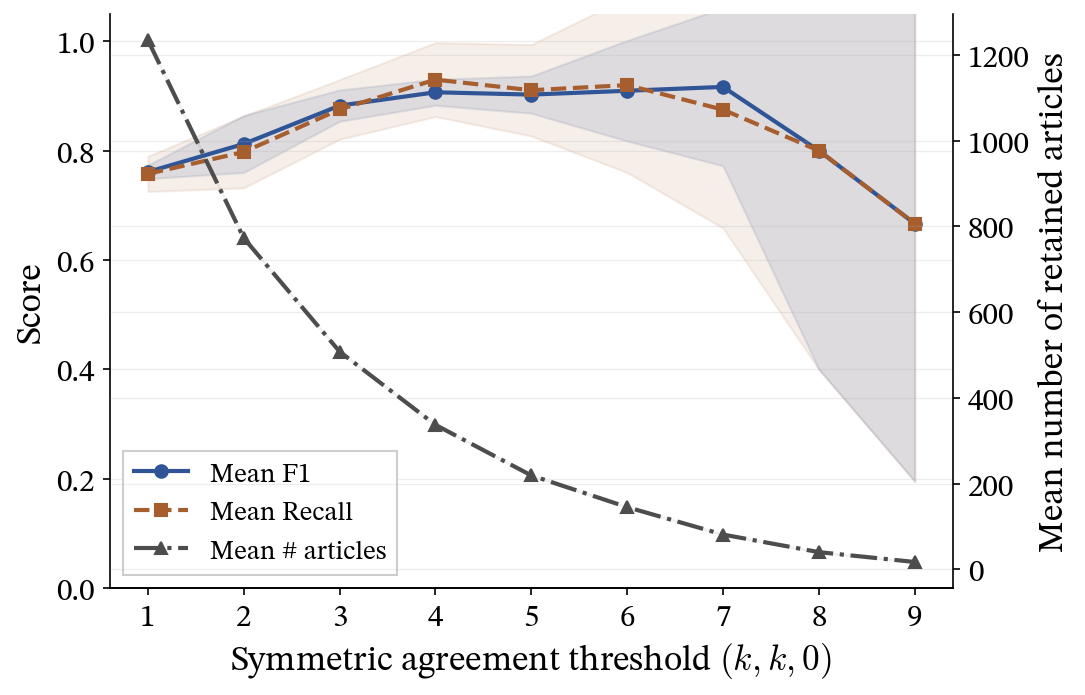

[INFO] HydroNewsFr | XGBoost | TA | all_features -> best raw F1 at k=7 (F1=0.917, Recall=0.875, Articles=81.0)

=== ClimateNewsFr ===
File: ./ALL_results_corr_plus_ML_climat_COMPLETE_EMNLP_REDUCED.xlsx


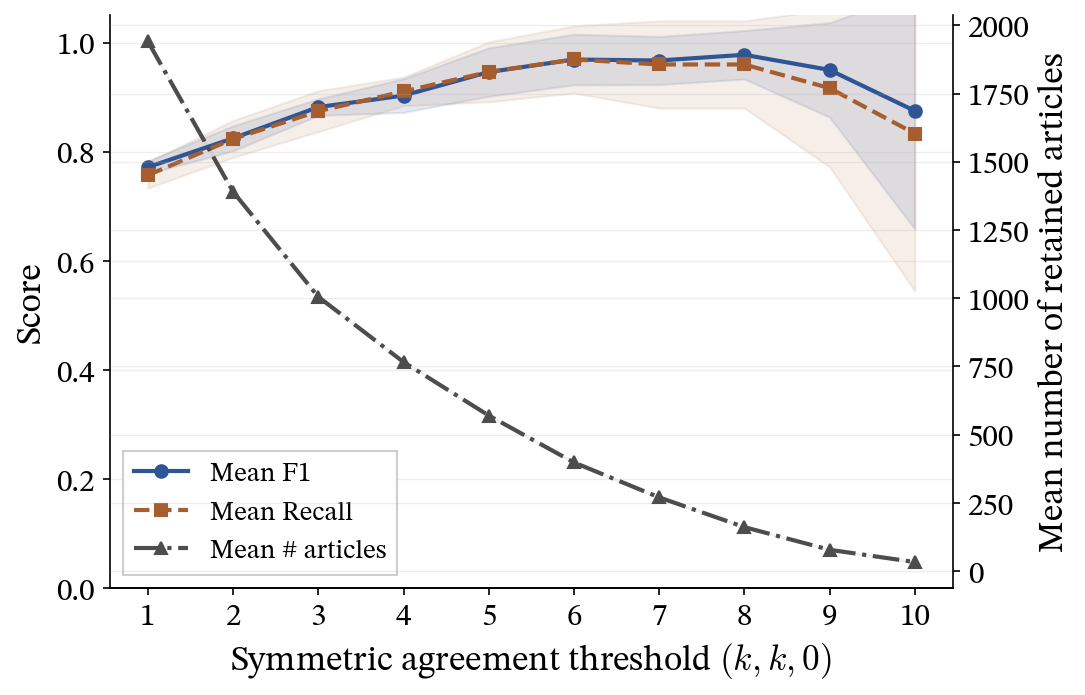

[INFO] ClimateNewsFr | XGBoost | TA | all_features -> best raw F1 at k=8 (F1=0.978, Recall=0.960, Articles=161.0)

Done. Plots saved in: /Users/evangeliazve/Downloads/plots_best_settings


In [76]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================================
# CONFIG
# ==========================================================
HYDRO_XLSX = "./ALL_results_corr_plus_ML_COMPLETE_EMNLP_REDUCED_hydro.xlsx"
CLIMATE_XLSX = "./ALL_results_corr_plus_ML_climat_COMPLETE_EMNLP_REDUCED.xlsx"

OUT_DIR = "./plots_best_settings"
os.makedirs(OUT_DIR, exist_ok=True)

BEST_SETTINGS = {
    "HydroNewsFr": {"file": HYDRO_XLSX},
    "ClimateNewsFr": {"file": CLIMATE_XLSX},
}

LEARNED_CLFS = {"rf", "xgb", "logreg", "linear_svc", "dt"}

# Main methodological choice:
REFERENCE_CLF = "xgb"   # or "xgb"
REFERENCE_HORIZON = "TA"   # publication time, as in the paper
REFERENCE_ABLATION = "all_features"


# ==========================================================
# EMNLP / PRINT-FRIENDLY STYLE
# ==========================================================
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": 17,
    "axes.titlesize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 13,
    "axes.linewidth": 0.8,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.22,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.fancybox": False,
})

FIGSIZE = (7.4, 4.8)

# Muted, color-blind-friendly, print-safe
C_F1 = "#2F5597"       # muted blue
C_RECALL = "#A65E2E"   # muted brown-orange
C_ART = "#4D4D4D"      # dark gray

LS_F1 = "-"
LS_RECALL = "--"
LS_ART = "-."

MK_F1 = "o"
MK_RECALL = "s"
MK_ART = "^"


def finalize_and_output(fig, axes, save_path: str, show: bool = True):
    if not isinstance(axes, (list, tuple, np.ndarray)):
        axes = [axes]

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.grid(True, axis="y", alpha=0.22)

    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)


# ==========================================================
# HELPERS
# ==========================================================
def load_metrics(
    xlsx_path: str,
    scenario: str = "default",
    ablation: str = REFERENCE_ABLATION
) -> pd.DataFrame:
    """
    Loads the article-level ML metrics sheet and keeps only:
    - the requested scenario
    - the requested ablation
    - learned classifiers
    """
    df = pd.read_excel(xlsx_path, sheet_name="ml_metrics_article_geomagg")

    df = df[
        (df["scenario"] == scenario) &
        (df["ablation"] == ablation) &
        (df["clf_name"].isin(LEARNED_CLFS))
    ].copy()

    if df.empty:
        raise ValueError(
            f"No rows found after filtering with "
            f"scenario='{scenario}', ablation='{ablation}'."
        )

    remaining_ablations = sorted(df["ablation"].astype(str).unique().tolist())
    if remaining_ablations != [ablation]:
        raise ValueError(
            f"Unexpected ablations after filtering: {remaining_ablations}"
        )

    return df


def save_dataframe(df: pd.DataFrame, filename: str):
    df.to_csv(os.path.join(OUT_DIR, filename), index=False)


def filter_reference_setting(
    df_metrics: pd.DataFrame,
    clf_name: str = "xgb",
    horizon_value: str = "TA",
    horizon_col: str = "horizon"
) -> pd.DataFrame:
    """
    Filters to one reference classifier and one reference horizon.

    Adjust horizon_col if your file uses another column name,
    e.g. 'time_horizon' or 'pred_horizon'.
    """
    d = df_metrics.copy()

    # fixed classifier
    d = d[d["clf_name"] == clf_name].copy()

    # fixed horizon, if present
    if horizon_col in d.columns:
        d = d[d[horizon_col].astype(str) == str(horizon_value)].copy()
    else:
        print(f"[WARN] Column '{horizon_col}' not found. "
              f"No horizon filtering applied.")

    return d


def symmetric_cutoff_summary_reference(
    df_metrics: pd.DataFrame
) -> pd.DataFrame:
    """
    Summary for symmetric thresholds (k, k, 0),
    with ONE classifier and ONE horizon already fixed.

    Assumes the sheet contains per-cutoff rows with:
    - F1_mean
    - F1_std
    - Recall_mean
    - Recall_std
    - n_articles
    """
    d = df_metrics[
        (df_metrics["toa_max_neg"] == 0) &
        (df_metrics["outlier_maj"] == df_metrics["toa_min_pos"])
    ].copy()

    if d.empty:
        return d

    d["k"] = d["toa_min_pos"].astype(int)

    out = (
        d.groupby("k", as_index=False)
         .agg(
             f1_mean=("F1_mean", "mean"),
             f1_std=("F1_std", "mean"),
             recall_mean=("Recall_mean", "mean"),
             recall_std=("Recall_std", "mean"),
             n_articles_mean=("n_articles", "mean"),
             n_articles_std=("n_articles", "std"),
             n_pos_mean=("n_pos_articles_est", "mean"),
             n_rows=("k", "count"),
         )
         .sort_values("k")
    )

    out["n_articles_std"] = out["n_articles_std"].fillna(0)
    return out


# ==========================================================
# MAIN PLOT:
# symmetric cutoff (k, k, 0) for ONE classifier at ONE horizon
# ==========================================================
def plot_symmetric_cutoff_reference_dual_axis(
    dataset_name: str,
    xlsx_path: str,
    clf_name: str = "xgb",
    horizon_value: str = "TA",
    horizon_col: str = "horizon",
    show: bool = True
):
    df = load_metrics(
        xlsx_path=xlsx_path,
        scenario="default",
        ablation=REFERENCE_ABLATION,
    )

    df_ref = filter_reference_setting(
        df_metrics=df,
        clf_name=clf_name,
        horizon_value=horizon_value,
        horizon_col=horizon_col
    )

    summ = symmetric_cutoff_summary_reference(df_ref)

    if summ.empty:
        print(f"[WARN] No data for {dataset_name} | clf={clf_name} | horizon={horizon_value}")
        return

    x = summ["k"].to_numpy(dtype=int)

    y_f1 = summ["f1_mean"].to_numpy(dtype=float)
    s_f1 = summ["f1_std"].fillna(0).to_numpy(dtype=float)

    y_rec = summ["recall_mean"].to_numpy(dtype=float)
    s_rec = summ["recall_std"].fillna(0).to_numpy(dtype=float)

    y_art = summ["n_articles_mean"].to_numpy(dtype=float)
    s_art = summ["n_articles_std"].fillna(0).to_numpy(dtype=float)

    fig, ax1 = plt.subplots(figsize=FIGSIZE)
    ax2 = ax1.twinx()

    # Left axis: F1
    l1, = ax1.plot(
        x, y_f1,
        color=C_F1,
        linestyle=LS_F1,
        marker=MK_F1,
        label="Mean F1"
    )
    ax1.fill_between(
        x, y_f1 - s_f1, y_f1 + s_f1,
        color=C_F1, alpha=0.12
    )

    # Left axis: Recall
    l2, = ax1.plot(
        x, y_rec,
        color=C_RECALL,
        linestyle=LS_RECALL,
        marker=MK_RECALL,
        label="Mean Recall"
    )
    ax1.fill_between(
        x, y_rec - s_rec, y_rec + s_rec,
        color=C_RECALL, alpha=0.10
    )

    # Right axis: mean number of retained articles
    l3, = ax2.plot(
        x, y_art,
        color=C_ART,
        linestyle=LS_ART,
        marker=MK_ART,
        label="Mean # articles"
    )
    ax2.fill_between(
        x, y_art - s_art, y_art + s_art,
        color=C_ART, alpha=0.08
    )

    # Axis formatting
    ax1.set_xlabel(r"Symmetric agreement threshold $(k, k, 0)$")
    ax1.set_ylabel("Score")
    ax2.set_ylabel("Mean number of retained articles")

    ax1.set_xticks(x)
    ax1.set_ylim(0, 1.05)
    ax1.set_yticks(np.linspace(0, 1.0, 6))

    # Use paper notation T_A in the title
    if str(horizon_value) == "TA":
        horizon_label = r"$T_A$"
    else:
        horizon_label = str(horizon_value)

    pretty_clf = {
        "xgb": "XGBoost",
        "rf": "Random Forest",
        "logreg": "LogReg",
        "linear_svc": "Linear SVC",
        "dt": "Decision Tree",
    }.get(clf_name, clf_name)

    # ax1.set_title(f"{dataset_name} — {pretty_clf} at {horizon_label} ({REFERENCE_ABLATION})")

    handles = [l1, l2, l3]
    labels = [h.get_label() for h in handles]
    ax1.legend(handles, labels, loc="best", ncol=1)

    # Cleaner spines
    ax1.spines["right"].set_visible(False)
    ax2.spines["left"].set_visible(False)
    ax2.spines["top"].set_visible(False)

    out_png = os.path.join(
        OUT_DIR,
        f"{dataset_name}_symmetric_cutoff_{clf_name}_{horizon_value}_{REFERENCE_ABLATION}_dual_axis.png"
    )
    finalize_and_output(fig, [ax1, ax2], out_png, show=show)

    out_csv = os.path.join(
        OUT_DIR,
        f"{dataset_name}_symmetric_cutoff_{clf_name}_{horizon_value}_{REFERENCE_ABLATION}_summary.csv"
    )
    summ.to_csv(out_csv, index=False)

    # Optional: print a simple recommended k based on max F1
    best_row = summ.loc[summ["f1_mean"].idxmax()]
    print(
        f"[INFO] {dataset_name} | {pretty_clf} | {horizon_value} | {REFERENCE_ABLATION} "
        f"-> best raw F1 at k={int(best_row['k'])} "
        f"(F1={best_row['f1_mean']:.3f}, "
        f"Recall={best_row['recall_mean']:.3f}, "
        f"Articles={best_row['n_articles_mean']:.1f})"
    )


# ==========================================================
# MAIN
# ==========================================================
def main(show_plots: bool = True):
    print(f"[INFO] Using ablation='{REFERENCE_ABLATION}' only")

    for dataset_name, cfg in BEST_SETTINGS.items():
        xlsx_path = cfg["file"]

        print(f"\n=== {dataset_name} ===")
        print(f"File: {xlsx_path}")

        plot_symmetric_cutoff_reference_dual_axis(
            dataset_name=dataset_name,
            xlsx_path=xlsx_path,
            clf_name=REFERENCE_CLF,
            horizon_value=REFERENCE_HORIZON,
            horizon_col="horizon",
            show=show_plots,
        )

    print(f"\nDone. Plots saved in: {os.path.abspath(OUT_DIR)}")


if __name__ == "__main__":
    main(show_plots=True)

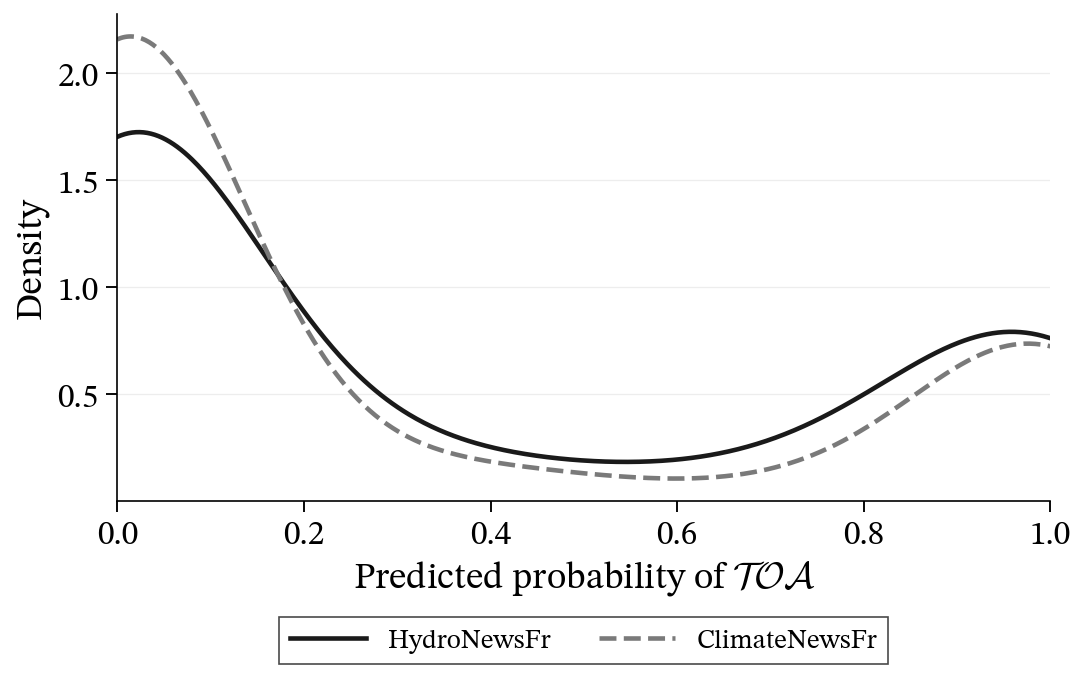

[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets.png
[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets.pdf
[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets_data.csv


In [85]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from matplotlib.font_manager import FontProperties


# ==========================================================
# CONFIG
# ==========================================================
HYDRO_UNCERTAIN_XLSX = "./XGB_SHAP_fixed440_hydrogenewsfr.xlsx"
CLIMATE_UNCERTAIN_XLSX = "./XGB_SHAP_fixed660_climatenewsfr.xlsx"

OUT_DIR = "./plots_best_settings"
os.makedirs(OUT_DIR, exist_ok=True)

FIGSIZE = (7.4, 4.8)

# color-blind-safe + printable: grayscale with different linestyles
C_HYDRO = "#1A1A1A"
C_CLIMATE = "#7A7A7A"

LS_HYDRO = "-"
LS_CLIMATE = "--"

LW_MAIN = 2.2
ALPHA_GRID = 0.22

XMIN, XMAX = 0.0, 1.0
N_GRID = 500
MIN_POINTS_FOR_KDE = 3

# Bigger labels and ticks
AXES_LABELSIZE = 18
TICK_LABELSIZE = 16
LEGEND_SIZE = 13
TITLE_SIZE = 16

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": AXES_LABELSIZE,
    "axes.titlesize": TITLE_SIZE,
    "xtick.labelsize": TICK_LABELSIZE,
    "ytick.labelsize": TICK_LABELSIZE,
    "legend.fontsize": LEGEND_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 2.0,
    "grid.linewidth": 0.6,
    "grid.alpha": ALPHA_GRID,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.fancybox": False,
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": [
        "Latin Modern Roman",
        "CMU Serif",
        "Computer Modern Roman",
        "STIX Two Text",
        "STIXGeneral",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "cm",
})


# ==========================================================
# HELPERS
# ==========================================================
def finalize_and_output(fig, ax, save_base: str, show: bool = True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=ALPHA_GRID)

    fig.tight_layout()
    fig.savefig(save_base + ".png", bbox_inches="tight")
    fig.savefig(save_base + ".pdf", bbox_inches="tight")

    if show:
        plt.show()
    plt.close(fig)


def is_ta_horizon(v) -> bool:
    if pd.isna(v):
        return False
    if isinstance(v, (int, np.integer, float, np.floating)):
        return int(v) == 0
    s = str(v).strip().upper()
    return s == "TA" or s == "0"


def load_uncertain_ta_probs(xlsx_path: str) -> pd.DataFrame:
    df = pd.read_excel(xlsx_path, sheet_name="uncertain_scoring_raw")

    required = {"dataset", "horizon", "media_url", "pred_proba"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Missing required columns in {xlsx_path}: {sorted(missing)}")

    df = df.copy()
    df = df[df["horizon"].apply(is_ta_horizon)].copy()
    df["pred_proba"] = pd.to_numeric(df["pred_proba"], errors="coerce")
    df = df.dropna(subset=["pred_proba"]).copy()
    df = df[(df["pred_proba"] >= 0.0) & (df["pred_proba"] <= 1.0)].copy()
    return df


def compute_kde_curve(x: np.ndarray, xmin: float = 0.0, xmax: float = 1.0, n_grid: int = 500):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    if len(x) < MIN_POINTS_FOR_KDE:
        return None, None

    if np.allclose(x, x[0]):
        grid = np.linspace(xmin, xmax, n_grid)
        y = np.zeros_like(grid)
        y[np.argmin(np.abs(grid - x[0]))] = 1.0
        return grid, y

    kde = gaussian_kde(x)
    grid = np.linspace(xmin, xmax, n_grid)
    y = kde(grid)
    return grid, y


def add_textsc_like_legend_bottom(ax, handles):
    labels = ["HydroNewsFr", "ClimateNewsFr"]

    leg = ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.24),
        ncol=2,
        borderaxespad=0.0,
        handlelength=2.8,
        columnspacing=1.8,
        handletextpad=0.8,
    )

    # Safe approach: request small-caps, but keep normal text if font lacks it.
    fp = FontProperties(
        family="serif",
        variant="small-caps",
        size=LEGEND_SIZE,
    )
    for txt in leg.get_texts():
        txt.set_fontproperties(fp)

    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_edgecolor("0.25")
    return leg


# ==========================================================
# SINGLE FIGURE: TA ONLY, BOTH DATASETS
# ==========================================================
def plot_uncertain_distribution_ta_both_datasets(
    hydro_xlsx: str,
    climate_xlsx: str,
    out_dir: str,
    show: bool = True
):
    df_h = load_uncertain_ta_probs(hydro_xlsx)
    df_c = load_uncertain_ta_probs(climate_xlsx)

    if df_h.empty:
        print("[WARN] No uncertain TA rows found for HydroNewsFr.")
        return
    if df_c.empty:
        print("[WARN] No uncertain TA rows found for ClimateNewsFr.")
        return

    x_h = df_h["pred_proba"].to_numpy(dtype=float)
    x_c = df_c["pred_proba"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    gh, yh = compute_kde_curve(x_h, xmin=XMIN, xmax=XMAX, n_grid=N_GRID)
    gc, yc = compute_kde_curve(x_c, xmin=XMIN, xmax=XMAX, n_grid=N_GRID)

    handles = []

    if gh is not None and yh is not None:
        h1, = ax.plot(
            gh, yh,
            color=C_HYDRO,
            linestyle=LS_HYDRO,
            linewidth=LW_MAIN,
        )
        handles.append(h1)
    else:
        _, _, patches1 = ax.hist(
            x_h,
            bins=20,
            range=(XMIN, XMAX),
            density=True,
            histtype="step",
            color=C_HYDRO,
            linestyle=LS_HYDRO,
            linewidth=LW_MAIN,
        )
        handles.append(patches1[0])

    if gc is not None and yc is not None:
        h2, = ax.plot(
            gc, yc,
            color=C_CLIMATE,
            linestyle=LS_CLIMATE,
            linewidth=LW_MAIN,
        )
        handles.append(h2)
    else:
        _, _, patches2 = ax.hist(
            x_c,
            bins=20,
            range=(XMIN, XMAX),
            density=True,
            histtype="step",
            color=C_CLIMATE,
            linestyle=LS_CLIMATE,
            linewidth=LW_MAIN,
        )
        handles.append(patches2[0])

    ax.set_xlabel(r"Predicted probability of $\mathcal{TOA}$", fontsize=AXES_LABELSIZE)
    ax.set_ylabel("Density", fontsize=AXES_LABELSIZE)
    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks(np.linspace(0, 1, 6))

    ax.tick_params(axis="x", which="both", direction="out", length=5.5, width=0.9, labelsize=TICK_LABELSIZE)
    ax.tick_params(axis="y", which="both", direction="out", length=5.5, width=0.9, labelsize=TICK_LABELSIZE)

    #ax.set_title(r"Uncertain documents at $\mathcal{TOA}$", fontsize=TITLE_SIZE)

    add_textsc_like_legend_bottom(ax, handles)

    save_base = os.path.join(out_dir, "uncertain_TA_distribution_both_datasets")
    finalize_and_output(fig, ax, save_base=save_base, show=show)

    pd.concat([df_h, df_c], ignore_index=True).to_csv(
        os.path.join(out_dir, "uncertain_TA_distribution_both_datasets_data.csv"),
        index=False
    )

    print(f"[OK] Saved: {save_base}.png")
    print(f"[OK] Saved: {save_base}.pdf")
    print(f"[OK] Saved: {os.path.join(out_dir, 'uncertain_TA_distribution_both_datasets_data.csv')}")


# ==========================================================
# OPTIONAL: CHECK WHICH SERIF FONTS ARE AVAILABLE
# ==========================================================
def print_available_target_fonts():
    import matplotlib.font_manager as fm

    targets = [
        "Latin Modern Roman",
        "CMU Serif",
        "Computer Modern Roman",
        "STIX Two Text",
        "STIXGeneral",
        "DejaVu Serif",
    ]
    print("Font lookup:")
    for f in targets:
        try:
            path = fm.findfont(f, fallback_to_default=False)
            print(f"  {f} -> {path}")
        except Exception:
            print(f"  {f} -> NOT FOUND")


# ==========================================================
# MAIN
# ==========================================================
def main(show_plots: bool = True, check_fonts: bool = False):
    if check_fonts:
        print_available_target_fonts()

    plot_uncertain_distribution_ta_both_datasets(
        hydro_xlsx=HYDRO_UNCERTAIN_XLSX,
        climate_xlsx=CLIMATE_UNCERTAIN_XLSX,
        out_dir=OUT_DIR,
        show=show_plots,
    )


if __name__ == "__main__":
    main(show_plots=True, check_fonts=False)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


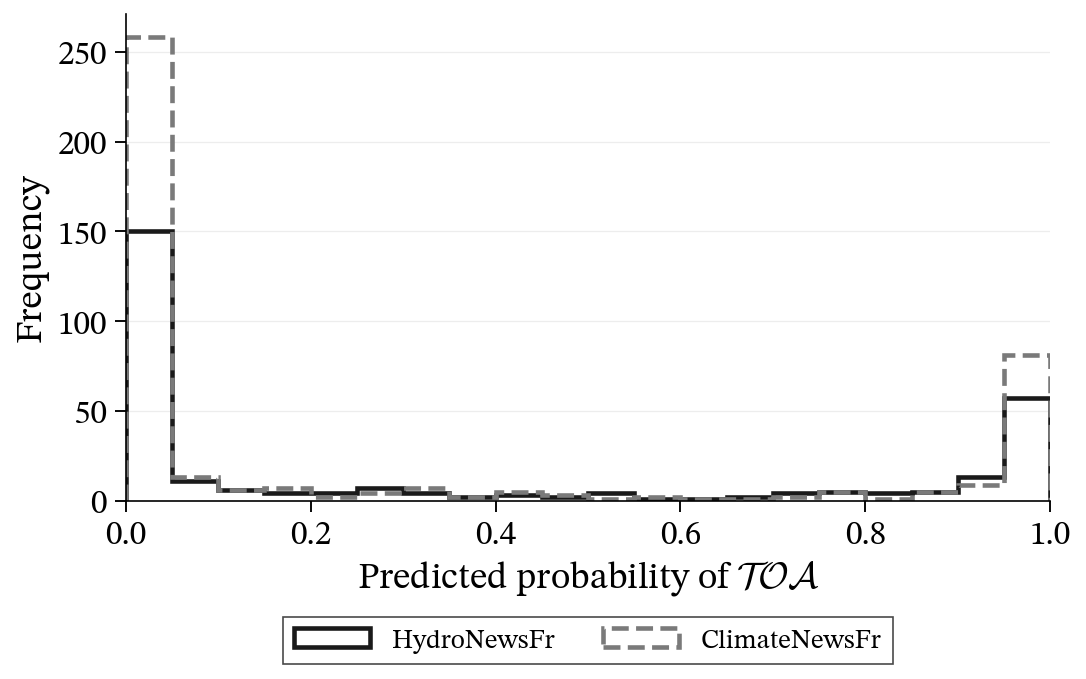

[OK] HydroNewsFr TA rows: 289
[OK] ClimateNewsFr TA rows: 415
[OK] Saved: ./plots_best_settings/uncertain_TA_frequency_both_datasets.png
[OK] Saved: ./plots_best_settings/uncertain_TA_frequency_both_datasets.pdf
[OK] Saved: ./plots_best_settings/uncertain_TA_frequency_both_datasets_data.csv
[OK] Saved: ./plots_best_settings/uncertain_TA_frequency_both_datasets_bin_counts.csv


In [208]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.font_manager import FontProperties


# ==========================================================
# CONFIG
# ==========================================================
HYDRO_UNCERTAIN_XLSX = "./XGB_SHAP_fixed440_hydrogenewsfr.xlsx"
CLIMATE_UNCERTAIN_XLSX = "./XGB_SHAP_fixed660_climatenewsfr.xlsx"

OUT_DIR = "./plots_best_settings"
os.makedirs(OUT_DIR, exist_ok=True)

FIGSIZE = (7.4, 4.8)

# color-blind-safe + printable: grayscale with different linestyles
C_HYDRO = "#1A1A1A"
C_CLIMATE = "#7A7A7A"

LS_HYDRO = "-"
LS_CLIMATE = "--"

LW_MAIN = 2.2
ALPHA_GRID = 0.22

XMIN, XMAX = 0.0, 1.0
N_BINS = 20

# Bigger labels and ticks
AXES_LABELSIZE = 18
TICK_LABELSIZE = 16
LEGEND_SIZE = 13
TITLE_SIZE = 16

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": AXES_LABELSIZE,
    "axes.titlesize": TITLE_SIZE,
    "xtick.labelsize": TICK_LABELSIZE,
    "ytick.labelsize": TICK_LABELSIZE,
    "legend.fontsize": LEGEND_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 2.0,
    "grid.linewidth": 0.6,
    "grid.alpha": ALPHA_GRID,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.fancybox": False,
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": [
        "Latin Modern Roman",
        "CMU Serif",
        "Computer Modern Roman",
        "STIX Two Text",
        "STIXGeneral",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "cm",
})


# ==========================================================
# HELPERS
# ==========================================================
def finalize_and_output(fig, ax, save_base: str, show: bool = True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=ALPHA_GRID)

    fig.tight_layout()
    fig.savefig(save_base + ".png", bbox_inches="tight")
    fig.savefig(save_base + ".pdf", bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)


def is_ta_horizon(v) -> bool:
    if pd.isna(v):
        return False

    if isinstance(v, (int, np.integer, float, np.floating)):
        return int(v) == 0

    s = str(v).strip().upper()
    return s == "TA" or s == "0"


def load_uncertain_ta_probs(xlsx_path: str) -> pd.DataFrame:
    if not os.path.exists(xlsx_path):
        raise FileNotFoundError(f"File not found: {xlsx_path}")

    df = pd.read_excel(xlsx_path, sheet_name="uncertain_scoring_raw")

    required = {"dataset", "horizon", "media_url", "pred_proba"}
    missing = required.difference(df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns in {xlsx_path}: {sorted(missing)}"
        )

    df = df.copy()

    df = df[df["horizon"].apply(is_ta_horizon)].copy()

    df["pred_proba"] = pd.to_numeric(df["pred_proba"], errors="coerce")
    df = df.dropna(subset=["pred_proba"]).copy()

    df = df[
        (df["pred_proba"] >= XMIN) &
        (df["pred_proba"] <= XMAX)
    ].copy()

    return df


def add_textsc_like_legend_bottom(ax, handles):
    labels = ["HydroNewsFr", "ClimateNewsFr"]

    leg = ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.24),
        ncol=2,
        borderaxespad=0.0,
        handlelength=2.8,
        columnspacing=1.8,
        handletextpad=0.8,
    )

    # Safe approach: request small-caps, but keep normal text if font lacks it.
    fp = FontProperties(
        family="serif",
        variant="small-caps",
        size=LEGEND_SIZE,
    )

    for txt in leg.get_texts():
        txt.set_fontproperties(fp)

    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_edgecolor("0.25")

    return leg


# ==========================================================
# SINGLE FIGURE: TA ONLY, BOTH DATASETS — FREQUENCIES
# ==========================================================
def plot_uncertain_frequency_ta_both_datasets(
    hydro_xlsx: str,
    climate_xlsx: str,
    out_dir: str,
    show: bool = True
):
    df_h = load_uncertain_ta_probs(hydro_xlsx)
    df_c = load_uncertain_ta_probs(climate_xlsx)

    if df_h.empty:
        print("[WARN] No uncertain TA rows found for HydroNewsFr.")
        return

    if df_c.empty:
        print("[WARN] No uncertain TA rows found for ClimateNewsFr.")
        return

    x_h = df_h["pred_proba"].to_numpy(dtype=float)
    x_c = df_c["pred_proba"].to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    bins = np.linspace(XMIN, XMAX, N_BINS + 1)

    counts_h, edges_h, patches_h = ax.hist(
        x_h,
        bins=bins,
        density=False,
        histtype="step",
        color=C_HYDRO,
        linestyle=LS_HYDRO,
        linewidth=LW_MAIN,
    )

    counts_c, edges_c, patches_c = ax.hist(
        x_c,
        bins=bins,
        density=False,
        histtype="step",
        color=C_CLIMATE,
        linestyle=LS_CLIMATE,
        linewidth=LW_MAIN,
    )

    handles = [patches_h[0], patches_c[0]]

    ax.set_xlabel(
        r"Predicted probability of $\mathcal{TOA}$",
        fontsize=AXES_LABELSIZE,
    )
    ax.set_ylabel("Frequency", fontsize=AXES_LABELSIZE)

    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks(np.linspace(0, 1, 6))

    ax.tick_params(
        axis="x",
        which="both",
        direction="out",
        length=5.5,
        width=0.9,
        labelsize=TICK_LABELSIZE,
    )

    ax.tick_params(
        axis="y",
        which="both",
        direction="out",
        length=5.5,
        width=0.9,
        labelsize=TICK_LABELSIZE,
    )

    add_textsc_like_legend_bottom(ax, handles)

    save_base = os.path.join(
        out_dir,
        "uncertain_TA_frequency_both_datasets"
    )

    finalize_and_output(fig, ax, save_base=save_base, show=show)

    combined_df = pd.concat([df_h, df_c], ignore_index=True)

    data_path = os.path.join(
        out_dir,
        "uncertain_TA_frequency_both_datasets_data.csv"
    )

    combined_df.to_csv(data_path, index=False)

    # Optional: save bin counts too
    counts_df = pd.DataFrame({
        "bin_left": bins[:-1],
        "bin_right": bins[1:],
        "HydroNewsFr_frequency": counts_h.astype(int),
        "ClimateNewsFr_frequency": counts_c.astype(int),
    })

    counts_path = os.path.join(
        out_dir,
        "uncertain_TA_frequency_both_datasets_bin_counts.csv"
    )

    counts_df.to_csv(counts_path, index=False)

    print(f"[OK] HydroNewsFr TA rows: {len(df_h)}")
    print(f"[OK] ClimateNewsFr TA rows: {len(df_c)}")
    print(f"[OK] Saved: {save_base}.png")
    print(f"[OK] Saved: {save_base}.pdf")
    print(f"[OK] Saved: {data_path}")
    print(f"[OK] Saved: {counts_path}")


# ==========================================================
# OPTIONAL: CHECK WHICH SERIF FONTS ARE AVAILABLE
# ==========================================================
def print_available_target_fonts():
    import matplotlib.font_manager as fm

    targets = [
        "Latin Modern Roman",
        "CMU Serif",
        "Computer Modern Roman",
        "STIX Two Text",
        "STIXGeneral",
        "DejaVu Serif",
    ]

    print("Font lookup:")

    for f in targets:
        try:
            path = fm.findfont(f, fallback_to_default=False)
            print(f"  {f} -> {path}")
        except Exception:
            print(f"  {f} -> NOT FOUND")


# ==========================================================
# MAIN
# ==========================================================
def main(show_plots: bool = True, check_fonts: bool = False):
    if check_fonts:
        print_available_target_fonts()

    plot_uncertain_frequency_ta_both_datasets(
        hydro_xlsx=HYDRO_UNCERTAIN_XLSX,
        climate_xlsx=CLIMATE_UNCERTAIN_XLSX,
        out_dir=OUT_DIR,
        show=show_plots,
    )


if __name__ == "__main__":
    main(show_plots=True, check_fonts=False)

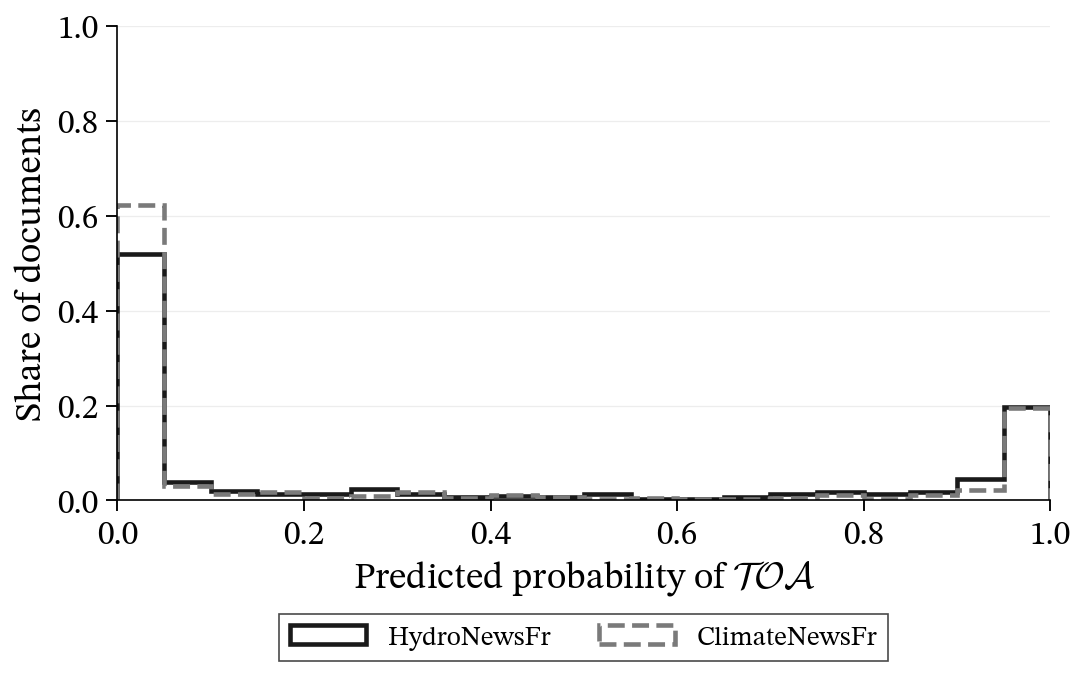

[OK] HydroNewsFr TA uncertain rows: 289
[OK] ClimateNewsFr TA uncertain rows: 415
[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets_share_hist.png
[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets_share_hist.pdf
[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets_data.csv
[OK] Saved: ./plots_best_settings/uncertain_TA_distribution_both_datasets_binned_summary.csv


In [114]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.font_manager import FontProperties


# ==========================================================
# CONFIG
# ==========================================================
HYDRO_UNCERTAIN_XLSX = "./XGB_SHAP_fixed440_hydrogenewsfr.xlsx"
CLIMATE_UNCERTAIN_XLSX = "./XGB_SHAP_fixed660_climatenewsfr.xlsx"

OUT_DIR = "./plots_best_settings"
os.makedirs(OUT_DIR, exist_ok=True)

FIGSIZE = (7.4, 4.8)

# Color-blind-safe + printable: grayscale with different linestyles
C_HYDRO = "#1A1A1A"
C_CLIMATE = "#7A7A7A"

LS_HYDRO = "-"
LS_CLIMATE = "--"

LW_MAIN = 2.2
ALPHA_GRID = 0.22

XMIN, XMAX = 0.0, 1.0
N_BINS = 20

# Bigger labels and ticks
AXES_LABELSIZE = 18
TICK_LABELSIZE = 16
LEGEND_SIZE = 13
TITLE_SIZE = 16

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 12,
    "axes.labelsize": AXES_LABELSIZE,
    "axes.titlesize": TITLE_SIZE,
    "xtick.labelsize": TICK_LABELSIZE,
    "ytick.labelsize": TICK_LABELSIZE,
    "legend.fontsize": LEGEND_SIZE,
    "axes.linewidth": 0.8,
    "lines.linewidth": 2.0,
    "grid.linewidth": 0.6,
    "grid.alpha": ALPHA_GRID,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.fancybox": False,
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": [
        "Latin Modern Roman",
        "CMU Serif",
        "Computer Modern Roman",
        "STIX Two Text",
        "STIXGeneral",
        "DejaVu Serif",
    ],
    "mathtext.fontset": "cm",
})


# ==========================================================
# HELPERS
# ==========================================================
def finalize_and_output(fig, ax, save_base: str, show: bool = True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, axis="y", alpha=ALPHA_GRID)

    fig.tight_layout()
    fig.savefig(save_base + ".png", bbox_inches="tight")
    fig.savefig(save_base + ".pdf", bbox_inches="tight")

    if show:
        plt.show()

    plt.close(fig)


def is_ta_horizon(v) -> bool:
    if pd.isna(v):
        return False

    if isinstance(v, (int, np.integer, float, np.floating)):
        return int(v) == 0

    s = str(v).strip().upper()
    return s == "TA" or s == "0"


def load_uncertain_ta_probs(xlsx_path: str) -> pd.DataFrame:
    df = pd.read_excel(xlsx_path, sheet_name="uncertain_scoring_raw")

    required = {"dataset", "horizon", "media_url", "pred_proba"}
    missing = required.difference(df.columns)

    if missing:
        raise ValueError(
            f"Missing required columns in {xlsx_path}: {sorted(missing)}"
        )

    df = df.copy()

    # Keep TA horizon only
    df = df[df["horizon"].apply(is_ta_horizon)].copy()

    # Clean predicted probabilities
    df["pred_proba"] = pd.to_numeric(df["pred_proba"], errors="coerce")
    df = df.dropna(subset=["pred_proba"]).copy()
    df = df[(df["pred_proba"] >= 0.0) & (df["pred_proba"] <= 1.0)].copy()

    return df


def add_textsc_like_legend_bottom(ax, handles):
    labels = ["HydroNewsFr", "ClimateNewsFr"]

    leg = ax.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.24),
        ncol=2,
        borderaxespad=0.0,
        handlelength=2.8,
        columnspacing=1.8,
        handletextpad=0.8,
    )

    fp = FontProperties(
        family="serif",
        variant="small-caps",
        size=LEGEND_SIZE,
    )

    for txt in leg.get_texts():
        txt.set_fontproperties(fp)

    leg.get_frame().set_linewidth(0.8)
    leg.get_frame().set_edgecolor("0.25")

    return leg


# ==========================================================
# SINGLE FIGURE: TA ONLY, BOTH DATASETS
# Y-axis = share of documents, from 0 to 1
# ==========================================================
def plot_uncertain_distribution_ta_both_datasets(
    hydro_xlsx: str,
    climate_xlsx: str,
    out_dir: str,
    show: bool = True
):
    df_h = load_uncertain_ta_probs(hydro_xlsx)
    df_c = load_uncertain_ta_probs(climate_xlsx)

    if df_h.empty:
        print("[WARN] No uncertain TA rows found for HydroNewsFr.")
        return

    if df_c.empty:
        print("[WARN] No uncertain TA rows found for ClimateNewsFr.")
        return

    x_h = df_h["pred_proba"].to_numpy(dtype=float)
    x_c = df_c["pred_proba"].to_numpy(dtype=float)

    bins = np.linspace(XMIN, XMAX, N_BINS + 1)

    fig, ax = plt.subplots(figsize=FIGSIZE)

    # Each bar height is the fraction of documents in that bin.
    # Example: 0.25 means 25% of documents are in that probability interval.
    weights_h = np.ones_like(x_h, dtype=float) / len(x_h)
    weights_c = np.ones_like(x_c, dtype=float) / len(x_c)

    _, _, patches_h = ax.hist(
        x_h,
        bins=bins,
        weights=weights_h,
        histtype="step",
        color=C_HYDRO,
        linestyle=LS_HYDRO,
        linewidth=LW_MAIN,
    )

    _, _, patches_c = ax.hist(
        x_c,
        bins=bins,
        weights=weights_c,
        histtype="step",
        color=C_CLIMATE,
        linestyle=LS_CLIMATE,
        linewidth=LW_MAIN,
    )

    handles = [patches_h[0], patches_c[0]]

    ax.set_xlabel(
        r"Predicted probability of $\mathcal{TOA}$",
        fontsize=AXES_LABELSIZE
    )

    ax.set_ylabel(
        "Share of documents",
        fontsize=AXES_LABELSIZE
    )

    ax.set_xlim(XMIN, XMAX)
    ax.set_ylim(0, 1)

    ax.set_xticks(np.linspace(0, 1, 6))
    ax.set_yticks(np.linspace(0, 1, 6))

    ax.tick_params(
        axis="x",
        which="both",
        direction="out",
        length=5.5,
        width=0.9,
        labelsize=TICK_LABELSIZE
    )

    ax.tick_params(
        axis="y",
        which="both",
        direction="out",
        length=5.5,
        width=0.9,
        labelsize=TICK_LABELSIZE
    )

    add_textsc_like_legend_bottom(ax, handles)

    save_base = os.path.join(
        out_dir,
        "uncertain_TA_distribution_both_datasets_share_hist"
    )

    finalize_and_output(fig, ax, save_base=save_base, show=show)

    # Save the underlying rows
    data_path = os.path.join(
        out_dir,
        "uncertain_TA_distribution_both_datasets_data.csv"
    )

    pd.concat([df_h, df_c], ignore_index=True).to_csv(
        data_path,
        index=False
    )

    # Save binned summary
    counts_h, _ = np.histogram(x_h, bins=bins)
    counts_c, _ = np.histogram(x_c, bins=bins)

    summary = pd.DataFrame({
        "bin_left": bins[:-1],
        "bin_right": bins[1:],
        "HydroNewsFr_count": counts_h,
        "HydroNewsFr_share": counts_h / len(x_h),
        "ClimateNewsFr_count": counts_c,
        "ClimateNewsFr_share": counts_c / len(x_c),
    })

    summary_path = os.path.join(
        out_dir,
        "uncertain_TA_distribution_both_datasets_binned_summary.csv"
    )

    summary.to_csv(summary_path, index=False)

    print(f"[OK] HydroNewsFr TA uncertain rows: {len(x_h)}")
    print(f"[OK] ClimateNewsFr TA uncertain rows: {len(x_c)}")
    print(f"[OK] Saved: {save_base}.png")
    print(f"[OK] Saved: {save_base}.pdf")
    print(f"[OK] Saved: {data_path}")
    print(f"[OK] Saved: {summary_path}")


# ==========================================================
# OPTIONAL: CHECK WHICH SERIF FONTS ARE AVAILABLE
# ==========================================================
def print_available_target_fonts():
    import matplotlib.font_manager as fm

    targets = [
        "Latin Modern Roman",
        "CMU Serif",
        "Computer Modern Roman",
        "STIX Two Text",
        "STIXGeneral",
        "DejaVu Serif",
    ]

    print("Font lookup:")

    for f in targets:
        try:
            path = fm.findfont(f, fallback_to_default=False)
            print(f"  {f} -> {path}")
        except Exception:
            print(f"  {f} -> NOT FOUND")


# ==========================================================
# MAIN
# ==========================================================
def main(show_plots: bool = True, check_fonts: bool = False):
    if check_fonts:
        print_available_target_fonts()

    plot_uncertain_distribution_ta_both_datasets(
        hydro_xlsx=HYDRO_UNCERTAIN_XLSX,
        climate_xlsx=CLIMATE_UNCERTAIN_XLSX,
        out_dir=OUT_DIR,
        show=show_plots,
    )


if __name__ == "__main__":
    main(show_plots=True, check_fonts=False)